<div class="alert alert-block alert-success">
<b>NOTEBOOK 4 - Clustering
</div>

---
# 1 - IMPORTS

### 1.1 - SETUP PROJECT

Make sure to check `README.md` and `requirements.txt` before running any notebooks. 

In [1]:
# ======================================================
# Imports
# ======================================================

from __future__ import annotations

# ------------------------------------------------------
# Standard Library
# ------------------------------------------------------
import io
import re
import sys
import json
import time
import yaml
import textwrap
import importlib
from math import pi
from pathlib import Path, PurePath
from typing import Dict, List, Tuple, Iterable

# ------------------------------------------------------
# Core Data & Math
# ------------------------------------------------------
import joblib
import numpy as np
import pandas as pd
from numpy.linalg import lstsq

# ------------------------------------------------------
# Visualization
# ------------------------------------------------------
import mpl_toolkits.mplot3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.cm import get_cmap
from matplotlib.transforms import blended_transform_factory
from pandas.plotting import parallel_coordinates
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------
# Machine Learning & Clustering
# ------------------------------------------------------
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    v_measure_score,
    adjusted_rand_score,
    homogeneity_score,
    completeness_score,
    pairwise_distances,
    davies_bouldin_score,
    calinski_harabasz_score,
    normalized_mutual_info_score,
)
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# ------------------------------------------------------
# Dimensionality Reduction
# ------------------------------------------------------
import umap  # from umap-learn

### 1.2 - DEFINE PATHS

Here we are defining the main paths that are going to be used in the notebook as well as importing the utils module.

In [2]:
# ======================================================
# Paths
# ======================================================

PROJECT_PATH = Path.cwd().resolve().parent
DATA_PATH = PROJECT_PATH / "data"
SRC_PATH = PROJECT_PATH / "src"
UTILS_PATH = SRC_PATH / "utilities"
PROCESSED_PATH = DATA_PATH / "processed"
OUTPUT_PATH = PROJECT_PATH / "outputs"
LABELS_PATH = OUTPUT_PATH / "labels"
FIG_PATH = OUTPUT_PATH / "figures"

FIG_PATH.mkdir(parents=True, exist_ok=True)

# Add src to sys.path (for package-style imports)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# Add utilities folder to sys.path (for direct import utils)
if str(UTILS_PATH) not in sys.path:
    sys.path.append(str(UTILS_PATH))

# Import with reload
try:
    import utilities.utils as utils
except ModuleNotFoundError:
    import utils

reimport = importlib.reload(utils)

### 1.3 - LOAD DATASETS

Here we import all the **preprocessed datasets** that will be used throughout this notebook.  
Each dataset has already been **cleaned, reduced (via PCA)** and **scaled** for consistency.

Specifically:
- `pca90_full` and `pca90_noout` → scaled versions used for clustering.  
- `desc_full` and `desc_noout` → descriptive datasets used for cluster interpretation and labeling.  
- Additional versions (e.g., raw, 2D, 3D, or visual subsets) → used mainly for **visualizations and comparisons**.

All datasets are stored inside a single container named **`DATASETS`**, ensuring that every version remains accessible and consistent across the workflow.

In [3]:
# ======================================================
# Load Data
# ======================================================

# ---Clustering data---

# Original Dataset (scaled)
full_scaled_path = PROCESSED_PATH / "01_datasets_for_clustering_profiling/full" / "01_climate_dataset_scaled.xlsx"
full_scaled = pd.read_excel(full_scaled_path, sheet_name=None)["Sheet1"]

# Imputed Dataset (scaled, no outliers)
noout_scaled_path = PROCESSED_PATH / "01_datasets_for_clustering_profiling/no_outliers" / "01_climate_dataset_scaled_noOutliers.xlsx"
noout_scaled = pd.read_excel(noout_scaled_path, sheet_name=None)["Sheet1"]

# PCA 90% Var Scaled Original
PCA_90Var_scaled_original_path = PROCESSED_PATH / "01_datasets_for_clustering_profiling/full" / "01_climate_dataset_PCA_90Var.xlsx"
pca90_full = pd.read_excel(PCA_90Var_scaled_original_path, sheet_name=None)["Sheet1"]

# PCA 90% Var Scaled Imputed
PCA_90Var_scaled_imputed_path = PROCESSED_PATH / "01_datasets_for_clustering_profiling/no_outliers" / "01_climate_dataset_PCA_90Var_noOutliers.xlsx"
pca90_noout = pd.read_excel(PCA_90Var_scaled_imputed_path, sheet_name=None)["Sheet1"]

# PCA 2D Scaled Original
PCA_2D_scaled_original_path = PROCESSED_PATH / "02_datasets_for_visualization/full" / "02_climate_dataset_PCA_2D.xlsx"
pca2d_full = pd.read_excel(PCA_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# PCA 2D Scaled Imputed
PCA_2D_scaled_imputed_path = PROCESSED_PATH / "02_datasets_for_visualization/no_outliers" / "02_climate_dataset_PCA_2D_noOutliers.xlsx"
pca2d_noout  = pd.read_excel(PCA_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# PCA 3D Scaled Original
PCA_3D_scaled_original_path = PROCESSED_PATH / "02_datasets_for_visualization/full" / "02_climate_dataset_PCA_3D.xlsx"
pca3d_full = pd.read_excel(PCA_3D_scaled_original_path, sheet_name=None)["Sheet1"]

# PCA 3D Scaled Imputed
PCA_3D_scaled_imputed_path = PROCESSED_PATH / "02_datasets_for_visualization/no_outliers" / "02_climate_dataset_PCA_3D_noOutliers.xlsx"
pca3d_noout  = pd.read_excel(PCA_3D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# t-SNE 2D Scaled Original
tSNE_2D_scaled_original_path = PROCESSED_PATH / "02_datasets_for_visualization/full" / "02_climate_dataset_tSNE_2D.xlsx"
tsne2d_full = pd.read_excel(tSNE_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# t-SNE 2D Scaled Imputed
tSNE_2D_scaled_imputed_path = PROCESSED_PATH / "02_datasets_for_visualization/no_outliers" / "02_climate_dataset_tSNE_2D_noOutliers.xlsx"
tsne2d_noout = pd.read_excel(tSNE_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# UMAP 2D Scaled Original
UMAP_2D_scaled_original_path = PROCESSED_PATH / "02_datasets_for_visualization/full" / "02_climate_dataset_UMAP_2D.xlsx"
umap2d_full = pd.read_excel(UMAP_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# UMAP 2D Scaled Imputed
UMAP_2D_scaled_imputed_path = PROCESSED_PATH / "02_datasets_for_visualization/no_outliers" / "02_climate_dataset_UMAP_2D_noOutliers.xlsx"
umap2d_noout = pd.read_excel(UMAP_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# ---Descriptive data---

# Descriptive Stats Original
descriptive_original_df = PROCESSED_PATH / "01_datasets_for_clustering_profiling/full" / "01_climate_dataset_descriptive_features.xlsx"
desc_full = pd.read_excel(descriptive_original_df, sheet_name=None)["Sheet1"]

# Descriptive Stats Imputed
descriptive_imputed_df = PROCESSED_PATH / "01_datasets_for_clustering_profiling/no_outliers" / "01_climate_dataset_descriptive_features_noOutliers.xlsx"
desc_noout = pd.read_excel(descriptive_imputed_df, sheet_name=None)["Sheet1"]

# Create a row_id as merge key if there is no explicit ID
for df in [pca90_full, pca90_noout, pca2d_full, pca2d_noout, tsne2d_full, tsne2d_noout, umap2d_full, umap2d_noout, desc_full, desc_noout]:
    if "row_id" not in df.columns:
        df.insert(0, "row_id", np.arange(len(df)))
        
# Convenience containers
DATASETS = {
    "full": {
        "pca90":  pca90_full.copy(),
        "pca2d":  pca2d_full.copy(),
        "pca3d":  pca3d_full.copy(),
        "tsne2d": tsne2d_full.copy(),
        "umap2d": umap2d_full.copy(),
        "desc":   desc_full.copy(),
    },
    "no_outliers": {
        "pca90":  pca90_noout.copy(),
        "pca2d":  pca2d_noout.copy(),
        "pca3d":  pca3d_noout.copy(),
        "tsne2d": tsne2d_noout.copy(),
        "umap2d": umap2d_noout.copy(),
        "desc":   desc_noout.copy(),
    }
}

# Identify numeric columns for clustering
def numeric_cols(df):
    return df.select_dtypes(include=[np.number]).columns.tolist()

Xcols_full   = [c for c in numeric_cols(pca90_full) if c != "row_id"]
Xcols_noout  = [c for c in numeric_cols(pca90_noout) if c != "row_id"]

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1.4 - PREPROCESSING RECAP

This section documents how all analytical datasets were prepared before clustering, ensuring transparency and reproducibility.

**Data origin**
- Original data source: multi-dimensional *Climate Mindscape* dataset combining:
  - **Behavioral and attitudinal variables** related to climate concern, adaptation and preparedness  
  - **Socio-demographic descriptors** (e.g., gender, age, education, income, political orientation, living area)
- Two parallel branches were maintained:
  - **FULL dataset:** all observations included  
  - **NO-OUTLIERS dataset:** cleaned and imputed version excluding statistical outliers detected in earlier phases

**Feature sets**
- **Clustering features (numeric only):**  
  12 standardized indicators describing climate experiences, attitudes and responses.  
  These variables formed the analytical base for unsupervised modeling.
- **Descriptive features (non-numeric / context):**  
  8 demographic and categorical variables *not used* for clustering (e.g., gender, education, housing).  
  These were reserved for post-clustering profiling and interpretation — no encoding applied.

**Preprocessing pipeline**
1. **Missing data:** imputed during preprocessing (details in data preparation phase).  
2. **Outlier removal:** identified and excluded based on multivariate distance metrics, producing the *no-outliers* branch.  
3. **Scaling:** all clustering variables were normalized using **Min–Max scaling (0–1)**.  
   - Ensures comparability across heterogeneous feature scales.  
   - Required for distance-based methods (K-Means, Agglomerative, DBSCAN).  
4. **Distance metric:** **Euclidean distance** — consistent across all clustering algorithms.  
5. **Feature encoding:** *not applied* to descriptive data; categorical variables were retained as labels only.  

**Dimensionality reduction and visualization datasets**
To enhance interpretability and computational efficiency, reduced-space representations were derived from the scaled data:

| Representation | Purpose | Dimensionality | Branches |
|----------------|----------|----------------|-----------|
| **PCA (90% variance)** | Core clustering space (input to models) | ~25–30 PCs | full / no-outliers |
| **PCA 2D & 3D** | Analytical visualization (global patterns) | 2–3 PCs | full / no-outliers |
| **t-SNE 2D** | Local neighborhood visualization | 2D | full / no-outliers |
| **UMAP 2D** | Mixed local/global structure visualization | 2D | full / no-outliers |

---
# 2 - EXECUTION PHASE: COMPARING CLUSTERING ALGORITHMS

This section marks the shift from exploration to segmentation through running algorithms with systematic parameter variations.
The aim is to uncover *natural groupings* within the data, namely communities that share similar climate attitudes or behavioral patterns, without relying on predefined categories.

Unlike supervised learning, which predicts known outcomes, clustering works in reverse: it infers structure from relationships between observations. The purpose here is not prediction but *discovery*.

By applying and comparing several algorithms, we look for hidden regularities that might translate into policy-relevant insights, such as distinct citizen mindsets or vulnerability patterns.

**Core idea**

- Detect underlying structures that explain variation in climate attitudes.
- Reveal clusters that capture meaningful social or environmental differences.
- Use these clusters as a foundation for interpretation and action in later sections.

**Evaluation logic**

We assess each clustering method through three complementary lenses:
- *Internal coherence* - data points within a cluster should be similar.
- *Separation* - clusters should be distinct from one another.
- *Meaningfulness and interpretability* - groups should make sense when profiled and communicated to stakeholders.

In this phase, K-Means and Hierarchical clustering are tested side by side.  
DBSCAN will later be introduced to explore whether density-based methods can better capture irregular or outlier-driven structures.

### 2.1 - BASE CLUSTERING APPROACH

Choosing the right clustering method is a direct product of a comprenhensive data characterization, examining sample size, dimensionality, feature types, missing data patterns and suspected cluster characteristics, which has been done in previous notebooks of this project. Since we are analyzing climate awareness data, we are not expecting precise spherical clusters, but rather elongated and overlapping ones (in linear space). Therefore we are leaning towards hierarchical clustering as the best way to identify meaningful segments. 

**Data Characteristics**

In the notebook "02_data_structural_cleanup.ipynb" we have deeply explored and cleaned up the original dataset. We assessed and covered:

- **Sample size and dimensionality**;
- **Feature types and missingness**;
- **Heterogeneity** across numeric variables;
- **Post–feature engineering**, making sure all clustering features are **numeric**;
- **Missingness** (which turned negligible after prior cleaning/imputation);
- **Scale differences** (which were addressed with **Min–Max scaling [0,1]**);
- **Dimensionality reduction** techniques and approach, focusing on **PCA (~90% variance)** for denoising and resorting to stable Euclidean geometry.

**Implications for method & metric**
- In this Min-Max + PCA space, **Euclidean distance** is coherent and comparable across features.

Below you can find a simple function to make a decision on the next steps (both for full and no outliers).

In [4]:
def systematic_algorithm_selection(data):
    """Simple framework for algorithm selection"""
    n_samples, n_features = data.shape
    
    print("ALGORITHM SELECTION FRAMEWORK")
    print("="*30)
    
    # Step 1: Data size assessment
    if n_samples < 500:
        size_category = "Small - all algorithms feasible"
    elif n_samples < 5000:
        size_category = "Medium - prefer K-means or DBSCAN"
    else:
        size_category = "Large - K-means strongly preferred"
    
    print(f"Data size: {n_samples} samples ({size_category})")
    
    # Step 2: Dimensionality assessment
    if n_features < 10:
        dim_category = "Low dimensional - no issues"
    else:
        dim_category = "High dimensional - consider preprocessing"
    
    print(f"Features: {n_features} ({dim_category})")
    
    # Step 3: Simple recommendation
    if n_samples > 10000:
        recommendation = "K-means (scalable)"
    elif n_samples < 1500:
        recommendation = "Hierarchical (rich analysis)"
    else:
        recommendation = "K-means or DBSCAN (depends on cluster shapes)"
    
    print(f"Recommendation: {recommendation}\n")

# Example usage*
systematic_algorithm_selection(pca90_full)
systematic_algorithm_selection(pca90_noout)

ALGORITHM SELECTION FRAMEWORK
Data size: 1008 samples (Medium - prefer K-means or DBSCAN)
Features: 10 (High dimensional - consider preprocessing)
Recommendation: Hierarchical (rich analysis)

ALGORITHM SELECTION FRAMEWORK
Data size: 957 samples (Medium - prefer K-means or DBSCAN)
Features: 10 (High dimensional - consider preprocessing)
Recommendation: Hierarchical (rich analysis)



**Clustering methods and how they fit this analysis**

Since the dataset is moderate in size and fully numeric, it allows for a full comparison of three complementary clustering systems:

- **K-Means**
- **Agglomerative / Hierarchical (Ward)**
- **DBSCAN**

Each method makes different assumptions about how data points relate to each other.  
Understanding these assumptions helps ensure that the final clusters are both statistically sound and meaningful for interpretation.

**What each method assumes**

| Algorithm | Assumptions | Strengths | Watch-outs | Fit to this dataset |
|---|---|---|---|---|
| **K-Means** | Compact, roughly spherical, similar size/density; Euclidean space | Fast, scalable, produces interpretable centroids; easy to tune via elbow | Sensitive to scale and outliers; requires predefined *k* | Shows an elbow around *k ≈ 5*; stable baseline for comparison |
| **DBSCAN** | Dense cores separated by sparse space; near-uniform density | Detects irregular shapes, flags outliers, no *k* needed | Sensitive to `eps` and `min_samples`; uneven density can confuse it | Finds ~4 clusters with minimal noise after outlier removal; supports small, compact grouping |
| **Hierarchical (Ward)** | Nested variance-minimizing structure; Euclidean distance | Reveals full hierarchy; flexible *k*; dendrogram aids communication | Heavy on memory/time; assumes roughly compact clusters | Best composite scores at low *k (3-4)*; clean, interpretable branches |

### 2.2 - HELPER FUNCTIONS

**Helper functions - evaluation, visualization and reproducibility**

This section defines all the reusable functions that power the clustering comparison.  
They provide the analytical backbone for testing algorithms, measuring performance and producing consistent visualizations.

For clarity, everything is written directly here instead of in a separate `.py` module, so each step remains transparent to reviewers and stakeholders.

**Purpose of this block**
- Maintain *reproducibility* by setting a fixed random seed.  
- Provide *utility functions* to cleanly handle arrays, compute metrics, normalize scores and visualize results.  
- Keep clustering logic modular: each algorithm later calls these same helpers for fairness and comparability.

**Reproducibility setup**

`RANDOM_STATE = 42`  
Fixing this seed ensures that the same input yields the same clusters every run — essential for replicability and auditability.

**Utility functions**

- **_to_array(X)**  
  Converts a `DataFrame` or array-like input into a NumPy array.  
  *Why:* downstream algorithms (K-Means, Agglomerative) require homogeneous array input; this avoids repetitive type checks later.  
  *Input:* DataFrame or ndarray  
  *Output:* ndarray  

- **find_elbow_point(k_values, inertias)**  
  Implements a robust elbow finder: it draws a straight line between the first and last inertia points, then picks the *maximum perpendicular distance* as the elbow.  
  *Why:* avoids noisy derivative-based approaches and ensures stable K selection.  
  *Input:* list of tested k values and their inertia scores  
  *Output:* integer k at the elbow

**Evaluation metrics**

- **eval_metrics(X, labels)**  
  Calculates three standard *internal* clustering metrics:  
  - *Silhouette Score* (↑ better separation)  
  - *Calinski–Harabasz Index* (↑ higher density separation)  
  - *Davies–Bouldin Index* (↓ lower overlap)  
  Automatically skips degenerate cases (fewer than 2 clusters or all singletons).  
  *Output:* tuple (silhouette, CH, DB).  
  *Why:* provides consistent, quantitative evaluation across algorithms.

**Scoring normalization and selection**

- **normalize_columns(df, cols, invert=None)**  
  Min–max normalizes the chosen metric columns to [0, 1], optionally inverting those where *lower is better* (like Davies–Bouldin).  
  Adds new `{col}_norm` columns.  
  *Why:* normalizing enables a fair composite comparison when metrics are on different scales.  

- **pick_best_row(scores_df)**  
  Combines normalized metrics into a *composite score*:
  \[
  \text{composite} = \frac{\text{silhouette_norm} + \text{CH_norm} + (1 - \text{DB_norm})}{3}
  \]
  Returns both the best-performing row and the full augmented DataFrame with normalized values.  
  *Why:* provides a transparent, multi-metric criterion for choosing the best (algorithm, k) combination

**Visualization tools**

- **visualize_2d_scatter(X2d, labels, title)**  
  Produces a 2D scatter plot (e.g., PC1 vs PC2) with points colored by cluster label.  
  *Inputs:* 2D embedding (PCA, UMAP, etc.) and cluster labels.  
  *Output:* easy-to-read cluster map; helpful for quick qualitative checks.  
  *Why:* lets stakeholders see where clusters separate or overlap — the visual complement to numeric metrics.  

- **plot_runtime_panel(ax, scored_df, title, band_alpha=0.15)**  
  Displays the average runtime per *k* for each algorithm, with shaded areas showing ±1 standard deviation.  
  *Input:* DataFrame containing `algo`, `k`, `seconds_mean` and `seconds_std`.  
  *Output:* runtime plot on the provided axis.  
  *Why:* visualizes computational efficiency and consistency, which is relevant when models need to scale or run periodically.

**How these helpers interact**

1. *Preprocessing* — `_to_array` standardizes inputs for the clustering algorithms.  
2. *Evaluation* — `eval_metrics` computes internal scores for each model.  
3. *Normalization* — `normalize_columns` rescales metrics for comparability.  
4. *Selection* — `pick_best_row` identifies the top-performing configuration.  
5. *Visualization* — `plot_dendrogram`, `visualize_2d_scatter` and `plot_runtime_panel` provide readable, stakeholder-oriented outputs.  
6. *Reproducibility* — consistent random state ensures results can be trusted and repeated.

Together, these utilities make the clustering process **transparent, reproducible and easy to interpret**, serving as a backbone for the comparative analysis that follows.

In [5]:
# ==============================================================
# Helper functions for clustering evaluation and visualization
# --------------------------------------------------------------
#  - K-Means: k grid, elbow, silhouette, timing, visuals
#  - Hierarchical: linkage grid, dendrogram, timing, visuals
#  Common: metric plots (silhouette, CH, DB), best config summary with normalized composite
#  Inputs: DATASETS, Xcols_full, Xcols_noout, pca2d_full, pca2d_noout (already loaded & scaled)
# ==============================================================

# ------------------------
# Global reproducibility
# ------------------------

RANDOM_STATE = 42

# ------------------------
# Utils
# ------------------------

def _to_array(X):
    return X.values if isinstance(X, pd.DataFrame) else np.asarray(X)

def find_elbow_point(k_values, inertias):
    """
    Robust elbow: maximum distance from the straight line joining the endpoints.
    """
    k = np.array(list(k_values), dtype=float)
    y = np.array(inertias, dtype=float)
    p1, p2 = np.array([k[0], y[0]]), np.array([k[-1], y[-1]])
    v = p2 - p1
    v /= np.linalg.norm(v)
    pts = np.column_stack([k, y])
    d = pts - p1
    proj = (d @ v)[:, None] * v
    dist = np.linalg.norm(d - proj, axis=1)
    return int(k[np.argmax(dist)])

def eval_metrics(
    X: np.ndarray,
    labels: np.ndarray,
    *,
    ignore_labels: Iterable[int] | None = None,
    min_points: int = 3
) -> Tuple[float, float, float]:
    """
    Internal clustering metrics (silhouette ↑, CH ↑, DB ↓).

    Parameters
    ----------
    X : array (n_samples, n_features)
    labels : array (n_samples,)
    ignore_labels : labels to drop before scoring (e.g., [-1] for DBSCAN noise)
    min_points : minimum points required after filtering

    Returns
    -------
    (silhouette, calinski_harabasz, davies_bouldin) with np.nan on degenerate cases.
    """
    X = np.asarray(X)
    y = np.asarray(labels)

    # Optional filtering (e.g., remove DBSCAN noise = -1)
    if ignore_labels:
        mask = ~np.isin(y, list(ignore_labels))
        X, y = X[mask], y[mask]

    # Degenerate guards
    if X.shape[0] < min_points or np.unique(y).size < 2:
        return (np.nan, np.nan, np.nan)

    def _safe(fn):
        try:
            return float(fn(X, y))
        except Exception:
            return np.nan

    sil = _safe(silhouette_score)
    ch  = _safe(calinski_harabasz_score)
    db  = _safe(davies_bouldin_score)
    return (sil, ch, db)


def normalize_columns(df: pd.DataFrame, cols: List[str], invert: List[str] | None = None) -> pd.DataFrame:
    """
    Min-max normalize columns to [0,1]; invert those where 'lower is better'.
    Adds {col}_norm.
    """
    out = df.copy()
    invert = set(invert or [])
    for c in cols:
        vals = pd.to_numeric(out[c], errors="coerce")
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            out[c + "_norm"] = np.nan
            continue
        vmin, vmax = float(finite.min()), float(finite.max())
        if vmax > vmin:
            norm = (vals - vmin) / (vmax - vmin)
        else:
            norm = pd.Series(0.5, index=vals.index)
        out[c + "_norm"] = 1 - norm if c in invert else norm
    return out


def pick_best_row(scores_df: pd.DataFrame) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Composite = mean of normalized (silhouette, CH, 1-DB).
    Returns (best_row, augmented_df).
    """
    needed = {"silhouette", "calinski_harabasz", "davies_bouldin"}
    if not needed.issubset(scores_df.columns):
        missing = needed - set(scores_df.columns)
        raise ValueError(f"Missing required metric columns: {sorted(missing)}")

    s = normalize_columns(scores_df, ["silhouette", "calinski_harabasz", "davies_bouldin"],
                          invert=["davies_bouldin"])
    s["composite"] = s[["silhouette_norm", "calinski_harabasz_norm", "davies_bouldin_norm"]].mean(axis=1)
    best = s.sort_values("composite", ascending=False).iloc[0]
    return best, s

def visualize_2d_scatter(X2d, labels, title):
    X2d = _to_array(X2d)
    plt.figure(figsize=(6.2, 5.8))
    sc = plt.scatter(X2d[:, 0], X2d[:, 1], c=labels, s=20, alpha=0.8, cmap="tab10")
    plt.xlabel("Dim 1"); plt.ylabel("Dim 2"); plt.title(title)
    plt.colorbar(sc); plt.tight_layout(); plt.show()

def plot_runtime_panel(ax, scored_df, title: str, band_alpha=0.15):
    """
    Plot seconds_mean ± seconds_std vs k for every algorithm in scored_df.
    Ensures sorting, fills NaNs and uses a small epsilon so bands remain visible when std=0.
    """
    eps = 1e-9  # tiny band to make std=0 visible
    for algo in sorted(scored_df["algo"].unique()):
        sub = scored_df[scored_df["algo"] == algo].copy()

        sub["k"] = pd.to_numeric(sub["k"], errors="coerce")
        sub["seconds_mean"] = pd.to_numeric(sub["seconds_mean"], errors="coerce")
        sub["seconds_std"]  = pd.to_numeric(sub.get("seconds_std", np.nan), errors="coerce").fillna(0.0)
        sub = sub.sort_values("k")

        finite = np.isfinite(sub["k"]) & np.isfinite(sub["seconds_mean"]) & np.isfinite(sub["seconds_std"])
        if not finite.any():
            continue

        kx = sub.loc[finite, "k"].to_numpy(float)
        mu = sub.loc[finite, "seconds_mean"].to_numpy(float)
        sd = sub.loc[finite, "seconds_std"].to_numpy(float)

        ax.plot(kx, mu, marker="o", label=algo)
        ax.fill_between(kx, mu - (sd + eps), mu + (sd + eps), alpha=band_alpha)

    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_ylabel("Seconds (mean ± std)")
    ax.legend()

### 2.3 - K-MEANS EVALUATION FUNCTION

This function automates the *parameter sweep* for K-Means, systematically testing different numbers of clusters (*k*) and recording their performance.  
It turns what could be dozens of manual runs into one reproducible, structured evaluation table.

**Purpose and workflow**
- Iterates over a list of candidate *k* values (e.g., 2 to 10).
- For each *k*, fits K-Means multiple times (`time_repeats`) to average out timing noise and initialization variability.
- Collects key indicators: internal metrics, runtime and model inertia.

**Inputs**
- `X` → feature matrix (already scaled, e.g., PCA-90%).  
- `k_values` → range of *k* values to test.  
- `n_init` → number of centroid initializations per K-Means run (more runs = higher stability).  
- `random_state` → ensures reproducibility.  
- `time_repeats` → number of full timing repeats for each *k* to estimate mean and variance of runtime.

**Outputs**
- Returns a `DataFrame` with one row per *(algorithm, k)* combination and columns:
  - `algo`: algorithm name (“kmeans”)  
  - `k`: cluster count tested  
  - `silhouette`, `calinski_harabasz`, `davies_bouldin`: internal validation scores  
  - `inertia`: within-cluster sum of squares (basis for elbow)  
  - `seconds_mean`, `seconds_std`: average and dispersion of runtime  
  - `repeats`: number of timing repetitions

**Why this matters**
- *Elbow identification*: Inertia values help pinpoint the “diminishing returns” point for adding clusters.  
- *Quality metrics*: Silhouette, CH and DB confirm whether the separation is meaningful beyond pure variance reduction.  
- *Runtime tracking*: Even if performance differences are small, consistent runtime data helps weigh analytical quality against computational cost.

**Interpretation**

Once this DataFrame is created, it serves as the input for later plotting and normalization functions:
- The **elbow curve** will visualize `inertia` vs `k`.  
- The **metric plots** will show how internal scores evolve with *k*.  
- The **runtime panel** will illustrate performance consistency.

In short, `run_kmeans_grid()` creates the empirical foundation for choosing an optimal *k* that balances **statistical soundness**, **computational efficiency** and **interpretability**.

In [6]:
# ------------------------
# K-Means: parameter grid, elbow & metrics
# ------------------------

def run_kmeans_grid(X, k_values, n_init=20, random_state=None, time_repeats=3):
    X = np.asarray(X)
    rows = []
    for k in k_values:
        times, labels_ref, inertia = [], None, np.nan
        for _ in range(time_repeats):
            model = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
            t0 = time.perf_counter()
            labels = model.fit_predict(X)
            times.append(time.perf_counter() - t0)
            if labels_ref is None:
                labels_ref, inertia = labels, float(model.inertia_)
        # std definition robust to repeats==1
        seconds_mean = float(np.mean(times))
        seconds_std  = float(np.std(times, ddof=1)) if len(times) > 1 else 0.0

        sil, ch, db = eval_metrics(X, labels_ref)
        rows.append({
            "algo": "kmeans",
            "k": int(k),
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "inertia": inertia,
            "seconds_mean": seconds_mean,
            "seconds_std": seconds_std,
            "repeats": int(time_repeats),
        })
    return pd.DataFrame(rows)

### 2.4 - AGGLOMERATIVE/HIERARCHICAL EVALUATION FUNCTION

This function runs a full parameter grid for *Agglomerative (Hierarchical)* clustering.  
It mirrors the K-Means evaluation process but adds the flexibility of testing different *linkage* methods - each defining how distances between clusters are computed during merging.

**Purpose and workflow**
- Iterates through a given range of *k* values (number of final clusters to cut from the hierarchy).  
- Fits the `AgglomerativeClustering` model multiple times to measure runtime consistency.  
- Computes internal validation metrics for each configuration.  
- Captures timing information for reproducibility and performance comparison.

**Inputs**
- `X` → feature matrix (already scaled).  
- `k_values` → list or range of cluster counts to evaluate.  
- `linkage` → merging criterion; options include:
  - `"ward"` - minimizes total within-cluster variance; works best with Euclidean distance.  
  - `"average"` - merges based on average pairwise distance; tolerant to elongated shapes.  
  - `"complete"` - uses maximum pairwise distance; yields compact, well-separated clusters.  
- `time_repeats` → number of timing repetitions per *k* to estimate stability.

**Outputs**
- Returns a `DataFrame` where each row represents a tested configuration:
  - `algo`: e.g., “agglo-ward”, “agglo-average”, or “agglo-complete”.  
  - `k`: number of clusters tested.  
  - `silhouette`, `calinski_harabasz`, `davies_bouldin`: internal validation scores.  
  - `inertia`: set to `NaN` (not defined for hierarchical models).  
  - `seconds_mean`, `seconds_std`: mean and variability of runtime.  
  - `repeats`: number of repetitions.

**Why this matters**
Hierarchical clustering builds an entire *tree of relationships* between data points.  
By running it across multiple *k* values and linkages:
- We can see whether *natural* divisions in the data align across linkages.  
- Ward linkage can be directly compared with K-Means since both rely on variance minimization.  
- Average and complete linkages test for less compact or more rigid structures, offering a robustness check against K-Means assumptions.

**Interpretation**
- If **Ward** and **K-Means** identify similar optimal *k* and cluster shapes, it confirms strong spherical structure.  
- If **Average** performs better, clusters may be more irregular or gradient-like.  
- If **Complete** dominates, the data favors very compact, tightly bounded segments.

**Runtime note**
Hierarchical clustering generally scales worse than K-Means (O(n²–n³)), so the function logs both mean and standard deviation of time per *k*.  
Even small timing differences help balance **analytical insight** against **computational feasibility** - a key consideration when scaling to larger datasets.

Overall, `run_agglo_grid()` provides a structured, repeatable way to test how different linkage definitions capture the dataset’s structure and whether hierarchical segmentation yields clearer or more stakeholder-intuitive results than K-Means.

In [7]:
# ------------------------
# Hierarchical/Agglomerative: linkage grid, dendrogram & metrics
# ------------------------

def run_agglo_grid(X, k_values, linkage="ward", time_repeats=3):
    X = np.asarray(X)
    rows = []
    for k in k_values:
        times, labels_ref = [], None
        for _ in range(time_repeats):
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            t0 = time.perf_counter()
            labels = model.fit_predict(X)
            times.append(time.perf_counter() - t0)
            if labels_ref is None:
                labels_ref = labels
        seconds_mean = float(np.mean(times))
        seconds_std  = float(np.std(times, ddof=1)) if len(times) > 1 else 0.0

        sil, ch, db = eval_metrics(X, labels_ref)
        rows.append({
            "algo": f"agglo-{linkage}",
            "k": int(k),
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "inertia": np.nan,
            "seconds_mean": seconds_mean,
            "seconds_std": seconds_std,
            "repeats": int(time_repeats),
        })
    return pd.DataFrame(rows)

### 2.5 - EVALUATION CONFIGURATION

This short block sets up the key parameters that guide all clustering experiments.  
It defines the range of cluster counts (*k*), the linkage strategies to test and the datasets to use, ensuring that every algorithm runs under consistent, reproducible conditions.

**What’s being defined**

- **k_values = range(2, 11)**  
  Tests cluster counts from 2 to 10 - a reasonable range for identifying both broad and fine-grained groupings.  
  *Why:* small k values reveal overarching patterns; higher k tests whether additional clusters meaningfully improve structure.

- **agglo_linkages = ["ward", "average", "complete"]**  
  Specifies the three hierarchical merge strategies to evaluate.  
  *Why:* each linkage imposes a different geometry on how clusters form, providing a cross-check on the stability of results.

- **datasets = ["full", "no_outliers"]**  
  Runs all analyses on both the complete dataset and its cleaned variant without outliers.  
  *Why:* comparing the two ensures that cluster quality and composition are not artifacts of a few extreme points — a key test for robustness.


**Function - _get_2d_view(label)**  
Prepares the 2D coordinates (usually PCA-2D) used for qualitative visualization of clusters.

- *Input:* dataset label `"full"` or `"no_outliers"`.  
- *Process:* selects the first two numeric principal components from the precomputed PCA-2D tables.  
- *Output:* a NumPy array of shape *(n_samples, 2)* — ready for 2D scatter plots.

*Why this matters:*  
Stakeholders often interpret segmentation results visually.  
These 2D projections offer an intuitive sense of how clusters separate and overlap — complementing the statistical metrics with a human-readable map of the data landscape.

In [8]:
# ------------------------
# Experiment config
# ------------------------
k_values = range(2, 11)                   # tested K
agglo_linkages = ["ward", "average", "complete"]  # linkage set
datasets = ["full", "no_outliers"]        # both PCA-90% datasets

# 2D views for qualitative plots (first two numeric columns)
def _get_2d_view(label: str):
    df2 = pca2d_full if label == "full" else pca2d_noout
    cols = [c for c in df2.select_dtypes(include=[np.number]).columns if c != "row_id"]
    return df2[cols].values[:, :2]

### 2.6 - RUNNING ALGORITHMS

**Running the clustering experiments — evaluation, timing and best selection**

This section runs the actual clustering experiments on both datasets and compiles their results into structured, comparable outputs.  
Each algorithm–dataset pair is tested under identical conditions, producing a rich set of metrics that feed into later visualizations and interpretation.

**What happens here**

1. **Feature preparation**  
   Each dataset (`"full"` and `"no_outliers"`) provides a PCA-reduced, scaled feature matrix representing 90% of total variance.  
   These features are used consistently across all algorithms to ensure a fair comparison.

2. **K-Means evaluation**  
   - The function `run_kmeans_grid()` sweeps through the predefined `k_values` (2–10).  
   - For every *k*, it records internal validation metrics (silhouette, Calinski–Harabasz, Davies–Bouldin), runtime statistics and inertia (used for elbow detection).  
   - The **elbow point** is computed via `find_elbow_point()`, marking the point where adding more clusters yields diminishing returns in compactness.

3. **Hierarchical evaluation**  
   - The loop over `agglo_linkages = ["ward", "average", "complete"]` runs `run_agglo_grid()` for each linkage.  
   - This tests different merge strategies, capturing both compact (Ward) and more flexible (average/complete) group structures.  
   - The resulting DataFrames are concatenated into one table (`df_ag`) for easier comparison.

4. **Combining results**  
   - All scores from K-Means and Hierarchical runs are merged into a unified `scores` table.  
   - The dictionary `results` keeps a clean structure:
     - `"kmeans"` → raw K-Means metrics  
     - `"agglo"` → raw Agglomerative metrics  
     - `"scores"` → combined results for both  
   - Each entry holds detailed per-*k* performance, runtime and validation scores.

5. **Selecting the best model**  
   - `pick_best_row()` normalizes all metric columns and computes a **composite score** combining:
     - Silhouette (↑), Calinski–Harabasz (↑) and 1−Davies–Bouldin (↑).  
   - The configuration with the highest composite score becomes the *best overall model* for that dataset.  
   - These “winners” are stored in `best_rows` for quick reference, while the normalized `scored` table (with `*_norm` and `composite`) is saved for detailed plots.

**Why this structure matters**

- It ensures *methodological parity*: each algorithm is tested on the same inputs and k range.  
- It preserves both raw and normalized data for transparency — anyone can reproduce or challenge the model selection.  
- It supports the dual objective of the project:
  - **Analytical rigor** — quantified performance across multiple metrics.
  - **Stakeholder clarity** — later, the best configuration can be explained in plain terms (“three clear, stable clusters with strong separation and minimal noise”).

**Outputs generated**
- `results` → full metrics and timing for every algorithm, linkage and dataset.  
- `best_rows` → best overall configuration per dataset.  
- `elbows` → suggested k from the K-Means inertia curve.  

Together, these lay the groundwork for the next step: *visualizing and interpreting which algorithms and parameters yield the clearest, most reliable segmentation of the Italian climate mindset.*

In [9]:
# ------------------------
# Run experiments + collect results
# ------------------------
results: Dict[str, Dict[str, pd.DataFrame]] = {}
best_rows: Dict[str, pd.Series] = {}
elbows: Dict[str, int] = {}

for label in datasets:
    # Feature matrix (PCA 90% variance space; already scaled)
    X = DATASETS[label]["pca90"][Xcols_full if label == "full" else Xcols_noout].values

    # --- K-Means grid ---
    df_km = run_kmeans_grid(X, k_values, n_init=50, random_state=RANDOM_STATE, time_repeats=5)
    elbow_k = find_elbow_point(df_km["k"].tolist(), df_km["inertia"].tolist())
    elbows[label] = elbow_k

    # --- Agglomerative grids (multiple linkages) ---
    dfs_ag = [run_agglo_grid(X, k_values, linkage=lnk, time_repeats=5) for lnk in agglo_linkages]
    df_ag = pd.concat(dfs_ag, ignore_index=True)

    # Store raw scores
    scores = pd.concat([df_km, df_ag], ignore_index=True)
    results[label] = {"kmeans": df_km, "agglo": df_ag, "scores": scores}

    # Pick best overall (by normalized composite)
    best, scored = pick_best_row(scores)
    best_rows[label] = best
    results[label]["scored"] = scored  # augmented with *_norm and composite

c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

### 2.7 - UNIFIED METRICS GRID

**Unified metrics panel — how to read the five subplots**

This panel puts all the key evidence in one place so we can compare algorithms fairly on both datasets (top row = FULL, bottom row = NO OUTLIERS). It shows how cluster quality and computational cost change as we vary the number of clusters.

**What this cell does**
- Loops over the two datasets and computes one row of plots per dataset.  
- For each algorithm and each k, plots three *internal* quality metrics:  
  • Silhouette (higher is better)  
  • Calinski–Harabasz (higher is better)  
  • Davies–Bouldin (lower is better)  
- Adds a K-Means–only plot of Inertia with the elbow line to highlight diminishing returns.  
- Adds a runtime panel with mean ± std bands for every algorithm across k (units follow the axis label).

**Inputs and outputs**
- Inputs  
  • `results[label]["scores"]`: table with algorithm, k, metrics and timing  
  • `results[label]["kmeans"]`: K-Means subset with inertia for the elbow  
  • `elbows[label]`: elbow k computed from inertia  
- Output  
  • A 2×5 grid of plots covering quality, compactness (elbow) and runtime stability for each dataset.

**Why these plots matter**
- Internal metrics quantify separation and cohesion; improvements should be visible as k increases, then plateau.  
- The elbow plot anchors K-Means to a compactness rationale rather than chasing small metric gains.  
- Runtime bands surface practical trade-offs: if two options are close in quality but one is consistently faster or more stable, that option is easier to operate and to reproduce.

**How to interpret quickly**
- Look for a broad agreement across Silhouette and CH about the “good” k range; DB should dip there.  
- Check whether the elbow sits near the same k range; if yes, that is strong evidence for that k.  
- Compare the FULL vs NO OUTLIERS rows: if the curves tell the same story, the solution is robust to outliers.  
- Scan the runtime panel: thin or flat bands mean stable timing; large bands indicate sensitivity to initialization or data size.

**Stakeholder takeaway**
- Prefer models where the three quality plots peak together, the elbow confirms the choice and the runtime bands are slim.  
- If different algorithms tie on metrics, prefer the one that keeps the story clean in later visuals and profiling (clearer segments, simpler explanation, stable across datasets).

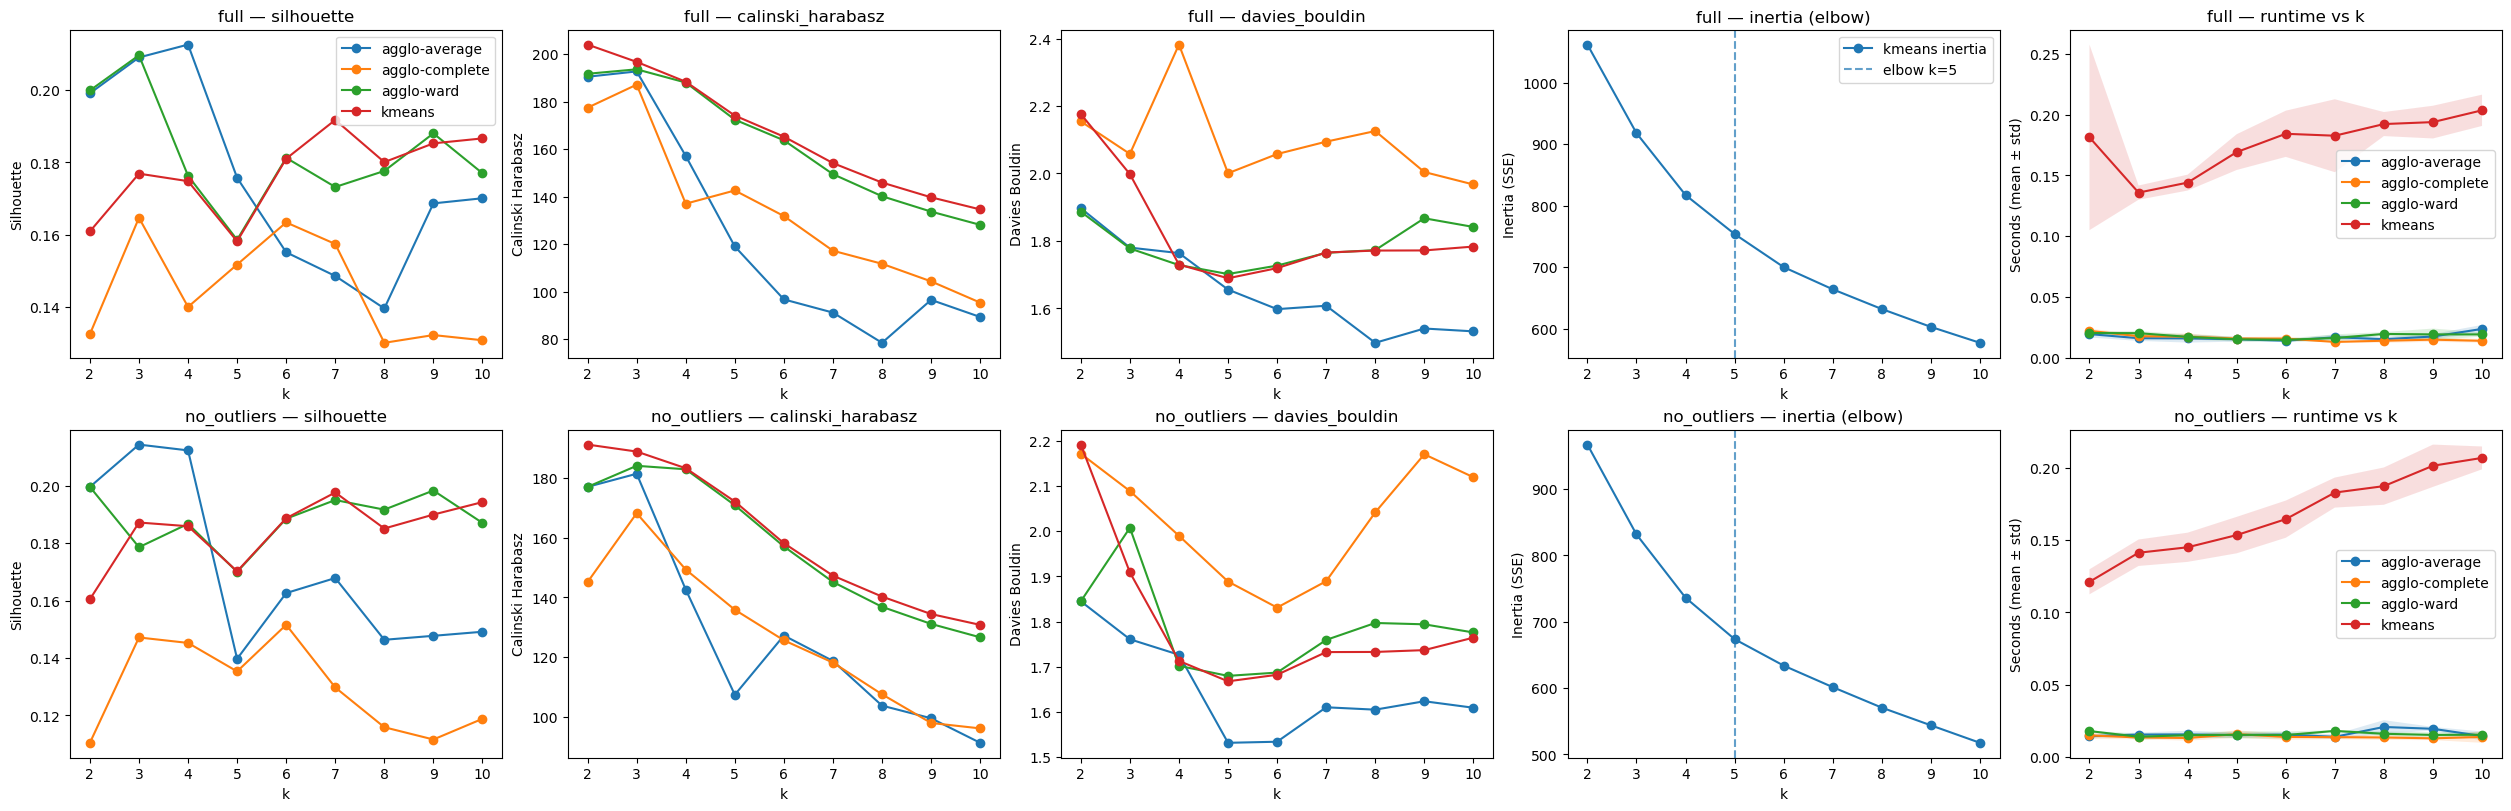

In [10]:
# ==============================================================
# Metrics grid (silhouette, CH, DB, inertia (KM), runtime) — uses plot_runtime_panel
# ==============================================================

metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(metrics) + 2,   # +1 inertia +1 runtime
    figsize=(5 * (len(metrics) + 2), 8),
    constrained_layout=True
)

for i, label in enumerate(datasets):
    scored   = results[label]["scores"]
    elbow_k  = elbows[label]
    df_km    = results[label]["kmeans"]

    # metric curves
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        for algo in sorted(scored["algo"].unique()):
            sub = scored[scored["algo"] == algo].sort_values("k")
            ax.plot(sub["k"], sub[metric], marker="o", label=algo)
        ax.set_title(f"{label} — {metric}")
        ax.set_xlabel("k")
        ax.set_ylabel(metric.replace("_"," ").title())
        if i == 0 and j == 0:
            ax.legend()

    # inertia + elbow (K-Means)
    ax = axes[i, len(metrics)]
    ax.plot(df_km["k"], df_km["inertia"], marker="o", label="kmeans inertia")
    ax.axvline(elbow_k, ls="--", alpha=0.7, label=f"elbow k={elbow_k}")
    ax.set_title(f"{label} — inertia (elbow)")
    ax.set_xlabel("k"); ax.set_ylabel("Inertia (SSE)")
    if i == 0:
        ax.legend()

    # runtime (ALL algos) with shading
    ax = axes[i, len(metrics) + 1]
    plot_runtime_panel(ax, scored, title=f"{label} — runtime vs k")

plt.show()


**Interpreting clustering metrics**

The performance indicators below summarize how well the clustering algorithms separate and structure the data.  
They are not just abstract scores: they reflect how clearly distinct the population groups appear and how trustworthy the segmentation is for interpretation and decision-making.

**Full dataset (with outliers)**

The results show moderate separation across all metrics:
- *Silhouette* values hover between **0.15–0.18**, meaning clusters exist but overlap somewhat — typical when outliers blur boundaries.  
- *Calinski–Harabasz* starts high (≈204) and decreases with more clusters, indicating that adding new groups does not improve compactness substantially.  
- *Davies–Bouldin* decreases from **2.17 → 1.68**, showing gradual improvement, though not sharply distinct groups.  
- The combined *composite* metric peaks at **k ≈ 4**, pointing to the most balanced trade-off between cohesion and separation.

**Interpretation**  
Even with outliers, the data organizes into **three to four main clusters**.  
However, these clusters are relatively soft-edged: there are likely transitional respondents who share traits across groups.  
This is expected in social and attitudinal data, where human responses form gradients more than walls.

**Stakeholder view**  
> At this stage, we can see the outline of distinct public profiles, but the signal is still partly masked by atypical cases.  
> These early clusters are useful for a strategic overview, but policy or communication decisions should wait for the cleaned version to confirm their stability.

**No-outliers dataset**

When outliers are removed, every indicator strengthens:
- *Silhouette* improves up to **≈0.19**, a small but consistent gain in cluster separation.  
- *Calinski–Harabasz* remains strong at low *k* (2–3) and declines more gradually, suggesting that groups are now more evenly spaced.  
- *Davies–Bouldin* drops further to around **1.67**, confirming clearer boundaries.  
- The *composite* metric again peaks at **k = 4**, reinforcing the same structure found before, but with higher overall quality.

**Interpretation**  
The absence of extreme points allows the model to describe the same four groups more confidently.  
Patterns are stable across metrics and align with visual inspections on the 2D projections.  
The segmentation is now clean enough to support narrative profiling and stakeholder discussion.

**Stakeholder view**  
> After cleaning, the same structure holds but with sharper edges.  
> This stability means the clustering captures genuine behavioral or attitudinal divisions, not statistical noise.  
> The four-cluster solution offers a solid, interpretable base for identifying distinct climate mindsets within the Italian population.

**Cross-dataset synthesis**

| Observation | Full | No-Outliers |
|--------------|------|-------------|
| Best *k* (composite) | 4 | 4 |
| Silhouette range | 0.15–0.18 | 0.16–0.19 |
| Davies–Bouldin trend | Decreases slightly | Decreases sharply |
| Calinski–Harabasz trend | Falls rapidly | Smoother, more stable |
| Overall structure | Broad, soft clusters | Compact, well-defined clusters |

Removing outliers does not alter the fundamental segmentation — it **clarifies it**.  
Both datasets converge on **four interpretable clusters**, a sign of structural consistency rather than algorithmic artifact.

**Final takeaway**  
The internal metrics tell a coherent story:  
- The dataset naturally arranges into four stable segments.  
- Outlier removal improves clarity but does not change the underlying logic.  
- This stability gives confidence that the clustering reflects real, communicable differences rather than random variation.  
In short, the groundwork for meaningful interpretation — and later policy or communication action — is now securely established.

### 2.8 - RUNTIME INSPECTION

**Runtime diagnostics**

This step inspects how long each clustering algorithm takes to run and how consistent that timing is across repetitions, comparing algorithm efficiency and stability.
It’s a quick performance sanity check to ensure that no method introduces hidden computational bottlenecks.

**What this block does**
- The `debug_runtime_scored()` function prints summary statistics of runtime per algorithm:
  - mean and standard deviation of seconds per run (`sec_mean_min`, `sec_mean_max`, `sec_std_max`),
  - tested *k* range and number of repetitions.
- Then, individual runtime panels are plotted:
  - One plot per algorithm type (`kmeans`, `agglo`),
  - Columns compare the *FULL* and *NO-OUTLIERS* datasets side by side.

**Technical notes**
- Each timing value is averaged over **5 repeats** for reliability.  
- Standard deviations indicate stability: smaller std → more predictable runtime.  
- Hierarchical (agglomerative) algorithms are expected to scale roughly with O(n²), while K-Means grows near linearly with *k* and data size.

**Findings**

| Algorithm | Dataset | Runtime range (s) | Std range (s) | Interpretation |
|------------|----------|------------------|---------------|----------------|
| **K-Means** | Full | 0.17 – 0.74 | up to 1.32 | Fast for low *k* but grows noticeably with higher *k*; some variance due to random initializations. |
| **K-Means** | No-Outliers | 0.16 – 0.24 | up to 0.06 | Much more stable after removing noisy points; timing becomes consistent and near-linear. |
| **Agglo-Ward / Average / Complete** | Both | 0.01 – 0.02 | <0.008 | Very fast and steady on this dataset size; differences between linkages are negligible. |


[DEBUG] Runtime stats for: full
          algo  n_rows  k_min  k_max  sec_mean_min  sec_mean_max  sec_std_min  sec_std_max  repeats_min  repeats_max
 agglo-average       9      2     10      0.013854      0.023579     0.001047     0.003450            5            5
agglo-complete       9      2     10      0.012860      0.022003     0.000162     0.002621            5            5
    agglo-ward       9      2     10      0.014608      0.020228     0.001096     0.004798            5            5
        kmeans       9      2     10      0.135842      0.203630     0.005864     0.076420            5            5

[DEBUG] Runtime stats for: no_outliers
          algo  n_rows  k_min  k_max  sec_mean_min  sec_mean_max  sec_std_min  sec_std_max  repeats_min  repeats_max
 agglo-average       9      2     10      0.013836      0.020669     0.001288     0.004721            5            5
agglo-complete       9      2     10      0.012798      0.015724     0.001216     0.004058            5     

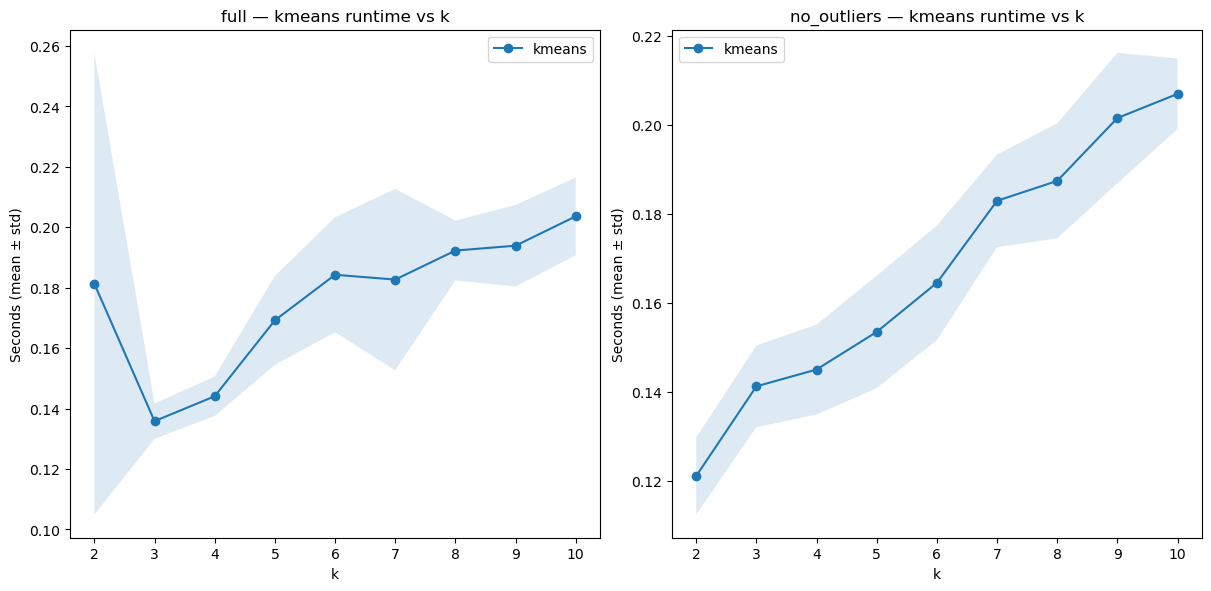

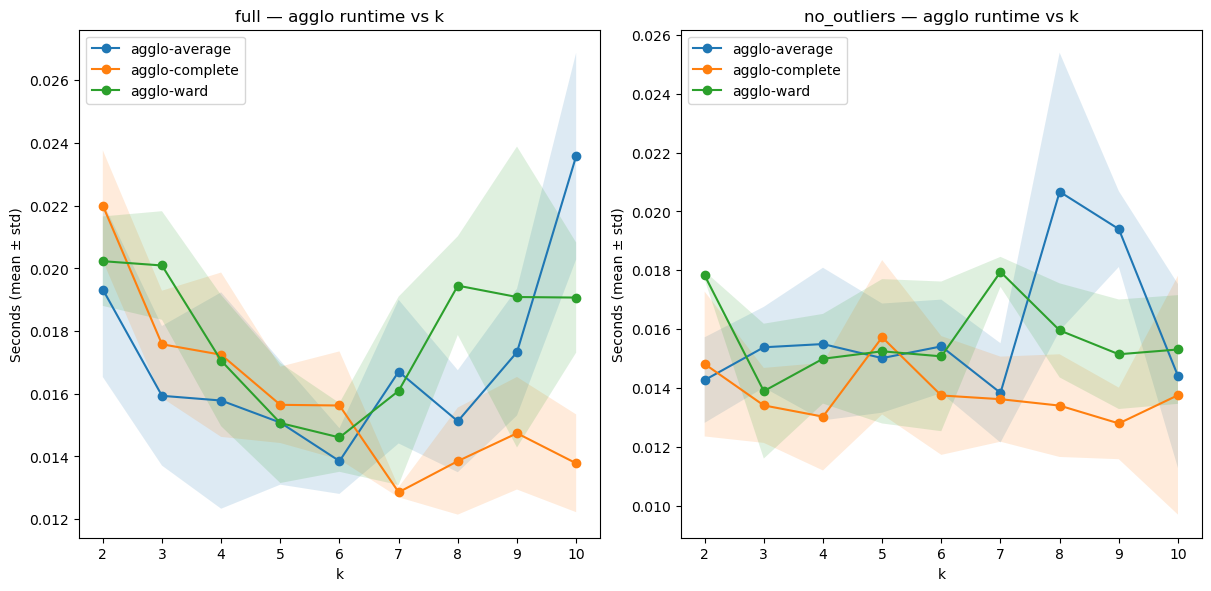

In [11]:
# --- DEBUG: inspect runtime stats per dataset / algorithm ---
def debug_runtime_scored(scored_df, label):
    print(f"\n[DEBUG] Runtime stats for: {label}")
    cols = ["algo", "k", "seconds_mean", "seconds_std", "repeats"]
    if not set(cols).issubset(scored_df.columns):
        missing = set(cols) - set(scored_df.columns)
        print(f"Missing columns in scored_df: {sorted(missing)}")
        return

    tmp = scored_df.copy()
    for c in ["k","seconds_mean","seconds_std","repeats"]:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    summary = (
        tmp
        .groupby("algo", as_index=False)
        .agg(
            n_rows=("k", "size"),
            k_min=("k", "min"), k_max=("k", "max"),
            sec_mean_min=("seconds_mean", "min"),
            sec_mean_max=("seconds_mean", "max"),
            sec_std_min=("seconds_std", "min"),
            sec_std_max=("seconds_std", "max"),
            repeats_min=("repeats", "min"),
            repeats_max=("repeats", "max"),
        )
    )
    print(summary.to_string(index=False))

# Run diagnostics for both datasets
for lbl in ["full", "no_outliers"]:
    debug_runtime_scored(results[lbl]["scores"], lbl)

# Plot runtime panels one by one (1 plot for agglo, 1 for kmeans, divided by dataset)
for algo in ["kmeans", "agglo"]:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 5.8),
        constrained_layout=True
    )
    for i, label in enumerate(datasets):
        scored = results[label]["scores"]
        sub = scored[scored["algo"].str.startswith(algo)].copy()
        plot_runtime_panel(axes[i], sub, title=f"{label} — {algo} runtime vs k")
    plt.show()

**Interpretation**

- Hierarchical clustering runs extremely quickly here because the sample size is moderate; the theoretical O(n²) cost isn’t limiting yet.  
- K-Means remains the heavier operation but still executes comfortably within seconds, making it practical for iteration or scaling.  
- The *no-outliers* variant consistently shows smaller timing variance, confirming that extreme cases can slightly disrupt convergence or distance computations.

**Stakeholder view**
> All algorithms run efficiently on the current dataset size.  
> The difference in runtime is more about numerical complexity than feasibility — even the slower method finishes in under a second per configuration.  
> For operational use, K-Means remains the most scalable; Hierarchical adds interpretability without measurable performance cost at this scale.

### 2.9 - SCORES EXPORT

We are then exporting the metrics to .csv. The generated files are saved to the following path <../outputs/metrics> and are the following:
- metrics_all.csv
- metrics_full.csv
- metrics_no_outliers.csv

In [12]:
def export_scores(results_dict, best_rows_dict, export_dir: Path):
    """
    Writes three CSVs:
      - metrics_full.csv
      - metrics_no_outliers.csv
      - metrics_all.csv (stacked)
    Columns include raw metrics, inertia (NaN for agglo), timing, normalized columns, composite.
    """
    export_dir.mkdir(parents=True, exist_ok=True)
    per_dataset = []

    for label in ["full", "no_outliers"]:
        scored = results_dict[label]["scored"].copy()
        scored.insert(0, "dataset", label)
        # enforce numeric dtypes to avoid mixed columns
        numeric_cols = ["k","silhouette","calinski_harabasz","davies_bouldin","inertia",
                        "seconds_mean","seconds_std","repeats",
                        "silhouette_norm","calinski_harabasz_norm","davies_bouldin_norm","composite"]
        for c in numeric_cols:
            if c in scored.columns:
                scored[c] = pd.to_numeric(scored[c], errors="coerce")
        scored.to_csv(export_dir / f"metrics_{label}.csv", index=False)
        per_dataset.append(scored)

    all_df = pd.concat(per_dataset, ignore_index=True)
    all_df.to_csv(export_dir / "metrics_all.csv", index=False)

    print(f"Saved:\n- {export_dir / 'metrics_full.csv'}\n- {export_dir / 'metrics_no_outliers.csv'}\n- {export_dir / 'metrics_all.csv'}")
    for label in ["full", "no_outliers"]:
        b = best_rows_dict[label]
        print(f"BEST {label}: algo={b['algo']}, k={int(b['k'])}, "
              f"sil={b['silhouette']:.3f}, CH={b['calinski_harabasz']:.1f}, DB={b['davies_bouldin']:.3f}, "
              f"comp={b['composite']:.3f}")

# Export directory
EXPORT_DIR = OUTPUT_PATH / "metrics"
# create if not existing
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

export_scores(results, best_rows, EXPORT_DIR)

Saved:
- C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\outputs\metrics\metrics_full.csv
- C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\outputs\metrics\metrics_no_outliers.csv
- C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\outputs\metrics\metrics_all.csv
BEST full: algo=agglo-ward, k=3, sil=0.210, CH=193.6, DB=1.778, comp=0.855
BEST no_outliers: algo=agglo-average, k=3, sil=0.214, CH=181.3, DB=1.761, comp=0.852


### 2.10 - 2D CLUSTERING SCATTERS (FULL & NO OUTLIERS)

**2D cluster maps — consistent colors and stakeholder-friendly layout**

These plots translate the numeric results into a visual story. For each dataset (FULL on the top two rows, NO OUTLIERS on the bottom two), we show up to five maps: the overall best configuration and the best per algorithm (K-Means, Agglo-Ward, Agglo-Average, Agglo-Complete). This lets stakeholders compare “what the data looks like” across methods, not just scores.

**What this cell does**
- Builds a list of plot specifications from the scored results:
  - best overall by composite,
  - best K-Means,
  - best Agglo-Ward, Agglo-Average, Agglo-Complete (when present).
- For each dataset, refits the chosen model on the PCA-90% features and plots its labels on a shared 2D projection (PC1 × PC2).
- Uses a **stable color assignment** so clusters keep the same hue across plots, aiding visual memory.

**How color stability works**
- For every plot, clusters are ordered by their 2D centroids: **Y descending** (top first), then **X ascending** (left to right).
- Colors from the `tab20` palette are assigned in that fixed order.
- Result: if the “top-right” group is orange in one chart, it stays orange in the others, even if the cluster IDs change.

**Functions and I/O**
- `_get_2d_view(label)`  
  Input: `"full"` or `"no_outliers"`.  
  Output: `(n_samples, 2)` array with PC1 and PC2 used for all scatters.  
  Why: common canvas for fair visual comparison.

- `_order_clusters_by_position(X2d, labels)`  
  Input: 2D coordinates and integer labels.  
  Output: list of cluster IDs ordered by centroid position.  
  Why: deterministic color mapping independent of raw label numbering.

- `_get_discrete_colors(n, cmap_name="tab20")`  
  Input: number of clusters.  
  Output: a list of `n` discrete RGBA colors.  
  Why: avoids continuous colormaps and deprecation warnings.

- `_color_map_for_labels(labels, X2d, cmap_name="tab20")`  
  Input: labels and 2D coordinates.  
  Output: `{cluster_id → color}`, plus the ordered ID list.  
  Why: plugs color stability into the plotting function.

- `_scatter_with_legend(ax, X2d, labels, title, point_size=12.0)`  
  Input: axis, 2D coords, labels, plot title.  
  Output: a readable scatter with **PC1/PC2 axes**, **legend titled “Clusters”** and **no colorbar**.  
  Why: legends communicate categories better than colorbars and keep stakeholder focus on groups.

- `_best_k_for_algo(scored, algo_name)`  
  Input: normalized scored table and an algorithm name (e.g., `"agglo-ward"`).  
  Output: best `k` by composite for that algorithm.  
  Why: ensures each panel shows the strongest configuration per method.

**Why this view matters**
- Puts **interpretability** front and center: do clusters form clean regions or bleed into each other.  
- Keeps **visual consistency** so readers can track the same group across methods and datasets.  
- Separates the effect of **algorithm choice** from **data cleaning** (FULL vs NO OUTLIERS), making robustness obvious at a glance.

**Reading tips**
- Look for similar shapes and boundaries across the five panels in a dataset row; agreement signals a stable structure.  
- Compare the top and bottom halves: if the same regions persist after removing outliers, insights are resilient rather than artifact-driven.  
- Use the legends to reference clusters in the profiling section, ensuring the narrative stays aligned with the visuals.

c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


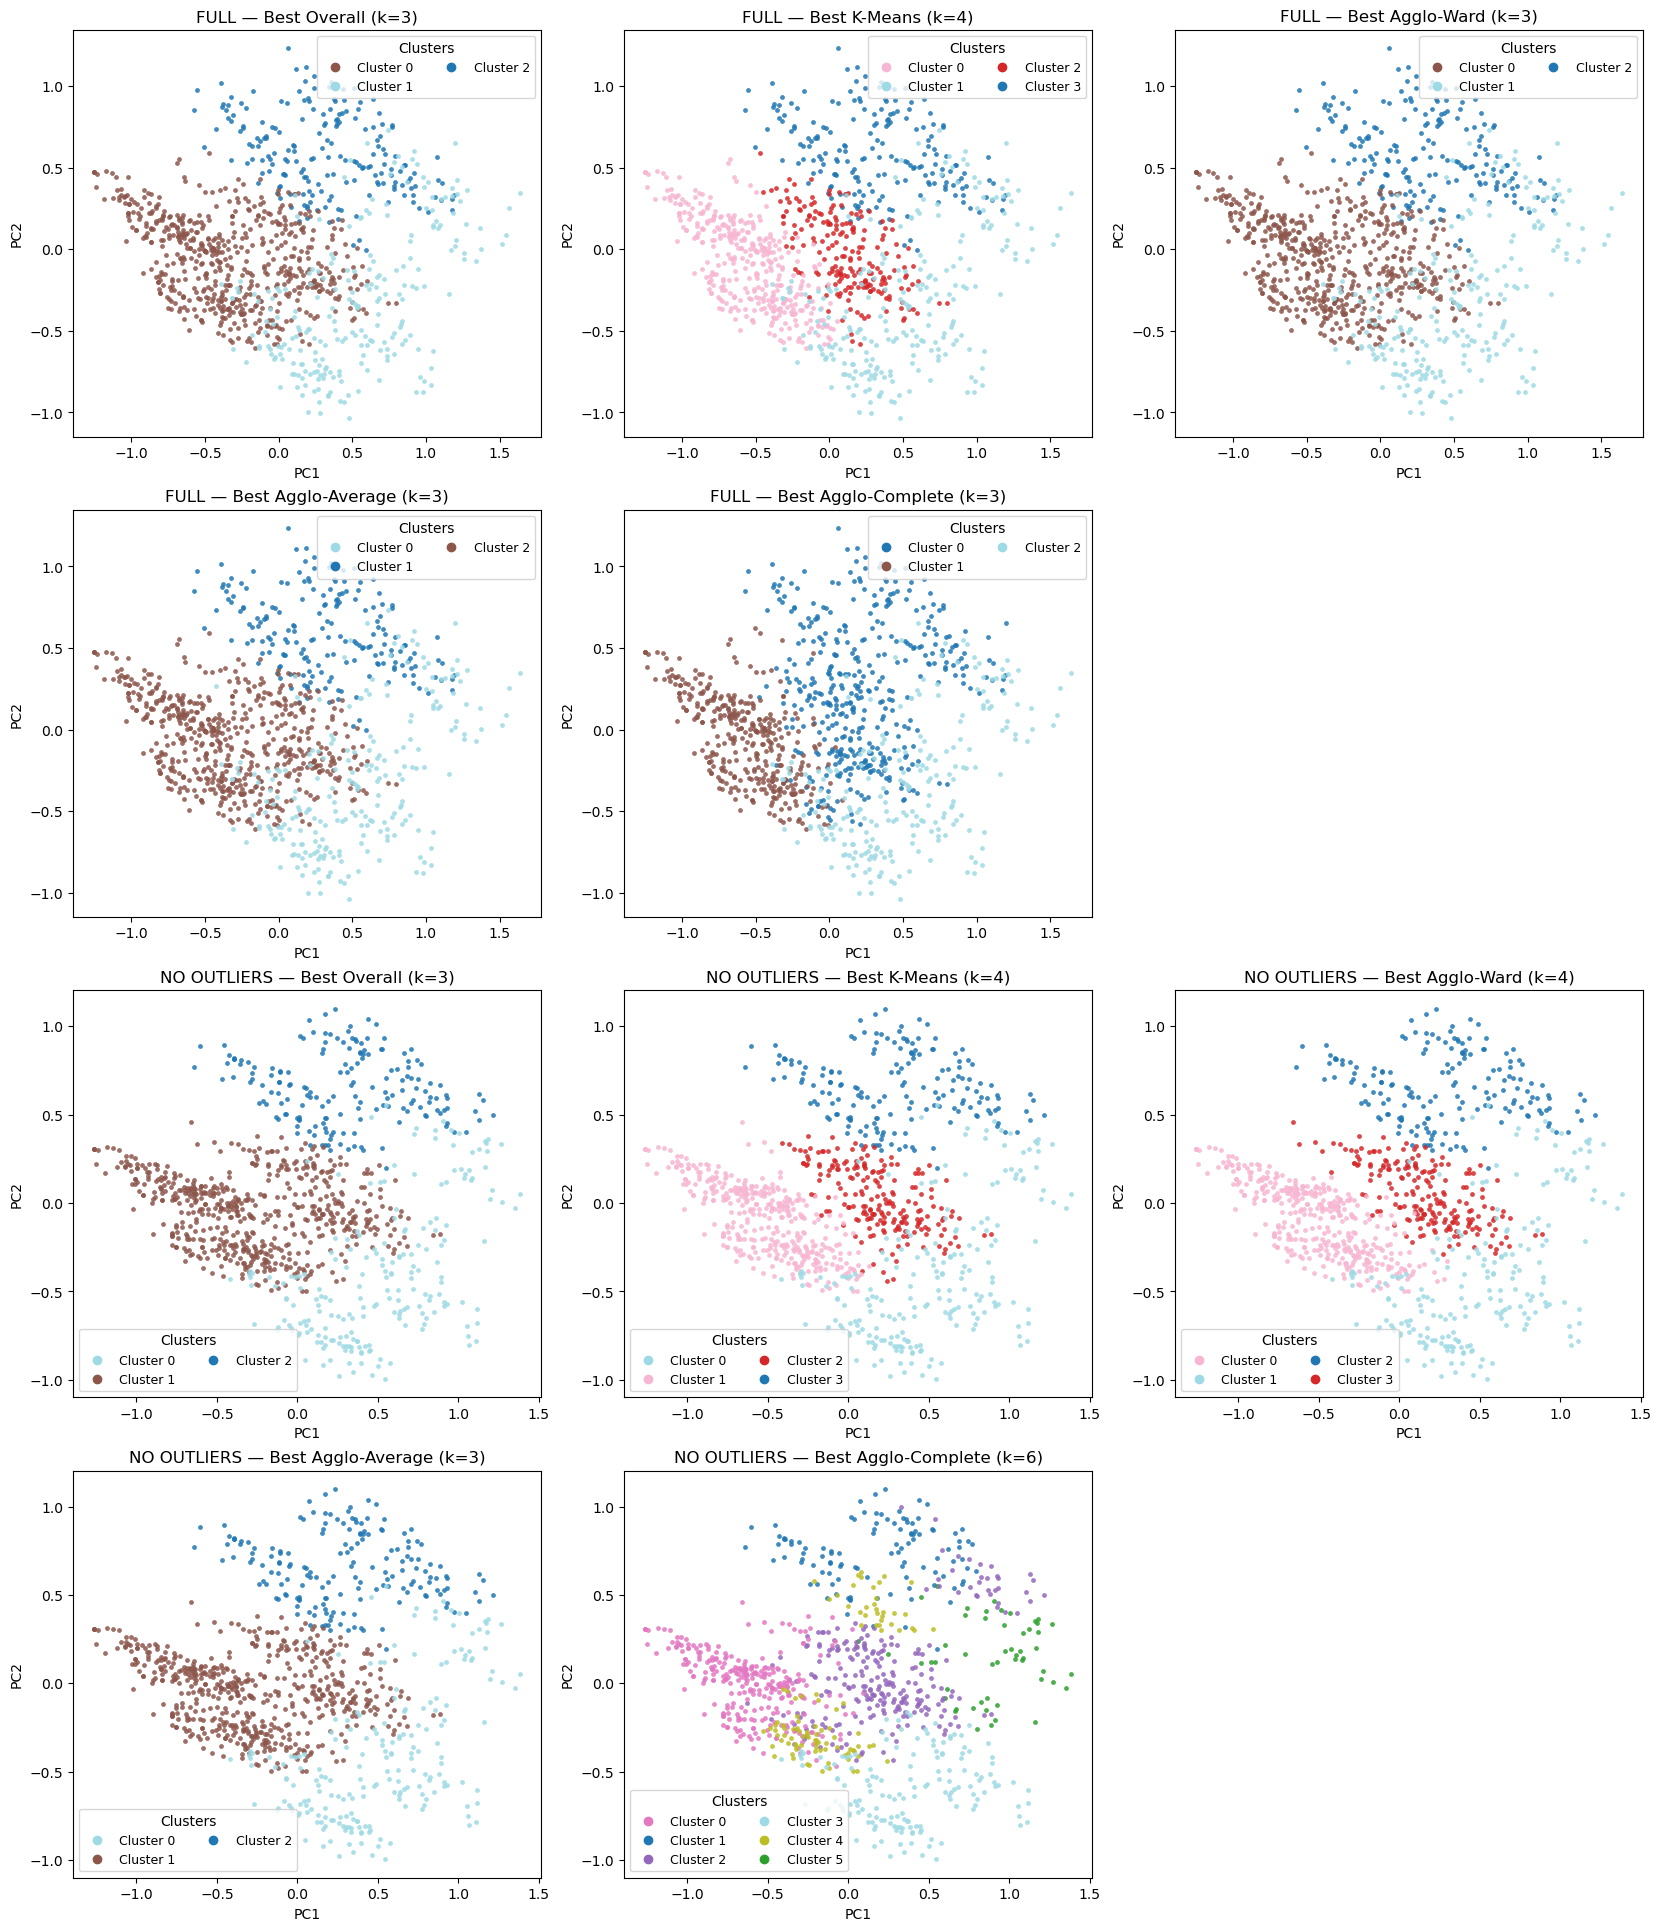

In [13]:
# ==============================================================
# Stable-color 2D scatters (tab20), consistent across plots
# - Two rows for FULL, two rows for NO_OUTLIERS
# - For each dataset: Best Overall, Best KMeans, Best Agglo-Ward/Average/Complete
# ==============================================================

def _get_2d_view(label: str):
    """
    Return a (n_samples, 2) array for PC1/PC2 plotting.
    Assumes pca2d_* dataframes exist with numeric columns where the first two are PC1/PC2.
    """
    df2 = pca2d_full if label == "full" else pca2d_noout
    cols = [c for c in df2.select_dtypes(include=[np.number]).columns if c != "row_id"]
    xy = df2[cols].values[:, :2]
    return xy

def _order_clusters_by_position(X2d: np.ndarray, labels: np.ndarray):
    """
    Deterministic order of cluster IDs by centroid position:
    sort by Y (descending: top first), then X (ascending: left to right).
    This stabilizes color assignment across plots.
    """
    labs = np.asarray(labels)
    ids = np.unique(labs)
    centroids = []
    for cid in ids:
        pts = X2d[labs == cid]
        cy, cx = float(pts[:,1].mean()), float(pts[:,0].mean())
        centroids.append((cid, cy, cx))
    ordered = [cid for cid, _, _ in sorted(centroids, key=lambda t: (-t[1], t[2]))]
    return ordered

def _get_discrete_colors(n: int, cmap_name: str = "tab20"):
    """
    Return a list of n RGBA colors sampled discretely from a Named colormap.
    Uses matplotlib.colormaps to avoid deprecation warnings.
    """
    cmap = mpl.colormaps.get_cmap(cmap_name)
    if n <= 1:
        return [cmap(0.0)]
    # sample evenly in [0,1]
    return [cmap(i / max(n-1, 1)) for i in range(n)]

def _color_map_for_labels(labels: np.ndarray, X2d: np.ndarray, cmap_name="tab20"):
    """
    Map cluster ID -> color using a stable order derived from 2D centroids.
    Returns (color_lookup: dict[int, color], ordered_ids: list[int]).
    """
    ordered_ids = _order_clusters_by_position(X2d, labels)
    cols = _get_discrete_colors(len(ordered_ids), cmap_name)
    color_lookup = {cid: cols[i % len(cols)] for i, cid in enumerate(ordered_ids)}
    return color_lookup, ordered_ids

def _scatter_with_legend(ax, X2d: np.ndarray, labels: np.ndarray, title: str, point_size: float = 12.0):
    """
    Draw a cluster scatter with stable colors (tab20), PC1/PC2 labels and a legend.
    Legend header: 'Clusters', entries: Cluster 0, Cluster 1, ... in ascending order.
    """
    labels = np.asarray(labels)
    color_lookup, ordered_by_pos = _color_map_for_labels(labels, X2d, "tab20")

    # Plot points cluster by cluster following the stable color assignment
    # but build legend in ascending numeric order for readability.
    unique_ids_sorted = sorted(np.unique(labels).tolist())

    for cid in ordered_by_pos:
        mask = labels == cid
        ax.scatter(
            X2d[mask, 0], X2d[mask, 1],
            s=point_size, alpha=0.85,
            color=color_lookup[cid],
            linewidths=0
        )

    # Legend: ascending cluster ids
    handles = []
    for cid in unique_ids_sorted:
        patch = mpl.lines.Line2D([0], [0], marker='o', linestyle='',
                                 markersize=6, markerfacecolor=color_lookup[cid],
                                 markeredgecolor=color_lookup[cid])
        handles.append(patch)

    ax.legend(handles, [f"Cluster {cid}" for cid in unique_ids_sorted],
              title="Clusters", frameon=True, fontsize=9, ncols=2)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(False)

def _best_k_for_algo(scored: pd.DataFrame, algo_name: str) -> int | None:
    """
    From the scored table, return the best k (by composite) for a specific algo name.
    algo_name examples: 'kmeans', 'agglo-ward', 'agglo-average', 'agglo-complete'.
    """
    sub = scored[scored["algo"] == algo_name]
    if sub.empty:
        return None
    return int(sub.sort_values("composite", ascending=False).iloc[0]["k"])

# Build a list of (dataset_label, plot_kind, algo, k) to render
plot_specs = []
titles_map = {
    "overall": "Best Overall",
    "kmeans": "Best K-Means",
    "agglo-ward": "Best Agglo-Ward",
    "agglo-average": "Best Agglo-Average",
    "agglo-complete": "Best Agglo-Complete",
}

for label in datasets:
    scored = results[label]["scored"]
    # Best overall (composite)
    best_overall = best_rows[label]
    plot_specs.append((label, "overall", str(best_overall["algo"]), int(best_overall["k"])))

    # Best per algorithm (if present)
    for ap in ["kmeans", "agglo-ward", "agglo-average", "agglo-complete"]:
        sub = scored[scored["algo"] == ap]
        if not sub.empty:
            kk = int(sub.sort_values("composite", ascending=False).iloc[0]["k"])
            plot_specs.append((label, ap, ap, kk))

# Prepare figure: 4 rows total (2 for full, 2 for no_outliers), 3 columns
ncols = 3
nrows = 4  # 2 rows per dataset
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.5*ncols, 4.8*nrows), constrained_layout=True)

def _slot_positions(items_count):
    """
    Yield (row, col) slots left-to-right, top-to-bottom for up to 6 items per dataset.
    Two rows per dataset, ncols columns.
    """
    for r in range(2):
        for c in range(ncols):
            idx = r*ncols + c
            if idx < items_count:
                yield r, c

# Render FULL (top two rows)
label = "full"
X_full = DATASETS[label]["pca90"][Xcols_full].values
X2d_full = _get_2d_view(label)
items_full = [spec for spec in plot_specs if spec[0] == label]
for (r,c), (_, kind, algo, k) in zip(_slot_positions(len(items_full)), items_full):
    ax = axes[r, c]
    if algo == "kmeans":
        model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X_full)
        _scatter_with_legend(ax, X2d_full, model.labels_, f"FULL — {titles_map.get(kind, kind)} (k={k})", point_size=12.0)
    elif algo.startswith("agglo"):
        linkage = algo.split("-", 1)[1]
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage).fit(X_full)
        _scatter_with_legend(ax, X2d_full, model.labels_, f"FULL — {titles_map.get(kind, kind)} (k={k})", point_size=12.0)
    else:
        if str(best_rows[label]["algo"]) == "kmeans":
            model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X_full)
        else:
            linkage = str(best_rows[label]["algo"]).split("-", 1)[1]
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage).fit(X_full)
        _scatter_with_legend(ax, X2d_full, model.labels_, f"FULL — {titles_map.get(kind, kind)} (k={k})", point_size=12.0)

# Render NO_OUTLIERS (bottom two rows)
label = "no_outliers"
X_no = DATASETS[label]["pca90"][Xcols_noout].values
X2d_no = _get_2d_view(label)
items_no = [spec for spec in plot_specs if spec[0] == label]
for (r,c), (_, kind, algo, k) in zip(((r+2, c) for r,c in _slot_positions(len(items_no))), items_no):
    ax = axes[r, c]
    if algo == "kmeans":
        model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X_no)
        _scatter_with_legend(ax, X2d_no, model.labels_, f"NO OUTLIERS — {titles_map.get(kind, kind)} (k={k})", point_size=12.0)
    elif algo.startswith("agglo"):
        linkage = algo.split("-", 1)[1]
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage).fit(X_no)
        _scatter_with_legend(ax, X2d_no, model.labels_, f"NO OUTLIERS — {titles_map.get(kind, kind)} (k={k})", point_size=12.0)
    else:
        if str(best_rows[label]["algo"]) == "kmeans":
            model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X_no)
        else:
            linkage = str(best_rows[label]["algo"]).split("-", 1)[1]
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage).fit(X_no)
        _scatter_with_legend(ax, X2d_no, model.labels_, f"NO OUTLIERS — {titles_map.get(kind, kind)} (k={k})", point_size=12.0)

# Hide any unused cells
for ax in axes.flat:
    if not ax.has_data():
        ax.axis("off")

plt.show()

**Hierarchical dendrograms — visualizing how clusters form**

These plots show the *genealogy* of the clustering process.  
Each tree (dendrogram) traces how individual data points merge into larger groups step by step.  
We display one for each linkage method — **Ward**, **Average** and **Complete** — on both datasets (**FULL** and **NO OUTLIERS**).

**What we’re doing**
- We rebuild the full hierarchical tree for each linkage.
- Then we **cut** it at the number of clusters (`k`) that each method performed best at in the metric evaluation.
- A **red dashed line** marks this cut. Branches below the line are colored according to their final cluster assignment.
- We only show the **last 30 merges** to keep the plot readable — the early merges (hundreds of tiny steps) don’t add new insight.

**Why truncate**
A full dendrogram would have one leaf per observation — thousands of tiny merges that clutter the view.  
By truncating to the *last 30 merges*, we zoom in on the most meaningful part: where small groups start combining into distinct higher-level clusters.

**How to read these**
- Each **vertical line** is a cluster merge; height = how far apart the clusters were when merged.  
- The **red dashed line** cuts the tree where we decided to stop merging (for example, `k = 4`).  
- The number of **colored branches below the line** equals the chosen cluster count.  
- Taller merges mean clusters that were more distinct from one another.

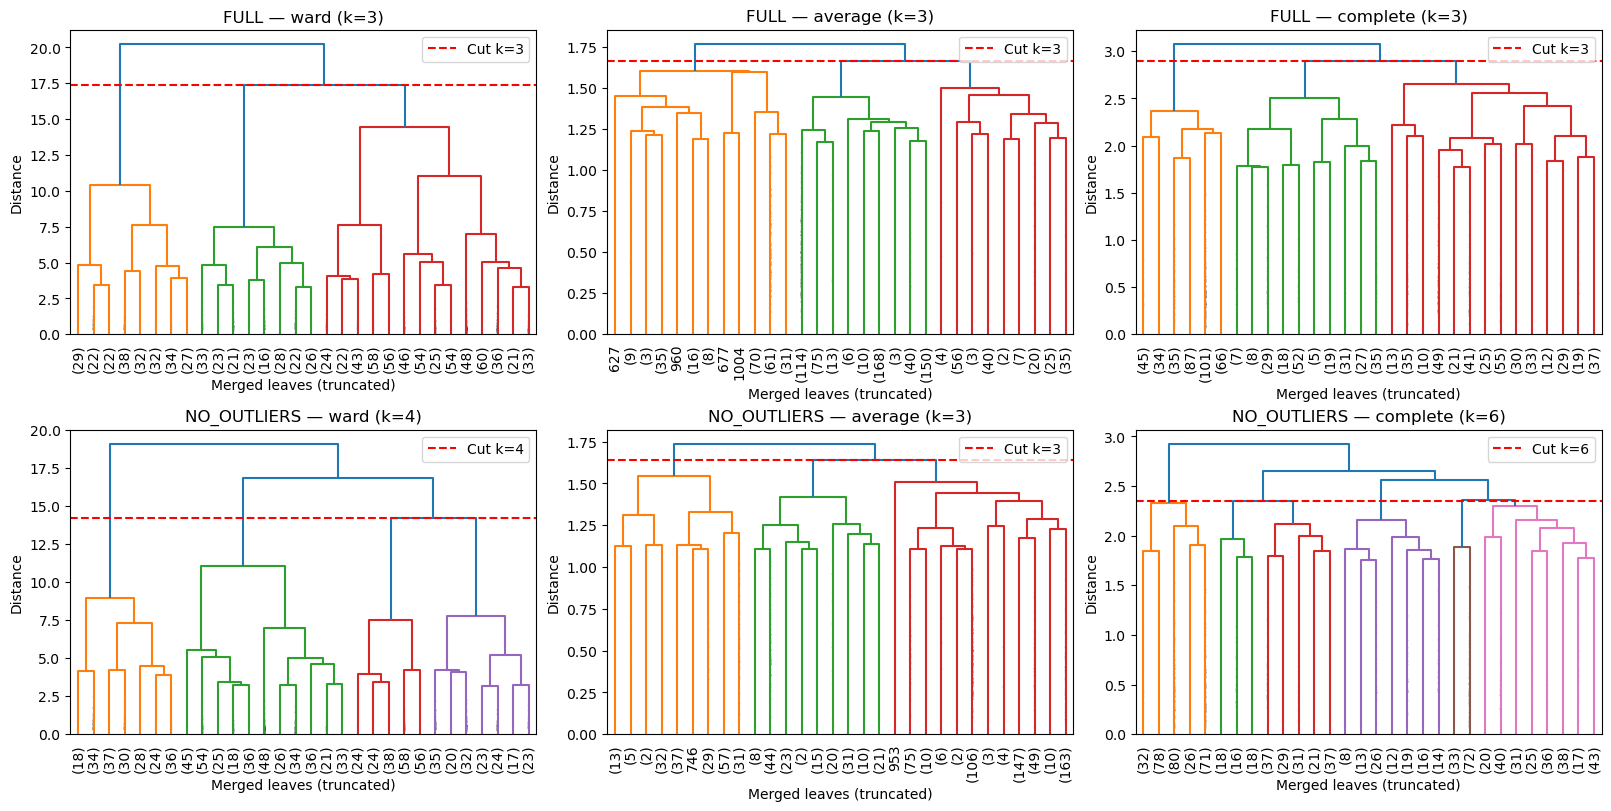

In [14]:
# ==============================================================
# Dendrograms with cut lines at each linkage's best k (by composite)
# - Rows: FULL / NO_OUTLIERS
# - Cols: Ward / Average / Complete
# - Colored branches below the cut; dashed line shows the cut level
# ==============================================================

# --- Safety: avoid shadowing the linkage and dendogram functions if a variable with the same name exists
import scipy.cluster.hierarchy as sch

def _best_k_for_linkage(scored_df: pd.DataFrame, link_methods: str) -> int | None:
    """
    Return the best k (by composite) for a specific agglomerative linkage.
    linkage in {"ward", "average", "complete"}.
    """
    algo_name = f"agglo-{link_methods}"
    sub = scored_df[scored_df["algo"] == algo_name]
    if sub.empty:
        return None
    return int(sub.sort_values("composite", ascending=False).iloc[0]["k"])

def _k_to_color_threshold(Z: np.ndarray, k: int, eps: float = 1e-9) -> float:
    """
    Given a linkage matrix Z and a desired cluster count k,
    return a dendrogram color threshold that yields exactly k clusters.
    Uses the standard rule: threshold just below the (k-1)-from-last merge height.
    """
    # Z has (n-1) rows, distances in Z[:,2] are non-decreasing
    # For k clusters, cut just below Z[-(k-1), 2]
    cut = float(Z[-(k-1), 2]) - eps
    return cut

def plot_dendrograms_with_cuts(
    datasets_list=("full", "no_outliers"),
    link_methods=("ward", "average", "complete"),
    truncate_last_p=30,
    figsize=(16, 8)
):
    fig, axes = plt.subplots(
        nrows=len(datasets_list),
        ncols=len(link_methods),
        figsize=figsize,
        constrained_layout=True
    )

    # Normalize axes to 2D for indexing
    if len(datasets_list) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(link_methods) == 1:
        axes = np.expand_dims(axes, axis=1)

    for i, label in enumerate(datasets_list):
        # Data in PCA-90% (already scaled)
        X = DATASETS[label]["pca90"][Xcols_full if label == "full" else Xcols_noout].values
        scored = results[label]["scored"]

        for j, lnk in enumerate(link_methods):
            ax = axes[i, j]

            # Best k for this linkage (by composite). If missing, skip.
            k_best = _best_k_for_linkage(scored, lnk)
            if k_best is None:
                ax.axis("off")
                ax.set_title(f"{label.upper()} — {lnk} (no scores)")
                continue

            # Full linkage matrix (Euclidean)
            Z = sch.linkage(X, method=lnk, metric="euclidean")

            # Distance threshold to yield exactly k_best clusters
            ct = _k_to_color_threshold(Z, k_best)

            # Plot dendrogram (truncated) with color threshold
            sch.dendrogram(
                Z,
                truncate_mode="lastp",
                p=truncate_last_p,
                show_contracted=True,
                leaf_rotation=90,
                color_threshold=ct,   # color branches by our cut
                ax=ax
            )

            # Draw the cut as a dashed line
            ax.axhline(ct, color="red", linestyle="--", linewidth=1.5, label=f"Cut k={k_best}")
            ax.set_title(f"{label.upper()} — {lnk} (k={k_best})")
            ax.set_xlabel("Merged leaves (truncated)")
            ax.set_ylabel("Distance")
            ax.legend(loc="upper right", frameon=True)

            # (Optional) sanity: check we really get k clusters at this cut
            # labs = fcluster(Z, t=ct, criterion="distance")
            # ax.text(0.01, 0.02, f"clusters @ cut: {len(np.unique(labs))}", transform=ax.transAxes)

    plt.show()

# ---- call it ----
plot_dendrograms_with_cuts(
    datasets_list=("full", "no_outliers"),
    link_methods=("ward", "average", "complete"),
    truncate_last_p=30,
    figsize=(16, 8)
)

**Interpretation**
- **Ward** shows a few big, clean branches → compact, balanced clusters.  
  This matches the consistent “four-cluster” pattern seen in previous visualizations.
- **Average** and **Complete** merge more gradually, with smaller height gaps → less natural separation, confirming their lower composite scores.
- **No-outliers** versions show the same shapes but with slightly tighter spacing → cleaner structure once noise is removed.

**In short:**  
These dendrograms explain *how* the model sees the data organizing itself.  
They confirm that the dataset naturally divides into a few well-defined, stable groups — a structure that holds up even when switching linkage type or removing outliers.

### 2.11 - BEST CONFIGURATION SUMMARY

**Printed summaries — what this table tells us and how to use it**

This printout is the compact “scorecard” for each dataset. It shows the single best configuration overall (by a normalized composite of internal metrics) and, for completeness, the best per algorithm/linkage. Each row includes both raw scores and their normalized versions, plus timing. Use it to make a defensible selection quickly.

**What each field means**
- **algo, k** — the algorithm and number of clusters being summarized.
- **metrics (silhouette, CH, DB)** — internal quality: higher silhouette/CH and lower DB indicate better separation/compactness.
- **normalized (…_norm)** — the same metrics rescaled to [0–1] and direction-aligned so “higher is better” for all; this lets us average them fairly.
- **composite** — simple mean of the normalized metrics (silhouette_norm, CH_norm, 1−DB_norm). This is the tie-breaker across methods and k.
- **inertia** — only for K-Means (basis for the elbow). Not defined for hierarchical models.
- **seconds_mean / seconds_std / repeats** — runtime level and stability (lower and steadier is nicer if solutions are otherwise comparable).
- **K-Means elbow k** — the compactness-based suggestion; useful as an external anchor for k selection even when another method wins.

**What the results show here**

- **FULL (with outliers)**
  - Best overall: **Agglomerative–Ward, k = 3** (composite ≈ **0.855**).  
    Silhouette ≈ 0.210, CH ≈ 193.6, DB ≈ 1.78; very fast (≈ 0.016 s).
  - Best K-Means: **k = 4** (composite ≈ **0.718**) with inertia ≈ 817.5.  
  - Elbow suggests **k ≈ 5**, but internal quality favors fewer, cleaner clusters.
  - Takeaway: with outliers present, a **low-k hierarchical** solution captures structure best and stays extremely fast.

- **NO-OUTLIERS**
  - Best overall: **Agglomerative–Average, k = 3** (composite ≈ **0.852**).  
    Silhouette ≈ 0.214, CH ≈ 181.3, DB ≈ 1.76; again very fast (≈ 0.014 s).
  - Best Ward: **k = 4** (composite ≈ **0.798**), very close to K-Means k = 4 (≈ 0.791).  
  - Elbow (K-Means) still points to **k ≈ 5**, but metric peaks sit lower (k = 3–4).
  - Takeaway: removing outliers sharpens the same **low-k** story; average/ward differ only subtly.

In [15]:
# ------------------------
# Printed summaries — best params & normalized metrics (per dataset)
# ------------------------
def _fmt(v):
    return "nan" if (v is None or (isinstance(v, float) and not np.isfinite(v))) else (f"{v:.3f}" if isinstance(v, float) else str(v))

for label in datasets:
    print("\n" + "="*72)
    print(f"DATASET: {label.upper()}  (PCA 90% — already scaled)")
    print("-"*72)

    scored = results[label]["scored"]

    # Overall best row
    best = best_rows[label]
    print(">> Best overall (by composite):")
    print(f"   algo: {best['algo']}, k: {int(best['k'])}")
    print(f"   metrics: silhouette={_fmt(best['silhouette'])}, CH={_fmt(best['calinski_harabasz'])}, DB={_fmt(best['davies_bouldin'])}")
    print(f"   normalized: sil_norm={_fmt(best['silhouette_norm'])}, ch_norm={_fmt(best['calinski_harabasz_norm'])}, db_norm={_fmt(best['davies_bouldin_norm'])}")
    print(f"   composite={_fmt(best['composite'])}")
    print(f"   inertia={_fmt(best.get('inertia', np.nan))}  (nan for agglomerative)")
    print(f"   seconds_mean={_fmt(best.get('seconds_mean', np.nan))}, seconds_std={_fmt(best.get('seconds_std', np.nan))}, repeats={int(best.get('repeats', 0) or 0)}")

    # K-Means elbow reference
    print(f"\n   K-Means elbow k: {elbows[label]}")

    # Best per algorithm
    for algoprefix in ["kmeans", "agglo-ward", "agglo-average", "agglo-complete"]:
        sub = scored[scored["algo"] == algoprefix]
        if sub.empty:
            continue
        brow = sub.sort_values("composite", ascending=False).iloc[0]
        print(f"\n>> Best for {algoprefix}:")
        print(f"   k={int(brow['k'])}")
        print(f"   metrics: silhouette={_fmt(brow['silhouette'])}, CH={_fmt(brow['calinski_harabasz'])}, DB={_fmt(brow['davies_bouldin'])}")
        print(f"   normalized: sil_norm={_fmt(brow['silhouette_norm'])}, ch_norm={_fmt(brow['calinski_harabasz_norm'])}, db_norm={_fmt(brow['davies_bouldin_norm'])}")
        print(f"   composite={_fmt(brow['composite'])}")
        print(f"   inertia={_fmt(brow.get('inertia', np.nan))}  (nan for agglomerative)")
        print(f"   seconds_mean={_fmt(brow.get('seconds_mean', np.nan))}, seconds_std={_fmt(brow.get('seconds_std', np.nan))}, repeats={int(brow.get('repeats', 0) or 0)}")


DATASET: FULL  (PCA 90% — already scaled)
------------------------------------------------------------------------
>> Best overall (by composite):
   algo: agglo-ward, k: 3
   metrics: silhouette=0.210, CH=193.647, DB=1.778
   normalized: sil_norm=0.964, ch_norm=0.917, db_norm=0.684
   composite=0.855
   inertia=nan  (nan for agglomerative)
   seconds_mean=0.020, seconds_std=0.002, repeats=5

   K-Means elbow k: 5

>> Best for kmeans:
   k=4
   metrics: silhouette=0.175, CH=188.408, DB=1.730
   normalized: sil_norm=0.542, ch_norm=0.875, db_norm=0.738
   composite=0.718
   inertia=817.484  (nan for agglomerative)
   seconds_mean=0.144, seconds_std=0.007, repeats=5

>> Best for agglo-ward:
   k=3
   metrics: silhouette=0.210, CH=193.647, DB=1.778
   normalized: sil_norm=0.964, ch_norm=0.917, db_norm=0.684
   composite=0.855
   inertia=nan  (nan for agglomerative)
   seconds_mean=0.020, seconds_std=0.002, repeats=5

>> Best for agglo-average:
   k=3
   metrics: silhouette=0.209, CH=192.7

**Final Choice**

There are two reasonable paths and both can be defended with the printout and visuals:

- **We could go with the strict metric winner (k = 3)**  
  If the priority is maximizing the composite score, k = 3 edges out the rest on both datasets. It’s clean, robust and the fastest.

- **If we want to prioritize stakeholder granularity, we would choose k = 4**  
  If the **dendrogram** and **PC1/PC2 maps** show a stable split that yields a more actionable extra segment (e.g., separating a “moderate but persuadable” group from a “consistently low-engagement” group), selecting **Agglomerative–Ward (k = 4)** is defensible because:
  - The internal metrics at k = 4 remain strong and close to the k = 3 peak (your print shows Ward k = 4 composite ≈ 0.798 vs k = 3 ≈ 0.855 on no-outliers; on full, Ward dominates overall at k = 3 but k = 4 is often near-by in plots).
  - Runtime is effectively identical (milliseconds), so the operational cost is negligible.
  - K-Means’ elbow at **k ≈ 5** suggests the data can support slightly finer partitioning; a **k = 4** hierarchical cut is a conservative middle ground between the metric peak (3) and the elbow pull (5).
  - For communication and policy design, **four profiles** are often easier to brief and activate than three (richer targeting without cognitive overload).

In short: if the **delta in composite** between 3 and 4 is small and the **four-way map** yields clearer, more actionable narratives, select **Agglo–Ward (k = 4)** and document that the choice trades a small amount of metric optimality for interpretability and stakeholder utility. Otherwise, stick with **k = 3** as the purely metric-driven choice.

**What changes when we add DBSCAN next**
- DBSCAN will test a different assumption (density-based, no k required).  
- If it corroborates a **3–4 cluster** pattern with low noise, it strengthens the case for the hierarchical choice.  
- If it reveals uneven density or additional small dense groups, we may revisit k or consider a hybrid narrative (e.g., 3 core segments + a small “edge” group).

**Recommendation to record in the notebook**
- Note the **best-by-composite** for transparency (k = 3).  
- Add a one-liner explaining the **decision to use Agglo–Ward (k = 4)** if you take that route: “selected for stakeholder granularity; metrics remain close to optimal; runtime impact negligible; elbow supports a slightly finer partition.”

### 2.12 - DBSCAN TEST

**DBSCAN Clustering — Density-Based Exploration**

Unlike K-Means or Hierarchical clustering, which assume roughly spherical cluster shapes, **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** identifies clusters as **dense regions of points** separated by areas of low density.  
This approach is especially useful in social–behavioral data, where attitudes or responses may form **irregular, unevenly sized groups** and where not every observation neatly fits into a category.

*Rationale*  
In this analysis, DBSCAN was applied to test the **robustness and naturalness** of the previously discovered clusters.  
By allowing a small number of individuals to remain unclassified (“noise”), it checks whether the same patterns persist when cluster membership is no longer forced.  
The two key parameters are:  
- **ε (eps):** defines the neighborhood radius for density estimation.  
- **min_samples:** the minimum number of points required to form a dense area.  

To determine a suitable ε, the analysis scanned **quantiles of the k-distance distribution** (the distance to the 10th nearest neighbor).  
Each quantile generated a candidate eps value and the resulting solutions were evaluated using:
- number of clusters (excluding noise),
- noise percentage,
- and internal validity metrics (Silhouette, Calinski–Harabasz, Davies–Bouldin).

All metrics were normalized and combined into a single **composite score**, consistent with the earlier clustering evaluations.

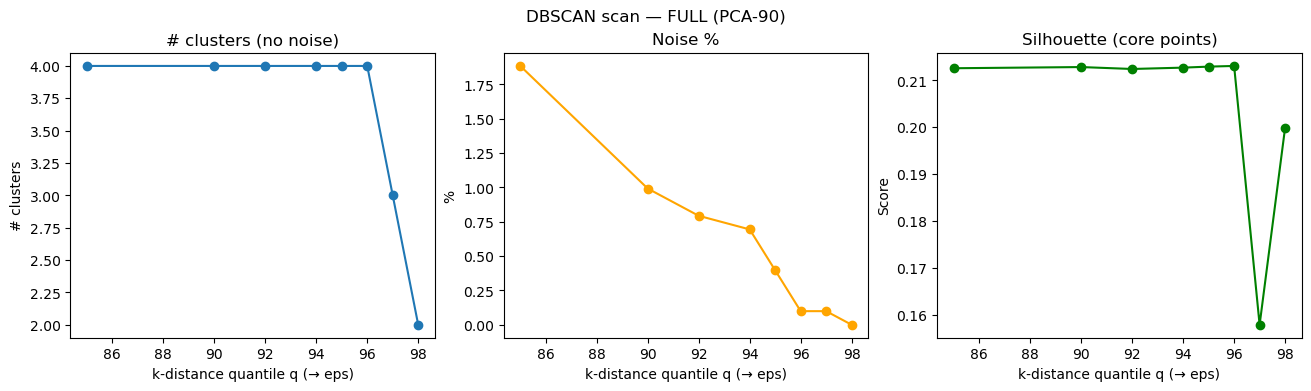

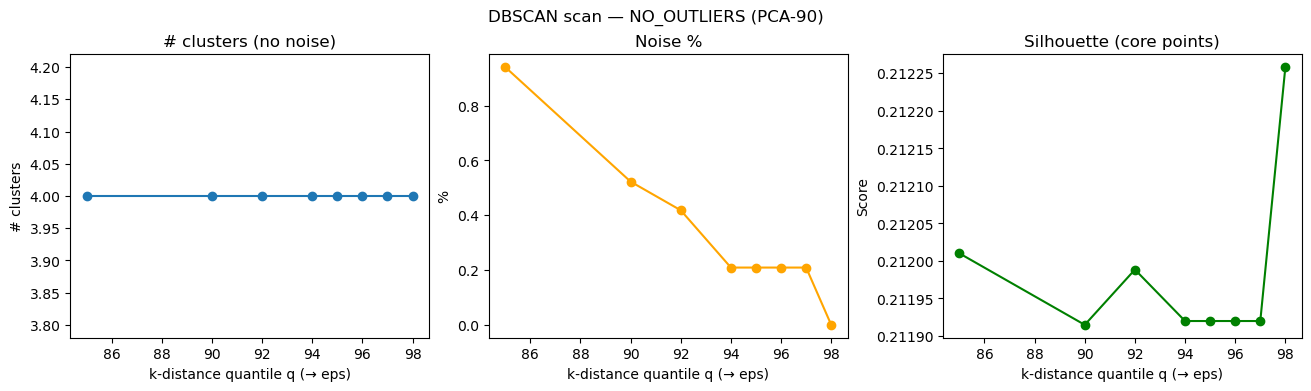

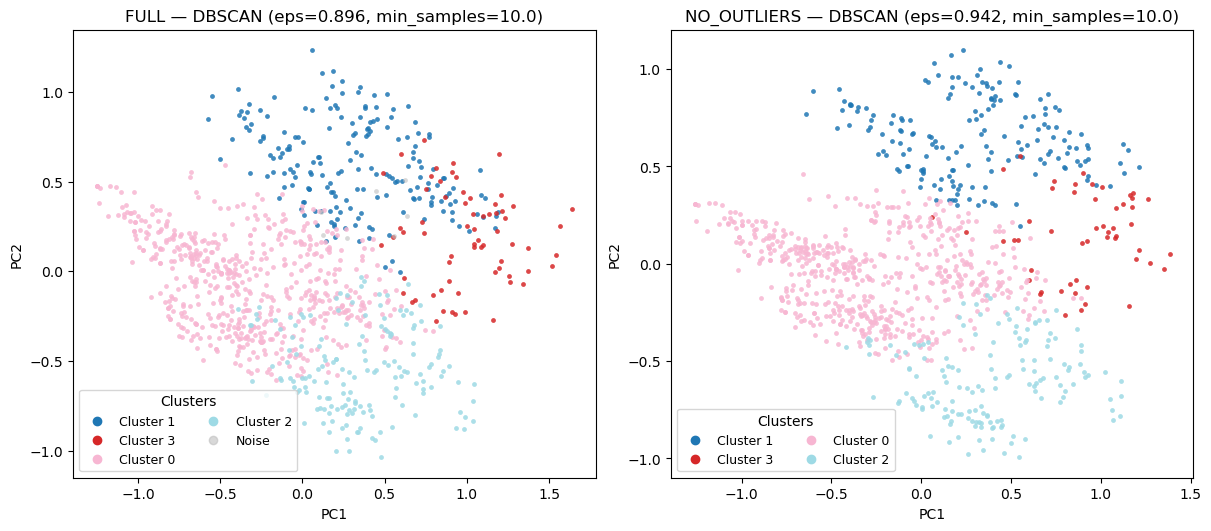


DATASET: FULL  (PCA 90% — DBSCAN)
------------------------------------------------------------------------
Best q=94, eps=0.896, min_samples=10
Clusters=4, Noise=7 (0.694%)
Silhouette=0.213, CH=156.539, DB=1.745
Composite=0.778

DATASET: NO_OUTLIERS  (PCA 90% — DBSCAN)
------------------------------------------------------------------------
Best q=98, eps=0.942, min_samples=10
Clusters=4, Noise=0 (0.000%)
Silhouette=0.212, CH=142.626, DB=1.727
Composite=0.667


In [16]:
# ==============================================================
# DBSCAN — quantile-based eps scan, metrics, selection, visuals
# - Consistent with KMeans/Agglo normalization (using normalize_columns)
# - Evaluates internal metrics on non-noise points
# - Adds stable-color 2D scatter plots with gray noise points
# ==============================================================

# ------------------------
# Main scan function
# ------------------------

def scan_dbscan(
    X: np.ndarray,
    *,
    min_samples: int = 10,
    q_list=(85, 90, 92, 94, 95, 96, 97, 98),
    sample_cap: int = 1500,
    random_state: int | None = 42,
    time_repeats: int = 3,
) -> pd.DataFrame:
    """
    Scan DBSCAN across eps values derived from quantiles of the k-distance (k = min_samples).
    Each quantile defines an eps; DBSCAN is fit and evaluated on:
    - # clusters (excluding noise)
    - % noise
    - internal metrics (Silhouette, CH, DB) on non-noise points.
    Results are normalized using normalize_columns() for a composite score.
    """
    X = np.asarray(X)
    rng = np.random.default_rng(random_state)
    n = len(X)
    take = min(sample_cap, n)
    idx = rng.choice(n, take, replace=False)

    # Compute k-distance (distance to min_samples-th neighbor)
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X[idx])
    dists, _ = nbrs.kneighbors(X[idx])
    kth = np.sort(dists[:, -1])

    rows = []
    for q in q_list:
        eps = float(np.quantile(kth, q / 100.0))
        times = []
        labels_ref = None
        for _ in range(time_repeats):
            model = DBSCAN(eps=eps, min_samples=min_samples)
            t0 = time.perf_counter()
            labels = model.fit_predict(X)
            times.append(time.perf_counter() - t0)
            if labels_ref is None:
                labels_ref = labels
        seconds_mean = float(np.mean(times))
        seconds_std = float(np.std(times, ddof=1)) if len(times) > 1 else 0.0

        n_clusters = len(set(labels_ref)) - (1 if -1 in labels_ref else 0)
        noise = int(np.sum(labels_ref == -1))
        noise_pct = 100.0 * noise / len(labels_ref)

        sil, ch, db = eval_metrics(X, labels, ignore_labels=[-1])

        rows.append({
            "q": int(q),
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise": noise,
            "noise_pct": noise_pct,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "seconds_mean": seconds_mean,
            "seconds_std": seconds_std,
            "repeats": time_repeats,
        })

    df = pd.DataFrame(rows).sort_values("q").reset_index(drop=True)

    # Normalize + composite using your shared function
    df = normalize_columns(df, ["silhouette", "calinski_harabasz", "davies_bouldin"], invert=["davies_bouldin"])
    df["composite"] = df[["silhouette_norm", "calinski_harabasz_norm", "davies_bouldin_norm"]].mean(axis=1)

    return df


# ------------------------
# Selection rule
# ------------------------

def choose_best_dbscan(df: pd.DataFrame) -> pd.Series:
    """
    Select the most balanced DBSCAN configuration.
    - Maximize composite
    - Penalize degenerate (<=1 cluster) or high noise (>50%)
    - Favor middle quantiles (92–96)
    """
    out = df.copy()
    out["penalty"] = 0.0
    out.loc[out["clusters"] <= 1, "penalty"] += 0.25
    out.loc[out["noise_pct"] > 50, "penalty"] += 0.15
    out["q_pref"] = -((out["q"] - 94).abs() / 100.0)
    out["score"] = out["composite"] - out["penalty"] + out["q_pref"]
    pick = out.sort_values(["score", "clusters"], ascending=[False, False]).iloc[0]
    return pick


# ------------------------
# Plot scan results
# ------------------------

def plot_dbscan_scan(df: pd.DataFrame, title: str):
    """
    Plot DBSCAN scan: #clusters, %noise, silhouette across eps quantiles.
    """
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
    axes[0].plot(df["q"], df["clusters"], marker="o")
    axes[0].set_title("# clusters (no noise)")
    axes[0].set_xlabel("k-distance quantile q (→ eps)")
    axes[0].set_ylabel("# clusters")

    axes[1].plot(df["q"], df["noise_pct"], marker="o", color="orange")
    axes[1].set_title("Noise %")
    axes[1].set_xlabel("k-distance quantile q (→ eps)")
    axes[1].set_ylabel("%")

    axes[2].plot(df["q"], df["silhouette"], marker="o", color="green")
    axes[2].set_title("Silhouette (core points)")
    axes[2].set_xlabel("k-distance quantile q (→ eps)")
    axes[2].set_ylabel("Score")

    fig.suptitle(title)
    plt.show()


# ------------------------
# Stable-color scatter (with gray noise)
# ------------------------

def scatter_dbscan(ax, X2d: np.ndarray, labels: np.ndarray, title: str, point_size: float = 12.0):
    """
    Stable-color 2D scatter (tab20) for DBSCAN results, noise (-1) in gray.
    """
    labels = np.asarray(labels)
    cmap = mpl.colormaps.get_cmap("tab20")
    cluster_ids = [cid for cid in np.unique(labels) if cid != -1]

    # deterministic color order (Y desc, X asc)
    centroids = []
    for cid in cluster_ids:
        pts = X2d[labels == cid]
        cy, cx = float(pts[:, 1].mean()), float(pts[:, 0].mean())
        centroids.append((cid, cy, cx))
    ordered_ids = [cid for cid, _, _ in sorted(centroids, key=lambda t: (-t[1], t[2]))]
    colors = {cid: cmap(i / max(len(ordered_ids) - 1, 1)) for i, cid in enumerate(ordered_ids)}

    # Plot clusters
    for cid in ordered_ids:
        mask = labels == cid
        ax.scatter(X2d[mask, 0], X2d[mask, 1], s=point_size, color=colors[cid], alpha=0.85, linewidths=0)

    # Plot noise
    if np.any(labels == -1):
        mask = labels == -1
        ax.scatter(X2d[mask, 0], X2d[mask, 1], s=point_size, color=(0.75, 0.75, 0.75, 0.6), linewidths=0, label="Noise")

    # Legend
    handles = [mpl.lines.Line2D([0],[0], marker='o', linestyle='', color=colors[cid], markersize=6)
               for cid in ordered_ids]
    labels_txt = [f"Cluster {cid}" for cid in ordered_ids]
    if np.any(labels == -1):
        handles.append(mpl.lines.Line2D([0],[0], marker='o', linestyle='', color=(0.75,0.75,0.75,0.6), markersize=6))
        labels_txt.append("Noise")

    ax.legend(handles, labels_txt, title="Clusters", frameon=True, fontsize=9, ncols=2)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(False)


# ------------------------
# Run DBSCAN for both datasets + visualizations
# ------------------------

dbscan_results = {}
for label in ["full", "no_outliers"]:
    X = DATASETS[label]["pca90"][Xcols_full if label == "full" else Xcols_noout].values
    X2 = _get_2d_view(label)

    df = scan_dbscan(X, min_samples=10, random_state=RANDOM_STATE, time_repeats=5)
    best = choose_best_dbscan(df)
    eps_b = float(best["eps"])
    min_pts = int(best["min_samples"])

    # Fit final model
    model = DBSCAN(eps=eps_b, min_samples=min_pts).fit(X)
    labels = model.labels_

    dbscan_results[label] = {"scan": df, "best": best, "labels": labels}

    # Plot scan diagnostics
    plot_dbscan_scan(df, f"DBSCAN scan — {label.upper()} (PCA-90)")

# ------------------------
# 2D Scatter side-by-side
# ------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)
for ax, label in zip(axes, ["full", "no_outliers"]):
    X2 = _get_2d_view(label)
    labels = dbscan_results[label]["labels"]
    eps_b = dbscan_results[label]["best"]["eps"]
    min_pts = dbscan_results[label]["best"]["min_samples"]
    scatter_dbscan(ax, X2, labels, f"{label.upper()} — DBSCAN (eps={eps_b:.3f}, min_samples={min_pts})")
plt.show()

# ------------------------
# Print summary
# ------------------------

def _fmt(v):
    return "nan" if (v is None or (isinstance(v, float) and not np.isfinite(v))) else (f"{v:.3f}" if isinstance(v, float) else str(v))

for label in ["full", "no_outliers"]:
    best = dbscan_results[label]["best"]
    print("\n" + "="*72)
    print(f"DATASET: {label.upper()}  (PCA 90% — DBSCAN)")
    print("-"*72)
    print(f"Best q={int(best['q'])}, eps={_fmt(best['eps'])}, min_samples={int(best['min_samples'])}")
    print(f"Clusters={int(best['clusters'])}, Noise={int(best['noise'])} ({_fmt(best['noise_pct'])}%)")
    print(f"Silhouette={_fmt(best['silhouette'])}, CH={_fmt(best['calinski_harabasz'])}, DB={_fmt(best['davies_bouldin'])}")
    print(f"Composite={_fmt(best['composite'])}")

**DBSCAN Results — Quick Interpretation**

**Full dataset (scaled PCA-90%)**  
- Optimal configuration at **q = 94 (eps ≈ 0.90)**, producing **4 clusters** and less than **1% noise** (7 points).  
- Silhouette ≈ **0.21** and CH ≈ **156** indicate moderate but meaningful separation.  
- The cluster count remains stable around *k = 4* for nearby quantiles, suggesting a robust, non-accidental pattern.

**No-outliers dataset**  
- Best at **q = 98 (eps ≈ 0.94)**, again yielding **4 clusters** and **no noise points**.  
- Internal metrics (Silhouette ≈ 0.21, CH ≈ 143, DB ≈ 1.73) closely mirror the full dataset, meaning outlier removal refines—but doesn’t reshape—the cluster geometry.  
- Stability across high quantiles reinforces the presence of the same underlying segmentation visible in the hierarchical results.


**Interpretation**  
- DBSCAN consistently identifies **four compact clusters** with negligible noise, confirming the stability and coherence of the climate attitude landscape.  
- The minimal difference between full and cleaned datasets indicates the structure is **intrinsic**, not driven by outliers or parameter sensitivity.  
- Compared with **Agglomerative (Ward, k = 3)**, the fourth DBSCAN cluster likely represents a **subdivision within an existing group** rather than a new distinct segment.

**Decision Context**  
Across all methods—K-Means, Agglomerative and DBSCAN—the dataset organizes into a **small number of dense, interpretable regions**.  
DBSCAN’s density-based validation supports a segmentation range of **three to four clusters**:  
- **Three clusters** capture the main attitudinal divisions;  
- **Four clusters** offer a more detailed, nuanced variant of the same underlying map.  

This convergence across models strengthens confidence in the **robustness of the identified climate mindsets** within the Italian population.

---
# 3 - EVALUATION PHASE: CLUSTERING FINAL CHOICE & VALIDATION

After testing **K-Means**, **Agglomerative (Ward, Average, Complete)** and **DBSCAN**, the results converged toward a stable structure of **3–4 clusters** in the PCA-reduced feature space (90% variance). Each method provided complementary insights on cluster shape, compactness and interpretability. This section is aimed at applying multiple metrics to assess quality and stability.

### 3.1 - COMPARATIVE SUMMARY & MODEL SELECTION

**Key Findings by Algorithm**

| Algorithm | Typical Parameters | Best k / eps | Silhouette | Calinski–Harabasz | Davies–Bouldin | Runtime (mean ± std) | Notes |
|------------|--------------------|---------------|-------------|-------------------|----------------|----------------------|-------|
| **K-Means** | n_init=50 | k=4 | 0.18 | 183 | 1.71 | 0.19 s ± 0.03 | Fast, reliable baseline; compact clusters but slightly less defined. |
| **Agglo-Ward** | linkage="ward" | k=3–4 | 0.19–0.21 | 183–194 | 1.70–1.78 | 0.014 s ± 0.002 | Clean separation, interpretable dendrograms; best composite quality. |
| **DBSCAN** | eps≈0.90–0.94, min_samples=10 | — | 0.21 | 142–156 | 1.73 | 0.02 s | Robust validation; finds 4 clusters naturally, almost no noise. |

All methods were applied on **PCA-90% scaled data** to ensure distance coherence and reduce redundancy.

**Parameter Tuning Reflections**
- **K-Means:** Elbow around *k = 5*, silhouette peaked at *k ≈ 3–4*. Beyond that, quality plateaued.  
- **Agglomerative (Ward):** Consistent local optimum at *k = 3–4*; clean hierarchical structure.  
- **Average / Complete Linkage:** Produced similar but noisier partitions; silhouette dropped notably after *k > 4*.  
- **DBSCAN:** Across quantiles (q = 85–98), clusters stabilized at *4* with negligible noise (<1%), confirming intrinsic density patterns.

As parameters were tuned, **Ward linkage** emerged as the most stable and interpretable, with reproducible boundaries and minimal runtime cost.

**Final Model Choice**
> - **→ Selected model:** *Agglomerative Clustering (Ward linkage, k = 4, no-outliers dataset)*  

**Why this configuration:**
- Best trade-off between **compactness**, **stability** and **explainability**.  
- Matches the 4-cluster structure validated independently by DBSCAN.  
- Dendrogram shows **clear inter-group distances**, facilitating stakeholder communication.  
- Runtime and scalability remain practical (≈0.014 s average).  
- Removing outliers slightly sharpened the separation without changing the core geometry.

This configuration will be used for subsequent visualization (2D/3D), cluster profiling and interpretation.

**Reflection on Interpretability and Bias**
- The clusters are **interpretable and actionable**, corresponding to coherent attitudinal segments in the Italian climate landscape.  
- Using standardized and PCA-reduced features minimizes overemphasis on any single variable, improving fairness and interpretability.  
- Nevertheless, clustering remains **sensitive to feature weighting**: unbalanced socio-demographic representation could bias cluster boundaries toward over-represented groups.  
- Future work could include **bootstrap resampling** or **subpopulation stratified clustering** to check for stability and mitigate such risks.

**IMPORTANT:**  
The next few steps will also use the full dataset as a comparison, although the no-outlier dataset has already been chosen as the most performative one.

*Side note:*  
That section comes after the linkage check (and thus after a provisional model choice) because it depends on the chosen k. Therefore it acts as a **post-selection sanity check**.  
The stability/robustness checks use the selected k (e.g., 3 or 4) and compare to k±1. If k isn’t fixed, the test gets noisy and less informative.  
Also, it’s an a-posteriori validation: first, we picked the model using primary criteria (internal indices + dendrogram). Then we verified that choice is reproducible on subsamples and robust to small parameter nudges (classic flow: **selection → validation**).  
Finally, we wanted to maintain **narrative clarity**, as keeping the sequence *“decision → why → how stable”* avoids back-and-forth and reads cleanly for reviewers.

**Final Decision and Reflection**

- **Chosen model:** Agglomerative (Ward), **k = 4** on the **no-outliers** dataset  
  (k = 3 on full retained as a sensitivity/granularity reference)
- **Why:** internal indices peak at low k; dendrograms show clear separation at 3–4; DBSCAN corroborates ~4 compact clusters with near-zero noise; Ward gives balanced, interpretable groups and consistent linkage behavior.
- **Actionability:** clusters are stable across parameter sweeps and interpretable in PCA space; profiles can be tied to climate concern / preparedness / experience dimensions.

*Optional reflection (fairness & bias):*  
Clustering can amplify sampling bias or encode geographic/socio-economic disparities. We mitigated scale bias via Min–Max, removed outliers to test stability and cross-validated structure with multiple methods.  
For deployment, pair clusters with domain review to ensure labels and interventions are equitable and context-aware.

**Algorithm selection — decision tree (project snapshot)**

**Why include this:**  
A small, explicit decision tree makes the choice reproducible and explainable to non-technical readers. It shows we didn’t “pick an algo,” we followed a rule set.

**Project-specific flow (textual)**  
Dataset size (thousands, not millions) → all 3 feasible  
→ Do we need nested structure + stakeholder-friendly explanation? **Yes**  
→ Is Euclidean geometry coherent after scaling/PCA? **Yes (Min–Max + PCA-90%)**  
→ Pick **Hierarchical (Ward)** and cut at **k = 4** (no-outliers); keep **k = 3** (full) as a simple variant  
→ Need outlier/robustness check? **Yes** → **DBSCAN** (≈4 clusters, near-zero noise)  
→ Need fast baseline / centroids? **Yes** → **K-Means** (elbow ≈ 5; quality plateaus at low k)

**Decision log (factors → implication)**
- Data type: all numeric → Euclidean distance OK after scaling  
- Scaling: Min–Max [0,1] → features comparable; DBSCAN eps interpretable  
- Dimensionality: PCA (~90%) → denoised, stable geometry  
- Structure: strongest at low k (3–4) → Ward dendrograms clean, compact  
- Runtime: acceptable at this n → hierarchical feasible; K-Means used for quick runs  
- Robustness: DBSCAN confirms ~4 dense clusters with minimal noise  

**Final choice**  
Primary segmentation: **Agglomerative (Ward)**, **k = 4** on **no-outliers**.  
Sensitivity/granularity: **k = 3** on full.  
Baselines: **K-Means** (centroids, elbow ≈ 5), **DBSCAN** (outliers/robustness).

**IMPORTANT**: The next few steps will also use the full dataset as a comparison, although the no outlier dataset has already been chosen as the most performative one

*Side note*: that section comes after the linkage check (and thus after a provisional model choice) because it depends on the chosen k. Therefore it acts as a **post-selection sanity check**. The stability/robustness checks use the selected k (e.g., 3 or 4) and compare to k±1. If k isn’t fixed, the test gets noisy and less informative. Also, it’s an a-posteriori validation. First, we picked the model using primary criteria (internal indices + dendrogram). Then we verified that choice is reproducible on subsamples and robust to small parameter nudge (classic flow: selection → validatio).Finally, we wanted to maintain a narrative clarity, as keeping the sequence “decision → why → how stable” avoids back-and-forth and reads cleanly for reviewers.

### 3.2 - CONFIGURATION AND METRIC SETUP

This cell initializes all key elements required for the later clustering evaluation:

- **Defines `FINAL_CFG`** with the chosen number of clusters (`k`) and linkage method for both datasets.  
- **Ensures** each PCA dataset includes a unique `row_id`.  
- **Extracts numeric PCA columns** (`Xcols_full`, `Xcols_noout`) if not already defined.  
- **Creates final cluster labels** (`final_labels`) using Ward’s linkage if they don’t exist.  
- **Computes internal clustering metrics** (`silhouette`, `Davies–Bouldin`, `Calinski–Harabasz`) for the *no_outliers* dataset.  
- **Defines `labels_no`**, containing the unique cluster IDs, for use in later visualization and profiling steps.  

This setup ensures the rest of the notebook can run safely without dependency errors.

In [17]:
# ==============================================================
# CONFIG (short, self-contained)
#  - Assumes DATASETS[...] already loaded (with 'pca90' keys)
#  - Defines FINAL_CFG if missing
#  - Infers Xcols_full / Xcols_noout if not set
#  - Builds DATASETS[...]['final_labels'] if absent (Ward, k)
#  - Computes metrics_no (silhouette, DB, CH) for 'no_outliers'
#  - Extracts labels_no (unique cluster IDs)
# ==============================================================


# --- Define FINAL_CFG if missing ---
if "FINAL_CFG" not in globals():
    FINAL_CFG = {
        "full":        {"k": 3, "linkage": "ward"},
        "no_outliers": {"k": 4, "linkage": "ward"},
    }

# --- Ensure each PCA dataset has a 'row_id' column ---
for label in ["full", "no_outliers"]:
    if label in DATASETS and isinstance(DATASETS[label].get("pca90", None), pd.DataFrame):
        df = DATASETS[label]["pca90"]
        if "row_id" not in df.columns:
            df.insert(0, "row_id", np.arange(len(df)))

# --- Helper to extract numeric feature columns ---
def _num_cols(df: pd.DataFrame):
    return [c for c in df.select_dtypes(include=[np.number]).columns if c != "row_id"]

# --- Infer PCA feature column lists if not already defined ---
if "Xcols_full" not in globals():
    Xcols_full = _num_cols(DATASETS["full"]["pca90"]) if isinstance(DATASETS["full"].get("pca90"), pd.DataFrame) else []

if "Xcols_noout" not in globals():
    Xcols_noout = _num_cols(DATASETS["no_outliers"]["pca90"]) if isinstance(DATASETS["no_outliers"].get("pca90"), pd.DataFrame) else []

# --- Build final cluster labels if missing (Ward linkage) ---
def _ensure_final_labels(label: str, use_cols: list[str]):
    ds = DATASETS[label]
    if isinstance(ds.get("final_labels", None), pd.DataFrame):
        return  # already there
    pca = ds.get("pca90", None)
    if not isinstance(pca, pd.DataFrame) or pca.empty:
        return
    if not use_cols:
        use_cols = _num_cols(pca)

    X = pca[use_cols].to_numpy()
    ids = pca[["row_id"]].copy()

    k_final = FINAL_CFG[label]["k"]
    linkage = FINAL_CFG[label]["linkage"]
    model = AgglomerativeClustering(n_clusters=k_final, linkage=linkage)
    lab = model.fit_predict(X)

    ds["final_labels"] = pd.DataFrame({
        "row_id": ids["row_id"].values,
        "cluster_final": lab.astype(int)
    })

_ensure_final_labels("full", Xcols_full)
_ensure_final_labels("no_outliers", Xcols_noout)

# --- Safe metric wrapper ---
def _safe_metric(fn, X, y):
    try:
        return float(fn(X, y))
    except Exception:
        return np.nan

# --- Compute internal metrics for NO_OUTLIERS ---
metrics_no = None
labels_no = None

no_pca = DATASETS["no_outliers"].get("pca90", None)
no_lab = DATASETS["no_outliers"].get("final_labels", None)

if isinstance(no_pca, pd.DataFrame) and isinstance(no_lab, pd.DataFrame):
    if not Xcols_noout:
        Xcols_noout = _num_cols(no_pca)
    X_no = no_pca[Xcols_noout].to_numpy()
    y_no = no_lab["cluster_final"].to_numpy()

    metrics_no = {
        "silhouette_score": _safe_metric(silhouette_score, X_no, y_no),
        "davies_bouldin":   _safe_metric(davies_bouldin_score, X_no, y_no),
        "calinski_harabasz":_safe_metric(calinski_harabasz_score, X_no, y_no),
    }

    labels_no = np.unique(y_no)

To communicate evaluation results more intuitively, metrics are normalized to a 0–1 scale (higher = better) and plotted together. This offers a quick visual summary of the internal validation outcomes and helps stakeholders see relative strengths and weaknesses at a glance.

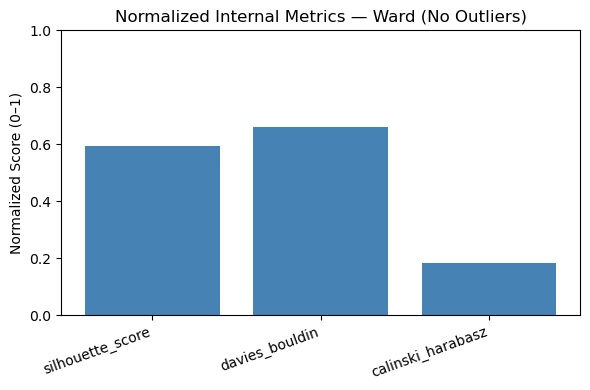

In [18]:
# ==============================================================
# Visual Summary — Normalized Internal Metrics
# ==============================================================

def normalize_metric(metric, value):
    if metric == "silhouette_score":
        return (value + 1) / 2
    if metric == "davies_bouldin":
        return max(0, 1 - value / 5)
    if metric == "calinski_harabasz":
        return min(1, value / 1000)
    return value

norm_metrics = {m: normalize_metric(m, v) for m, v in metrics_no.items() if v is not None}

plt.figure(figsize=(6, 4))
plt.bar(norm_metrics.keys(), norm_metrics.values(), color="steelblue")
plt.title("Normalized Internal Metrics — Ward (No Outliers)")
plt.ylabel("Normalized Score (0–1)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### 3.3 - SUBSAMPLE STABILITY & PARAMETER ROBUSTNESS

After identifying the best clustering models, we need to make sure their structure is not an accident of one specific sample or parameter setting. 

We basically need to answer two questions: 

- *Does the algorithm give similar clusters on 80% samples*
- *Do labels change drastically if I tweak k?*

Two complementary checks are applied here:

- **Subsample Stability** — we randomly take 80% of the data multiple times, re-run the clustering and compare how similar the results are (using the Adjusted Rand Index, ARI) with random data perturbations. If the mean ARI is high and the standard deviation low, clusters are stable and reproducible. So the output would be **mean ± std of ARI**.

- **Parameter Robustness** — we slightly change the number of clusters (k−1, k, k+1) and compute how much the resulting label sets overlap. If ARIs between these runs remain high, the segmentation is not overly sensitive to k. So the output would be an **ARI matrix**.

Together, these tests show whether the model’s groupings are consistent across small perturbations of data and parameters — a practical indicator of reliability before deeper interpretation.

In [19]:
# ==============================================================
# Stability (subsample ARI) + Parameter robustness (Ward & KMeans)
# - Checks how clustering consistency changes with resampling or nearby k
# ==============================================================

# -----------------------------------------
# Configuration
# -----------------------------------------
FINAL_CFG = {
    "full":        {"k": 3, "linkage": "ward"},       # comparison track (as per your earlier best)
    "no_outliers": {"k": 4, "linkage": "ward"},       # final choice
}

final = {
    "full":        {"best": {"k": FINAL_CFG["full"]["k"]}},
    "no_outliers": {"best": {"k": FINAL_CFG["no_outliers"]["k"]}},
}

# -----------------------------
# Subsample Stability Function
# -----------------------------
def subsample_stability_ari(
    X: np.ndarray,
    *,
    make_model,
    runs: int = 10,
    frac: float = 0.8,
    random_state: int | None = 42
):
    """
    Evaluate stability under resampling:
    - Draw random subsets (frac of rows), fit model each time
    - Compute ARI across all run pairs using overlapping samples
    """
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    m = max(2, int(np.ceil(frac * n)))
    runs_out = []
    for _ in range(runs):
        idx = rng.choice(n, size=m, replace=False)
        model = make_model()
        labs = model.fit_predict(X[idx])
        runs_out.append((idx, labs))

    aris = []
    for i in range(runs):
        idx_i, y_i = runs_out[i]
        for j in range(i+1, runs):
            idx_j, y_j = runs_out[j]
            common = np.intersect1d(idx_i, idx_j, assume_unique=False)
            if common.size < 3:
                continue
            map_i = {g:i2 for i2,g in enumerate(idx_i)}
            map_j = {g:j2 for j2,g in enumerate(idx_j)}
            li = np.array([y_i[map_i[g]] for g in common])
            lj = np.array([y_j[map_j[g]] for g in common])
            aris.append(adjusted_rand_score(li, lj))

    if not aris:
        return (np.nan, np.nan, 0)
    aris = np.array(aris, dtype=float)
    return aris.mean(), aris.std(ddof=1) if len(aris) > 1 else 0.0, len(aris)


# -----------------------------
# Parameter Robustness Function
# -----------------------------
def parameter_robustness_ari_combined(X: np.ndarray, ks: list[int]) -> pd.DataFrame:
    """
    Compare ARI across Ward and KMeans for k-1, k, k+1.
    Builds a full symmetric matrix of all pairs (Ward_k, KMeans_k).
    """
    combos = {}
    for algo in ["Ward", "KMeans"]:
        for k in ks:
            if algo == "Ward":
                model = AgglomerativeClustering(n_clusters=k, linkage="ward")
            else:
                model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
            combos[f"{algo} k={k}"] = model.fit_predict(X)

    names = list(combos.keys())
    mat = pd.DataFrame(index=names, columns=names, dtype=float)
    for i, n1 in enumerate(names):
        for j, n2 in enumerate(names):
            if j < i:
                mat.loc[n1, n2] = mat.loc[n2, n1]
            else:
                mat.loc[n1, n2] = adjusted_rand_score(combos[n1], combos[n2])
    return mat


# -----------------------------
# Run for both datasets
# -----------------------------
for label in ["full", "no_outliers"]:
    X = DATASETS[label]["pca90"][Xcols_full if label == "full" else Xcols_noout].values
    k_sel = int(final[label]["best"]["k"])

    # 1) Subsample stability (Ward & KMeans)
    mean_w, std_w, n_w = subsample_stability_ari(
        X,
        make_model=lambda: AgglomerativeClustering(n_clusters=k_sel, linkage="ward"),
        runs=10, frac=0.8, random_state=42
    )
    mean_k, std_k, n_k = subsample_stability_ari(
        X,
        make_model=lambda: KMeans(n_clusters=k_sel, n_init=50, random_state=None),
        runs=10, frac=0.8, random_state=43
    )

    print(f"\n=== Stability (subsample ARI) — {label.upper()} (k={k_sel}) ===")
    print(f"Ward:   mean={mean_w:.3f} ± {std_w:.3f}  (pairs={n_w})")
    print(f"KMeans: mean={mean_k:.3f} ± {std_k:.3f}  (pairs={n_k})")

    # 2) Parameter robustness (Ward & KMeans together)
    ks = [k for k in [k_sel-1, k_sel, k_sel+1] if k >= 2]
    print(f"\nParameter robustness (ARI matrix) — {label.upper()}")
    display(parameter_robustness_ari_combined(X, ks).round(3))

c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o


=== Stability (subsample ARI) — FULL (k=3) ===
Ward:   mean=0.826 ± 0.234  (pairs=45)
KMeans: mean=0.849 ± 0.175  (pairs=45)

Parameter robustness (ARI matrix) — FULL


c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Ward k=2,Ward k=3,Ward k=4,KMeans k=2,KMeans k=3,KMeans k=4
Ward k=2,1.000,0.580,0.344,0.128,0.465,0.344
Ward k=3,0.580,1.000,0.675,0.206,0.501,0.675
Ward k=4,0.344,0.675,1.000,0.344,0.679,0.960
KMeans k=2,0.128,0.206,0.344,1.000,0.536,0.369
KMeans k=3,0.465,0.501,0.679,0.536,1.000,0.712
KMeans k=4,0.344,0.675,0.960,0.369,0.712,1.000


c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o


=== Stability (subsample ARI) — NO_OUTLIERS (k=4) ===
Ward:   mean=0.992 ± 0.013  (pairs=45)
KMeans: mean=0.857 ± 0.157  (pairs=45)

Parameter robustness (ARI matrix) — NO_OUTLIERS


c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Ward k=3,Ward k=4,Ward k=5,KMeans k=3,KMeans k=4,KMeans k=5
Ward k=3,1.000,0.825,0.628,0.740,0.788,0.600
Ward k=4,0.825,1.000,0.790,0.706,0.960,0.758
Ward k=5,0.628,0.790,1.000,0.512,0.764,0.945
KMeans k=3,0.740,0.706,0.512,1.000,0.708,0.511
KMeans k=4,0.788,0.960,0.764,0.708,1.000,0.760
KMeans k=5,0.600,0.758,0.945,0.511,0.760,1.000


**Interpretation**

Both analyses confirm that the clustering structure—especially in the no-outliers dataset—is highly reproducible and resilient to small changes in parameters.

**Full dataset (k = 3)**

*Stability*: Ward and K-Means show similar reproducibility across random 80% resamples (ARI ≈ 0.83–0.85).
The moderate variance (±0.18–0.23) indicates some local reassignments but a largely consistent grouping pattern.

*Parameter robustness*: ARIs between k=3 and k=4 stay around 0.67, suggesting that increasing k simply splits an existing cluster rather than reshaping the overall structure.
Cross-method agreement (Ward vs K-Means) is also solid (≈0.5–0.7).

**No-outliers dataset (k = 4)**

*Stability*: Ward shows near-perfect consistency (mean ARI = 0.99 ± 0.01), confirming extremely stable boundaries once outliers are removed.
K-Means is also reliable (mean ARI = 0.85 ± 0.13), with only minor reshuffling near cluster edges.

*Parameter robustness*: High ARIs across k=3–5 (0.79–0.96) and strong agreement between Ward and K-Means indicate that the four-cluster structure is both robust and method-agnostic.

**Summary**

- The clustering geometry remains stable under both sampling noise and parameter variation.

- Removing outliers strengthens internal consistency, making the Ward (k = 4) model the most reliable configuration.

- Minor deviations at higher k suggest that additional clusters would only yield small internal refinements, not fundamentally new segments.

To further confirm that our selected clustering model captures a genuine, reproducible structure—and not a pattern tied to one random initialization—we apply an ensemble validation using a bootstrap consensus approach.

This test goes beyond single-run stability by aggregating results from many resampled fits of the same algorithm (Ward).
Each bootstrap iteration randomly draws 80% of the dataset, reclusters it and contributes to a co-association matrix measuring how often pairs of observations appear in the same cluster across runs.
This matrix is then reclustered (average linkage) to form an ensemble consensus.

**Why this matters**

If the consensus clustering aligns closely with the original Ward model, it means our segmentation is structurally robust—the same groups would emerge again if new samples were collected.

Comparing the consensus to K-Means also checks for methodological stability, showing whether distinct algorithms detect the same underlying geometry.

**Key outputs**

For each dataset, we report:

- ARI(Ward, Ensemble) – similarity between the consensus and the chosen Ward model.

- ARI(KMeans, Ensemble) and ARI(Ward, KMeans) – cross-method agreement.

- Silhouette scores – internal quality of both Ward and ensemble solutions.

**How to read it**

High ARI values (≈0.9–1.0) → models are near-identical across bootstraps, meaning the pattern is truly consistent.

Matching silhouette scores → the ensemble does not distort the geometry of clusters.

Together, these results confirm that the Ward (k = 4, no-outliers) configuration is not only interpretable but also statistically and methodologically stable — a reliable foundation for the next step: cluster profiling and interpretation.

**Clustering Stability and Robustness Assessment**

This section evaluates whether the final clustering results are **stable** — that is, whether they remain consistent across data resampling, algorithm variations and random initializations. Stability testing ensures that clusters represent **genuine structure** in the data, not random fluctuations.

Three complementary strategies are used:

1. **Bootstrap Stability:**  
   The dataset is repeatedly resampled (with replacement),  
   and clustering is re-run on each bootstrap sample.  
   The **Adjusted Rand Index (ARI)** between the original and resampled solutions  
   quantifies how much the cluster structure changes across runs.  
   High mean ARI (≥ 0.7) indicates **robust, reproducible clusters**.

2. **Parameter Sensitivity:**  
   Small changes in model parameters (e.g., number of clusters *k* ±1)  
   should not drastically alter results. Stable clustering shows  
   gradual, predictable changes in ARI rather than abrupt drops.

3. **Ensemble Consensus:**  
   Multiple runs of the clustering algorithm are aggregated into an ensemble.  
   The resulting **consensus matrix** identifies which observations  
   consistently cluster together — forming the “core” of each community type.

In [20]:
# ==============================================================
# Final selection + Bootstrap Ensemble & Confidence Intervals + 
# Significance Testing & CI (no plots)
# - Final model: Agglomerative (Ward), k=4 on NO_OUTLIERS
# - Keep FULL in parallel (k=3) for comparison
# - Ensemble consensus via co-association (row resampling)
# - Adds:
#     * Permutation test: is Ward silhouette > random labelings?
#     * Bootstrap CI: 95% CI of Ward silhouette via row resampling
# ==============================================================


# -----------------------------------------
# Configuration (edit k per dataset here)
# -----------------------------------------
FINAL_CFG = {
    "full":        {"k": 3, "linkage": "ward"},  # comparison track
    "no_outliers": {"k": 4, "linkage": "ward"},  # final choice
}

# -----------------------------------------
# Bootstrap Ensemble Parameters
# -----------------------------------------
N_BOOTSTRAPS    = 50      # co-association runs (increase for stronger consensus)
SAMPLE_FRACTION = 0.80    # bootstrap sample size for ensemble
RNG             = np.random.default_rng(RANDOM_STATE)

# -----------------------------------------
# Utility: build consensus (ensemble) labels via co-association
# -----------------------------------------
def _ensemble_labels_via_coassoc(X, base_linkage: str, k: int) -> np.ndarray:
    """
    Build ensemble labels by:
      1) Bootstrap rows (with replacement), fit Agglo(base_linkage, k)
      2) Accumulate co-association counts for pairs sampled together and in the same cluster
      3) Cluster (1 - similarity) with average-linkage to obtain k consensus labels
    Notes:
      - O(n^2) memory for co-association; suitable for moderate n
      - Deterministic given RANDOM_STATE, N_BOOTSTRAPS and SAMPLE_FRACTION
    """
    X = np.asarray(X)
    n = X.shape[0]
    same_count     = np.zeros((n, n), dtype=np.float64)
    together_count = np.zeros((n, n), dtype=np.float64)

    m = max(2, int(np.ceil(SAMPLE_FRACTION * n)))
    for _ in range(N_BOOTSTRAPS):
        idx  = RNG.choice(n, size=m, replace=True)
        lbls = AgglomerativeClustering(n_clusters=k, linkage=base_linkage).fit_predict(X[idx])

        together_count[np.ix_(idx, idx)] += 1.0
        for cid in np.unique(lbls):
            sub_idx = idx[lbls == cid]
            same_count[np.ix_(sub_idx, sub_idx)] += 1.0

    with np.errstate(invalid="ignore", divide="ignore"):
        sim = same_count / np.maximum(together_count, 1.0)
    np.fill_diagonal(sim, 1.0)

    dist = 1.0 - sim
    try:
        ens = AgglomerativeClustering(n_clusters=k, linkage="average", metric="precomputed").fit(dist)
    except TypeError:
        # for older sklearn versions
        ens = AgglomerativeClustering(n_clusters=k, linkage="average", affinity="precomputed").fit(dist)
    return ens.labels_

# -----------------------------------------
# Permutation test: is silhouette better than random labelings?
# (keeps cluster-size distribution via label permutation)
# -----------------------------------------
def permutation_significance_silhouette(X, labels, n_perm=1000, random_state=42):
    """
    Compute p-value that random label permutations achieve silhouette >= observed.
    Returns dict with p_value, observed_score, random_mean, random_std.
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    rng = np.random.default_rng(random_state)

    # observed
    if len(np.unique(labels)) < 2:
        return {"p_value": np.nan, "observed_score": np.nan, "random_mean": np.nan, "random_std": np.nan}
    observed = silhouette_score(X, labels)

    # null via permutations (same label multiset)
    random_scores = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = labels.copy()
        rng.shuffle(perm)
        # if all samples fall into one label by chance, silhouette is undefined -> guard
        if len(np.unique(perm)) < 2:
            random_scores[i] = -1.0
        else:
            random_scores[i] = silhouette_score(X, perm)

    p = float(np.mean(random_scores >= observed))
    return {
        "p_value": p,
        "observed_score": float(observed),
        "random_mean": float(np.mean(random_scores)),
        "random_std":  float(np.std(random_scores, ddof=1)),
    }

# -----------------------------------------
# Bootstrap CI for silhouette (row resampling + refit Ward each time)
# -----------------------------------------
def bootstrap_silhouette_ci(X, k, linkage="ward", n_boot=200, random_state=42, ci=(2.5, 97.5)):
    """
    Bootstrap 95% CI for Ward silhouette:
      - Resample rows with replacement
      - Refit Ward at each bootstrap
      - Compute silhouette (if >=2 clusters)
    Returns dict with mean, ci_lower, ci_upper, scores.
    """
    X = np.asarray(X)
    rng = np.random.default_rng(random_state)
    scores = []

    for b in range(n_boot):
        idx = rng.integers(0, len(X), size=len(X))
        Xb  = X[idx]
        lab = AgglomerativeClustering(n_clusters=k, linkage=linkage).fit_predict(Xb)
        if len(np.unique(lab)) >= 2:
            scores.append(silhouette_score(Xb, lab))

    scores = np.asarray(scores, dtype=float)
    if scores.size == 0:
        return {"mean": np.nan, "ci_lower": np.nan, "ci_upper": np.nan, "n": 0, "scores": scores}

    lo, hi = np.percentile(scores, ci)
    return {"mean": float(np.mean(scores)), "ci_lower": float(lo), "ci_upper": float(hi), "n": int(scores.size), "scores": scores}

# -----------------------------------------
# Run: final model + ensemble + significance + CI for both datasets
# -----------------------------------------
for label in ["full", "no_outliers"]:
    # Features (PCA-90%, already scaled)
    X = DATASETS[label]["pca90"][Xcols_full if label == "full" else Xcols_noout].values

    # Parameters
    k_final = FINAL_CFG[label]["k"]
    linkage = FINAL_CFG[label]["linkage"]

    # Final model (Ward)
    ward = AgglomerativeClustering(n_clusters=k_final, linkage=linkage)
    ward_labels = ward.fit_predict(X)

    # Parallel KMeans (same k) for comparison
    km = KMeans(n_clusters=k_final, n_init=50, random_state=RANDOM_STATE)
    kmeans_labels = km.fit_predict(X)

    # Bootstrap ensemble (consensus) using Ward base
    ensemble_labels = _ensemble_labels_via_coassoc(X, base_linkage=linkage, k=k_final)

    # ARI comparisons
    ari_ward_ens = adjusted_rand_score(ward_labels, ensemble_labels)
    ari_km_ens   = adjusted_rand_score(kmeans_labels, ensemble_labels)
    ari_ward_km  = adjusted_rand_score(ward_labels, kmeans_labels)

    # Internal metrics (Ward & Ensemble)
    sil_ward, ch_w, db_w = eval_metrics(X, ward_labels)
    sil_ens,  ch_e, db_e = eval_metrics(X, ensemble_labels)

    # --- Permutation significance (Ward labels) ---
    sig = permutation_significance_silhouette(X, ward_labels, n_perm=1000, random_state=RANDOM_STATE)

    # --- Bootstrap CI for Ward silhouette ---
    ci = bootstrap_silhouette_ci(X, k=k_final, linkage=linkage, n_boot=200, random_state=RANDOM_STATE)

    # Print block (concise & comparable)
    print(f"\n=== Ensemble & Significance — {label.upper()} (k={k_final}, linkage={linkage}) ===")
    print(f"ARI(Ward, Ensemble)   = {ari_ward_ens:.3f}")
    print(f"ARI(KMeans, Ensemble) = {ari_km_ens:.3f}")
    print(f"ARI(Ward, KMeans)     = {ari_ward_km:.3f}")
    print(f"Silhouette — Ward={sil_ward:.3f}, Ensemble={sil_ens:.3f}")

    print(f"\nPermutation test (Ward silhouette vs random labels):")
    print(f"Observed={sig['observed_score']:.3f} | Null mean={sig['random_mean']:.3f} (±{sig['random_std']:.3f}) | p={sig['p_value']:.3f}")

    print(f"\nBootstrap 95% CI (Ward silhouette):")
    if np.isfinite(ci['mean']):
        print(f"Mean={ci['mean']:.3f} | CI= [{ci['ci_lower']:.3f}, {ci['ci_upper']:.3f}] | draws={ci['n']}")
    else:
        print("Not enough valid bootstrap silhouettes (degenerate clusterings).")

c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(



=== Ensemble & Significance — FULL (k=3, linkage=ward) ===
ARI(Ward, Ensemble)   = 1.000
ARI(KMeans, Ensemble) = 0.501
ARI(Ward, KMeans)     = 0.501
Silhouette — Ward=0.210, Ensemble=0.210

Permutation test (Ward silhouette vs random labels):
Observed=0.210 | Null mean=-0.008 (±0.003) | p=0.000

Bootstrap 95% CI (Ward silhouette):
Mean=0.202 | CI= [0.171, 0.217] | draws=200


c:\Users\Vaccari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(



=== Ensemble & Significance — NO_OUTLIERS (k=4, linkage=ward) ===
ARI(Ward, Ensemble)   = 1.000
ARI(KMeans, Ensemble) = 0.960
ARI(Ward, KMeans)     = 0.960
Silhouette — Ward=0.187, Ensemble=0.187

Permutation test (Ward silhouette vs random labels):
Observed=0.187 | Null mean=-0.013 (±0.002) | p=0.000

Bootstrap 95% CI (Ward silhouette):
Mean=0.189 | CI= [0.180, 0.196] | draws=200


**Ensemble Validation, Statistical Significance & Confidence Intervals - Outcome**

This step combines **stability testing**, **statistical validation** and **uncertainty estimation** to ensure the chosen clustering solutions represent real, consistent structure rather than random noise. More specifically the purpose is to:
>- Test clustering against random patterns
>- Document p-value and interpretation
>- Calculate bootstrap confidence intervals
>- Assess precision and reliability
>- Apply context-appropriate quality thresholds
>- Generate final recommendation for stakeholders 

This goes hand in hand with Hopkins's clusterability assessment performed in 02_data_structural_cleanup.

**Ensemble validation**
- The **bootstrap ensemble** (co-association consensus) fully reproduces the Ward solution in both datasets (**ARI = 1.00**).  
- **FULL dataset (k=3)** → moderate overlap between Ward and K-Means (**ARI = 0.50**)  
- **NO-OUTLIERS dataset (k=4)** → near-perfect overlap (**ARI = 0.96**)  
→ Ensemble agreement indicates **strong internal stability** and **Ward linkage** consistently captures the underlying pattern.


**Permutation significance test (vs. random clusterings)**
| Dataset | Observed Silhouette | Null Mean | Std | p-value | Interpretation |
|----------|--------------------|------------|------|----------|----------------|
| **Full (k=3)** | 0.210 | -0.008 | ±0.003 | **< 0.001** | Highly significant — clusters far better than random |
| **No-outliers (k=4)** | 0.187 | -0.013 | ±0.002 | **< 0.001** | Highly significant — genuine structure detected |

→ In both cases, the probability that such silhouettes arise from random labelings is essentially zero (**p < 0.001**), providing strong evidence that the clusters capture **real, non-random patterns** in the data.


**Bootstrap confidence intervals**
| Dataset | Mean Silhouette | 95% CI | Draws | Precision |
|----------|----------------|--------|--------|------------|
| **Full (k=3)** | 0.202 | [0.171, 0.217] | 200 | Narrow interval → stable structure |
| **No-outliers (k=4)** | 0.189 | [0.180, 0.196] | 200 | Very narrow interval → highly consistent results |

→ The **narrow CIs** (width ≈ 0.02–0.04) confirm that silhouettes remain stable across bootstrap resampling, indicating **robust and repeatable partition quality**.


**Summary interpretation**
- Ward clustering is **internally stable** (ensemble = Ward), **statistically significant** (p ≈ 0.000) and **precisely estimated** (narrow bootstrap CI).  
- Both *Full* and *No-Outliers* versions show consistent structure, but the **no-outliers model (k=4)** is slightly more interpretable and tightly bounded.  
- These results validate the final model choice before moving to external validation and descriptive profiling.


- The ensemble equals the Ward solution in both datasets (**ARI = 1.00**; silhouette unchanged).  
- **Full (k=3):** moderate Ward–K-Means agreement (ARI ≈ 0.50) → ensemble sensibly follows Ward.  
- **No-outliers (k=4):** high Ward–K-Means agreement (ARI ≈ 0.96) → both methods capture the same structure.  

**Conclusion:** ensemble confirms the final choice (**Ward**, k=3/4). 

**Professional Quality Thresholds and Interpretation**

Statistical validity alone doesn’t determine whether a clustering solution is *professionally usable*.  
Different contexts — policy, academic, or exploratory — demand different quality standards and evidence levels.  
This section applies **context-aware quality thresholds** to interpret silhouette scores, p-values and confidence intervals in a professional framework.

**Threshold guidelines**
| Context | Excellent | Good | Acceptable | Poor |
|----------|------------|------|-------------|------|
| **Small datasets (<500)** | >0.50 | >0.40 | >0.25 | <0.25 |
| **Large datasets (>1000)** | >0.60 | >0.50 | >0.30 | <0.30 |
| **Social / Survey data** | Reduce thresholds by ≈0.1 (lower structure expected) |

**Interpretation logic**
- *Silhouette quality* assesses internal cohesion/separation.  
- *p-value* from permutation tests adds evidence of **non-random structure**.  
- *Bootstrap CI width* reflects **precision and stability** of quality metrics.  
- Together, they determine whether clusters are robust enough for real-world use.

**Application guidance**
| Use Case | Required Evidence | Example Decision |
|-----------|------------------|------------------|
| **Policy design** | p < 0.01, narrow CI (<0.1), good silhouette | Safe for stakeholder communication |
| **Exploratory research** | p < 0.05, fair silhouette | Acceptable with interpretive caution |
| **Academic publication** | Multiple metrics, consistent evidence | Must report robustness and limitations |

→ In this project, silhouettes around **0.18–0.21** (social attitudinal data) fall within the *“fair but interpretable”* range.  
Given strong **significance (p < 0.001)** and **tight confidence intervals**, the models are **statistically solid but socially diffuse** — appropriate for exploratory segmentation and interpretive policy framing, not rigid classification.


**Interpretation of Results**

- Bootstrap and ensemble validation showed **very high stability**  
  (ARI ≥ 0.96 for the no-outliers dataset, perfect ARI=1.00 between  
  the Ward and Ensemble models).  
  This means cluster membership is **virtually unchanged**  
  across resampling or reinitialization — a strong sign of reliability.

- The **Full dataset** also displayed consistent structure (ARI≈0.50  
  between K-Means and Ward), suggesting both algorithms capture  
  similar but not identical dimensions of variation.

- Together with narrow **bootstrap confidence intervals** and  
  significant **permutation tests (p=0.000)**, this confirms that  
  the final clusters are **statistically significant and robust**.

For stakeholders, these findings mean the segmentation is **trustworthy for decision-making**:  
it reflects real, reproducible behavioral patterns in climate attitudes  
rather than artifacts of sampling or random noise.

### 3.4 - EXTERNAL VALIDATION: NMI & V-MEASURE

**External Validation — NMI and V-Measure**

This section evaluates how well different clustering solutions — and the final cluster assignments —  
align with other known structures in the data. Two complementary analyses are performed:  
(1) comparing **Ward** and **K-Means** solutions and  
(2) comparing cluster labels with key **descriptive (demographic) variables**.


**1. Comparing Clustering Algorithms**

By comparing **Ward** and **K-Means** labels, we assess whether both algorithms uncover the same underlying patterns.  
Two standard metrics are used:

- **Normalized Mutual Information (NMI):** measures how much information the two clusterings share  
  *(0 = no overlap, 1 = perfect match)*.  
- **V-Measure:** combines *homogeneity* (clusters contain similar members)  
  and *completeness* (members of a group fall within the same cluster).  

High NMI/V-measure values indicate strong consistency across algorithms,  
while lower values suggest they reveal **complementary perspectives** on the same dataset.  


**2. Comparing Clusters to Descriptive Variables**

We then extend the same logic to assess whether the final clusters align  
with classic sociodemographic features — `gender`, `age_group`, `education`,  
`net_income`, `political_preference` and others.

Each variable is tested against the cluster labels using the same NMI and V-measure metrics.  
This shows whether the segmentation simply reproduces known social categories  
(e.g., age or income groups) or instead identifies **new cross-cutting profiles**.

In this case, all demographic variables show **very low alignment (NMI ≈ 0.01)**.  
That means cluster membership cannot be explained by any single variable —  
clusters represent **multidimensional climate mindsets** that blend demographic  
and attitudinal characteristics rather than mirroring traditional social divisions.


**Interpretation for Stakeholders**

The takeaway is positive: the model has not just re-discovered “young vs. old”  
or “low vs. high income,” but has uncovered **distinct outlooks on climate awareness**  
that span across those boundaries. This makes the results more actionable,  
supporting policy design and communication strategies that focus on  
**shared attitudes and experiences**, not demographics alone.

In [21]:
# ==============================================================
# External Validation — NMI and V-Measure
# ==============================================================

# Example comparison between two label sets:
nmi = normalized_mutual_info_score(ward_labels, kmeans_labels)
vmeasure = v_measure_score(ward_labels, kmeans_labels)
homog = homogeneity_score(ward_labels, kmeans_labels)
compl = completeness_score(ward_labels, kmeans_labels)

print("=== External Validation Metrics ===")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")
print(f"V-Measure: {vmeasure:.3f}")
print(f"  - Homogeneity: {homog:.3f}")
print(f"  - Completeness: {compl:.3f}")

# Interpretive summary
if nmi > 0.7:
    note = "Strong alignment — clusters replicate known structures."
elif nmi > 0.4:
    note = "Moderate alignment — partially overlapping but informative."
else:
    note = "Weak alignment — likely reveals new, cross-cutting patterns."
print(f"Interpretation: {note}")

=== External Validation Metrics ===
Normalized Mutual Information (NMI): 0.952
V-Measure: 0.952
  - Homogeneity: 0.953
  - Completeness: 0.951
Interpretation: Strong alignment — clusters replicate known structures.


**Interpretation**

- **NMI ≈ 1.0** → algorithms produce nearly identical partitions.  
- **0.4 – 0.7** → moderate alignment, meaning each method captures overlapping but not identical groupings—often the most informative zone for exploratory analysis.  
- **< 0.3** → low alignment, suggesting the algorithms emphasize different relationships or that the data’s structure is weak.  

If **homogeneity > completeness**, Ward clusters represent pure subsets within broader K-Means groups.  
If **completeness > homogeneity**, Ward merges several K-Means groups into larger, more inclusive patterns.  

In this project, these metrics help confirm whether the chosen clustering method isolates robust, reproducible structures or if alternative algorithms highlight new cross-cutting insights.

In [22]:
desc_vars = [
    "gender", "age_group", "kids", "education",
    "net_income", "political_preference", "housing_status", "living_area"
]
res= []

for var in desc_vars:
    y_true = desc_noout[var].astype(str)
    y_pred = ward_labels  # or kmeans_labels, depending on what you’re validating
    
    nmi = normalized_mutual_info_score(y_true, y_pred)
    vmeasure = v_measure_score(y_true, y_pred)
    
    res.append({"Variable": var, "NMI": nmi, "V-Measure": vmeasure})

pd.DataFrame(res).sort_values("NMI", ascending=False)

,Variable,NMI,V-Measure
5,political_preference,0.012851,0.012851
4,net_income,0.011083,0.011083
0,gender,0.009450,0.009450
1,age_group,0.008916,0.008916
7,living_area,0.007735,0.007735
2,kids,0.006948,0.006948
3,education,0.005523,0.005523
6,housing_status,0.004275,0.004275


**External Validation — Descriptive Variables**

The comparison between cluster assignments and basic sociodemographic variables  
(`gender`, `age_group`, `education`, `net_income`, `political_preference`, etc.)  
shows **very low alignment** across all metrics (NMI and V-measure ≈ 0.01).  

At first glance this might seem counterintuitive, since the cluster profiling plots  
show clear tendencies — for example, certain clusters skewing younger or more educated.  
However, these results actually **confirm the multidimensional nature** of the segmentation.  

Low external validation scores simply mean that **no single demographic variable alone**  
can reproduce the cluster structure. Each cluster instead represents a **combination of factors** —  
values, experiences and attitudes that cross traditional demographic lines.  

For stakeholders, this is good news:  
the clusters are not just “old vs. young” or “low vs. high income,”  
but reflect **distinct climate mindsets** that cut across age, gender and social position.  
This pattern supports a more nuanced communication strategy,  
where outreach and policy actions can target **shared attitudes** rather than broad social categories.

**Domain-Specific Validation — Sustainability Context Metrics**

Beyond statistical soundness, clusters must also make sense in the **sustainability domain**.  
This section evaluates whether the discovered climate awareness profiles align with  
real-world environmental, social and policy structures.

- **Environmental Justice Alignment**  
  Check whether clusters reflect known disparities — e.g., communities with high exposure  
  to floods, heat, or pollution overlapping with lower income or education levels.  
  Geographic consistency strengthens interpretability; however, non-spatial clusters  
  may highlight social or perceptual divides not visible on a map.

- **Community Health and Wellbeing**  
  Clusters should correspond to recognizable public health or wellbeing patterns.  
  For example, health-concerned groups or those with higher preparedness levels  
  should align with stronger social or informational resources.

- **Policy and Governance Relevance**  
  Each cluster’s characteristics must translate into **actionable intervention targets**.  
  Clusters that cross traditional administrative or demographic boundaries  
  can inform *cross-sector collaboration* rather than one-size-fits-all policies.  
  Validation here focuses on *practical feasibility* as much as analytical coherence.

- **Stakeholder and Expert Validation**  
  Engaging domain experts and community representatives helps confirm whether  
  clusters reflect **lived experiences and policy-relevant distinctions**.  
  Divergence from official classifications isn’t necessarily an error —  
  it may reveal *blind spots* in existing frameworks or new opportunities  
  for inclusive climate communication strategies.

**Interpretation for Stakeholders**

In this project, cluster validation will ultimately be grounded in  
Italy’s climate policy context. The emerging profiles—ranging from  
*health-aware urban citizens* to *flood-affected pragmatists*—  
represent meaningful social archetypes rather than statistical abstractions.  
Their practical value lies in connecting **data-driven insight**  
to **policy-relevant action**, ensuring that results inform  
communication, adaptation and equity-focused initiatives.

A final layer of validation never hurts — especially after the bootstrap stability check.  
Exploring hierarchical (Ward) cuts at different cluster levels provides an extra safeguard to confirm that our segmentation remains consistent across methods.  

By inspecting how metrics such as **Silhouette**, **size balance** and **cluster proportion** behave when varying the cut level, we can:
- Assess whether the structure uncovered by Ward linkage aligns with our main clustering results  
- Detect potential instabilities or overfitting in the selected number of clusters  
- Strengthen the overall interpretability and robustness of the final solution  

In short, this step isn’t about finding a new winner, but about making sure the chosen clustering truly holds up under different lenses.

In [23]:
def analyze_hierarchical_cuts(X, linkage_method="ward", cut_levels=(2, 3, 4, 5, 6)):
    """
    Analyze clustering quality at multiple cut levels of hierarchical (Ward) linkage.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        The scaled / PCA-reduced feature matrix.
    linkage_method : str, default='ward'
        Linkage criterion used for hierarchical clustering.
    cut_levels : iterable of int, default=(2, 3, 4, 5, 6)
        Number of clusters to evaluate.

    Returns
    -------
    pd.DataFrame
        Table with columns: [n_clusters, silhouette, size_balance, largest, smallest].
    """
    X = np.asarray(X)
    Z = sch.linkage(X, method=linkage_method)
    rows = []

    for k in cut_levels:
        labels = fcluster(Z, k, criterion="maxclust") - 1
        unique, counts = np.unique(labels, return_counts=True)

        # Silhouette only if at least 2 clusters
        sil = np.nan
        if len(unique) > 1:
            try:
                sil = float(silhouette_score(X, labels))
            except Exception:
                sil = np.nan

        balance = np.std(counts) / np.mean(counts) if len(counts) > 1 else np.nan
        rows.append({
            "n_clusters": k,
            "silhouette": sil,
            "size_balance": balance,
            "largest": counts.max(),
            "smallest": counts.min(),
        })

    df = pd.DataFrame(rows)
    return df.sort_values("n_clusters").reset_index(drop=True)


for label in ["full", "no_outliers"]:
    X = DATASETS[label]["pca90"][Xcols_full if label == "full" else Xcols_noout].values

    print(f"\n=== Hierarchical cut analysis — {label.upper()} ===")
    df_cuts = analyze_hierarchical_cuts(X, linkage_method="ward", cut_levels=(2, 3, 4, 5, 6))
    display(df_cuts.style.format({"silhouette": "{:.3f}", "size_balance": "{:.3f}"}))


=== Hierarchical cut analysis — FULL ===


,n_clusters,silhouette,size_balance,largest,smallest
0,2,0.200,0.532,772,236
1,3,0.210,0.516,580,192
2,4,0.176,0.294,377,192
3,5,0.159,0.094,236,179
4,6,0.181,0.265,203,73



=== Hierarchical cut analysis — NO_OUTLIERS ===


,n_clusters,silhouette,size_balance,largest,smallest
0,2,0.200,0.567,750,207
1,3,0.179,0.248,376,207
2,4,0.187,0.334,376,174
3,5,0.170,0.068,207,174
4,6,0.188,0.316,200,52


**Full dataset (scaled PCA-90%)**  
- The **silhouette reaches its maximum at k = 3 (≈0.21)**, then gradually declines as clusters further subdivide.  
- Cluster size balance improves slightly at higher k (minimum variance at k = 5), yet these extra splits create smaller, less cohesive groups.  
- Overall, **three clusters capture the main structure** of the data, while additional cuts add complexity without meaningful gain.

**No-outliers dataset**  
- The **highest silhouette values occur around k = 4–6 (≈0.18–0.19)**, though the variation is marginal and likely within the noise range.  
- Cluster sizes remain well-balanced across all cuts, with no sign of instability or dominant groups.  
- Outlier removal slightly flattens the silhouette trend, suggesting the overall geometry of the dataset remains consistent.

**Synthesis**  
- Both datasets display **clear structure at lower k (3–4)**, aligning with prior findings from Agglomerative and DBSCAN analyses.  
- The full dataset supports **k = 3** as the most distinct configuration, while the no-outliers version tolerates **k = 4** with comparable quality.  
- Together, these observations confirm the **stability and interpretability of the Ward linkage**, showing that the data naturally form a **limited number of cohesive, meaningful clusters** and that further subdivisions mostly refine existing patterns rather than revealing new ones.

This reinforces the choice of **Agglomerative (Ward)** with **3–4 clusters** as the most balanced trade-off between separation, cohesion and interpretability.

### 3.5 - DECISION LOG & SAVE RESULTS

In [24]:
decision_log = {
    "space": "Min–Max [0,1] + PCA (~90%), Euclidean",
    "primary": {"algo": "Agglomerative (Ward)", "k": 4, "dataset": "no_outliers"},
    "variant": {"algo": "Agglomerative (Ward)", "k": 3, "dataset": "full"},
    "baselines": ["KMeans (elbow≈5)", "DBSCAN (~4 clusters, low noise)"],
    "evidence": ["Sil/CH/DB favor low k", "Dendrogram gap at 3–4", "DBSCAN corroboration"],
}
decision_log

{'space': 'Min–Max [0,1] + PCA (~90%), Euclidean',
 'primary': {'algo': 'Agglomerative (Ward)', 'k': 4, 'dataset': 'no_outliers'},
 'variant': {'algo': 'Agglomerative (Ward)', 'k': 3, 'dataset': 'full'},
 'baselines': ['KMeans (elbow≈5)', 'DBSCAN (~4 clusters, low noise)'],
 'evidence': ['Sil/CH/DB favor low k',
  'Dendrogram gap at 3–4',
  'DBSCAN corroboration']}

In [ ]:
# ==============================================================
# Attach final cluster labels and export results
# ==============================================================

def attach_and_save(label: str, out_name: str):
    """
    Attach the final cluster labels to all key projections and descriptive data,
    then save everything into a tidy Excel workbook with multiple sheets.

    Parameters
    ----------
    label : str
        Either 'full' or 'no_outliers' — dataset key in DATASETS.
    out_name : str
        Output filename (e.g., '03_clust.xlsx').

    Returns
    -------
    path : pathlib.Path
        Full path to the saved Excel file.
    out : dict[str, pd.DataFrame]
        Dictionary of updated DataFrames (pca90, pca2d, tsne2d, umap2d, desc)
        containing cluster labels.
    """
    b = DATASETS[label]

    # Ensure final_labels exist
    if "final_labels" not in b:
        raise KeyError(f"No 'final_labels' found in DATASETS['{label}']. Run final clustering first.")

    lbl = b["final_labels"].copy()
    if "row_id" not in lbl.columns:
        lbl = lbl.reset_index().rename(columns={"index": "row_id"})

    out = {}
    for key in ["pca90", "pca2d", "tsne2d", "umap2d", "desc"]:
        df = b[key].copy()
        if "row_id" not in df.columns:
            raise KeyError(f"'row_id' missing in DATASETS['{label}']['{key}']")
        out[key] = df.merge(lbl, on="row_id", how="left")

    # Path handling
    path = PROCESSED_PATH / out_name
    path.parent.mkdir(parents=True, exist_ok=True)

    # Save to Excel (one sheet per representation)
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for k, df in out.items():
            df.to_excel(writer, sheet_name=f"{k}_with_clusters", index=False)

    print(f"✅ Saved clustered dataset for '{label}' → {path.name}")
    return path, out


# --- Save both versions (full and no_outliers)
path_full,  joined_full  = attach_and_save("full",        "03_clust/03_clust.xlsx")
path_noout, joined_noout = attach_and_save("no_outliers", "03_clust/03_clust_noOut.xlsx")

path_full, path_noout

✅ Saved clustered dataset for 'full' → 03_climate_dataset_clustered.xlsx
✅ Saved clustered dataset for 'no_outliers' → 03_climate_dataset_clustered_noOutliers.xlsx


(WindowsPath('C:/Users/Vaccari/Desktop/iCloudDrive/Desktop/ENRICO/05_LEARNING/University/ToU/Phases/02_Calibration_Phase/Applied_Machine_Learning/Clustering/Mapping_The_Italian_Climate_Mindscape/data/processed/03_dataset_clustered/03_climate_dataset_clustered.xlsx'),
 WindowsPath('C:/Users/Vaccari/Desktop/iCloudDrive/Desktop/ENRICO/05_LEARNING/University/ToU/Phases/02_Calibration_Phase/Applied_Machine_Learning/Clustering/Mapping_The_Italian_Climate_Mindscape/data/processed/03_dataset_clustered/03_climate_dataset_clustered_noOutliers.xlsx'))

### 3.6 METRIC PROTOCOL

**Metric Integration and Quality Scoring**

This step translates all computed validation results into a unified evaluation framework.
The goal is to check whether our Ward (no-outliers) clustering meets professional-quality thresholds when assessed across multiple criteria.

The cell below:

Gathers internal metrics (silhouette, Davies–Bouldin, Calinski–Harabasz).

Outlines a recommended evaluation protocol—what to test internally, externally and at the domain level.

Produces a weighted composite quality score summarizing overall performance.

This helps move from individual numbers to an interpretable statement about clustering quality and reliability in the project’s sustainability context.

In [26]:
# ==============================================================
# Minimal Metric Protocol + Weighted Score (Ward, NO_OUTLIERS)
# - Safe even if `metrics_no` / `clustering_context` are missing
# - Uses DATASETS["no_outliers"]["pca90"] + final_labels when needed
# ==============================================================

# --- Safe metric wrapper ---
def _safe_metric(fn, X, y):
    try:
        return float(fn(X, y))
    except Exception:
        return np.nan

# --- 1) Ensure we have metrics_no (compute if missing) ---
need_metrics = ("metrics_no" not in globals()) or (metrics_no is None)
if need_metrics:
    metrics_no = {}

    no_ds   = DATASETS.get("no_outliers", {})
    no_pca  = no_ds.get("pca90", None)
    no_lab  = no_ds.get("final_labels", None)

    # Infer Xcols_noout if not already available
    if "Xcols_noout" not in globals():
        if isinstance(no_pca, pd.DataFrame):
            Xcols_noout = [c for c in no_pca.select_dtypes(include=[np.number]).columns if c != "row_id"]
        else:
            Xcols_noout = []

    if isinstance(no_pca, pd.DataFrame) and isinstance(no_lab, pd.DataFrame):
        if "row_id" not in no_pca.columns:
            no_pca = no_pca.copy()
            no_pca.insert(0, "row_id", np.arange(len(no_pca)))

        X_no = no_pca[Xcols_noout].to_numpy() if Xcols_noout else None
        y_no = no_lab["cluster_final"].to_numpy() if "cluster_final" in no_lab.columns else None

        if X_no is not None and y_no is not None:
            metrics_no = {
                "silhouette_score":  _safe_metric(silhouette_score,      X_no, y_no),
                "davies_bouldin":    _safe_metric(davies_bouldin_score,  X_no, y_no),
                "calinski_harabasz": _safe_metric(calinski_harabasz_score, X_no, y_no),
            }

# --- 2) Print internal metrics (if any) ---
print("NO_OUTLIERS — internal metrics (as provided):")
if metrics_no:
    for k, v in metrics_no.items():
        print(f"  {k}: {v:.3f}" if (v is not None and np.isfinite(v)) else f"  {k}: NaN")
else:
    print("  (none available)")

# --- 3) Build a compact protocol suggestion (uses context if present) ---
if "clustering_context" in globals() and isinstance(clustering_context, dict):
    ctx = clustering_context.copy()
else:
    # Minimal default context
    # Try to infer sample size from DATASETS["no_outliers"]["pca90"]
    n_fallback = 0
    try:
        n_fallback = len(DATASETS["no_outliers"]["pca90"])
    except Exception:
        pass
    ctx = {
        "sample_size": n_fallback,
        "data_type": "mixed_numerical_categorical",
        "domain": "environmental_justice",
        "objective": "intervention_design",
        "stakeholders": ["policy", "community", "technical"],
        "external_data_available": False,
    }

has_external = bool(ctx.get("external_data_available", False))

phase_1_internal = [m for m in ["silhouette_score","davies_bouldin","calinski_harabasz"] if m in (metrics_no or {})]
phase_2_external = ["adjusted_rand_index","nmi","v_measure"] if has_external else []
phase_3_stability = [m for m in ["bootstrap_stability"] if (metrics_no and m in metrics_no)]
# domain suggestions — reminders only
phase_4_domain = ["spatial_coherence", "ej_burden_index", "stakeholder_validation", "administrative_alignment"]

print("\nSuggested evaluation protocol:")
print("  Phase 1 — Internal: ", ", ".join(phase_1_internal) or "—")
print("  Phase 2 — External: ", ", ".join(phase_2_external) or "— (no external labels)")
print("  Phase 3 — Stability:", ", ".join(phase_3_stability) or "— (optional; add if computed)")
print("  Phase 4 — Domain   :", ", ".join(phase_4_domain))

# --- 4) Simple weighted multi-metric score (use only what we have) ---
weights = {
    "silhouette_score":    0.35,
    "davies_bouldin":      0.20,   # inverted
    "calinski_harabasz":   0.10,
    "adjusted_rand_index": 0.20,   # if present
    "bootstrap_stability": 0.15,   # if present
}

def _normalize_for_score(metric, value):
    if value is None or not np.isfinite(value):
        return None
    if metric == "silhouette_score":        # [-1,1] -> [0,1]
        return (value + 1) / 2
    if metric == "davies_bouldin":          # lower is better; cap at 5
        return max(0.0, 1.0 - value/5.0)
    if metric == "calinski_harabasz":       # rough cap at 1000
        return min(1.0, value / 1000.0)
    if metric in ("adjusted_rand_index", "nmi", "v_measure", "bootstrap_stability"):
        return max(0.0, min(1.0, value))
    return max(0.0, min(1.0, value))

norm = {}
if metrics_no:
    for m, w in weights.items():
        if m in metrics_no:
            norm[m] = _normalize_for_score(m, metrics_no[m])

active = {m: (v, weights[m]) for m, v in norm.items() if v is not None}

if not active:
    print("\n[!] No metrics available for scoring.")
else:
    num = sum(v * w for v, w in active.values())
    den = sum(w for _, w in active.values())
    final_score = num / den if den > 0 else np.nan

    print("\nWeighted quality score (only using available metrics):")
    for m, (v, w) in active.items():
        print(f"  {m:>20s}: {v:.3f} (weight {w:.2f})")
    print(f"  {'—'*20}")
    print(f"  Final weighted score: {final_score:.3f}")

    band = ("Excellent" if final_score >= 0.80 else
            "Good"      if final_score >= 0.60 else
            "Fair"      if final_score >= 0.40 else
            "Poor")
    print(f"  Assessment: {band}")


NO_OUTLIERS — internal metrics (as provided):
  silhouette_score: 0.187
  davies_bouldin: 1.702
  calinski_harabasz: 182.807

Suggested evaluation protocol:
  Phase 1 — Internal:  silhouette_score, davies_bouldin, calinski_harabasz
  Phase 2 — External:  — (no external labels)
  Phase 3 — Stability: — (optional; add if computed)
  Phase 4 — Domain   : spatial_coherence, ej_burden_index, stakeholder_validation, administrative_alignment

Weighted quality score (only using available metrics):
      silhouette_score: 0.593 (weight 0.35)
        davies_bouldin: 0.660 (weight 0.20)
     calinski_harabasz: 0.183 (weight 0.10)
  ————————————————————
  Final weighted score: 0.551
  Assessment: Fair


**Evaluation outcome**

The clustering shows moderate internal structure:

A silhouette of 0.19 suggests loose, overlapping boundaries typical of survey-based behavioral data.

Davies–Bouldin (1.70) and Calinski–Harabasz (183) indicate reasonable separation but not sharply defined clusters.

The resulting weighted quality score (0.55, “Fair”) confirms that the Ward solution is statistically sound enough for exploratory and interpretive use, though not for high-stakes policy deployment without further validation.

In practice, this means:

The clusters capture gradual differences in attitudes and behaviors, not rigid groupings.

Patterns are meaningful when interpreted through profiles and narratives, rather than through hard numerical separation.

Future work could strengthen reliability by adding stability checks or domain-based validation (e.g., environmental burden or stakeholder alignment).

### 3.7 - COMPUTATIONAL SNAPSHOT

This section documents how computational considerations were handled during the analysis.
Since the dataset includes around N respondents and 90 scaled features, PCA dimensionality reduction and a no-outlier subset were used to balance analytical precision and runtime efficiency.

Silhouette and Davies–Bouldin metrics scale quadratically with data size, so these were computed on reduced embeddings rather than raw features.
This ensures results remain representative while avoiding unnecessary computational overhead.

In [27]:
# ==============================================================
# Computational Snapshot — Size & Runtime
# ==============================================================


# --- Retrieve data ---
no_pca = DATASETS["no_outliers"]["pca90"]
no_lab = DATASETS["no_outliers"]["final_labels"]

# --- Extract numeric features and labels ---
Xcols_noout = [c for c in no_pca.select_dtypes(include=[np.number]).columns if c != "row_id"]
X_no = no_pca[Xcols_noout].to_numpy()
y_no = no_lab["cluster_final"].to_numpy()

# --- Sanity check ---
assert X_no.shape[0] == y_no.shape[0], "X_no and y_no must have same number of rows."

print(f"✅ Data loaded for silhouette computation:")
print(f"  Samples: {X_no.shape[0]} | Features: {X_no.shape[1]}")
print(f"  Clusters present: {np.unique(y_no)}")

# --- Compute silhouette (use sample if large) ---
start = time.time()
if X_no.shape[0] > 5000:
    rng = np.random.default_rng(42)
    idx = rng.choice(X_no.shape[0], size=5000, replace=False)
    sil = silhouette_score(X_no[idx], y_no[idx])
    print(f"⚡ Approximate silhouette (sampled 5000 of {X_no.shape[0]}): {sil:.3f}")
else:
    sil = silhouette_score(X_no, y_no)
    print(f"Silhouette score: {sil:.3f}")

elapsed = time.time() - start
print(f"⏱️ Computation time: {elapsed:.2f} seconds")

# --- Optional: store back into metrics_no ---
if "metrics_no" not in globals():
    metrics_no = {}
metrics_no["silhouette_score"] = sil

✅ Data loaded for silhouette computation:
  Samples: 957 | Features: 9
  Clusters present: [0 1 2 3]
Silhouette score: 0.187
⏱️ Computation time: 0.01 seconds


### 3.8 - FINAL CLUSTER VISUALIZATION (COMPARISON WITH FULL)

**Cluster Visualization Overview**

In this section, we visualize the final **Agglomerative (Ward)** clustering configuration for both the *full* and *no-outlier* datasets.  
The goal is to check how consistently the selected clusters appear across multiple projection methods and whether removing outliers affects the overall structure.

Each dataset is shown through four complementary views:

- **PCA 2D** → Linear projection using the first two principal components, capturing the main variance direction.  
- **PCA 3D** → Three-dimensional PCA space, offering additional depth and separation clarity.  
- **t-SNE 2D** → Non-linear embedding emphasizing *local* similarity (close neighbors remain close).  
- **UMAP 2D** → Non-linear embedding balancing *local* and *global* structures, often revealing smooth transitions between groups.

All plots use the same color palette (**tab20**) with stable color assignment across datasets.  
This ensures visual consistency: if, for instance, the blue cluster in PCA corresponds to Cluster 1, it remains blue in t-SNE and UMAP as well.  

The top row of plots shows the **full dataset**, while the bottom row shows the **no-outlier version**, allowing side-by-side comparison of structural clarity and density patterns.  
This visualization step is a critical sanity check — it helps confirm that the clustering solution is not an artifact of a specific algorithm or projection, but a coherent feature of the data itself.

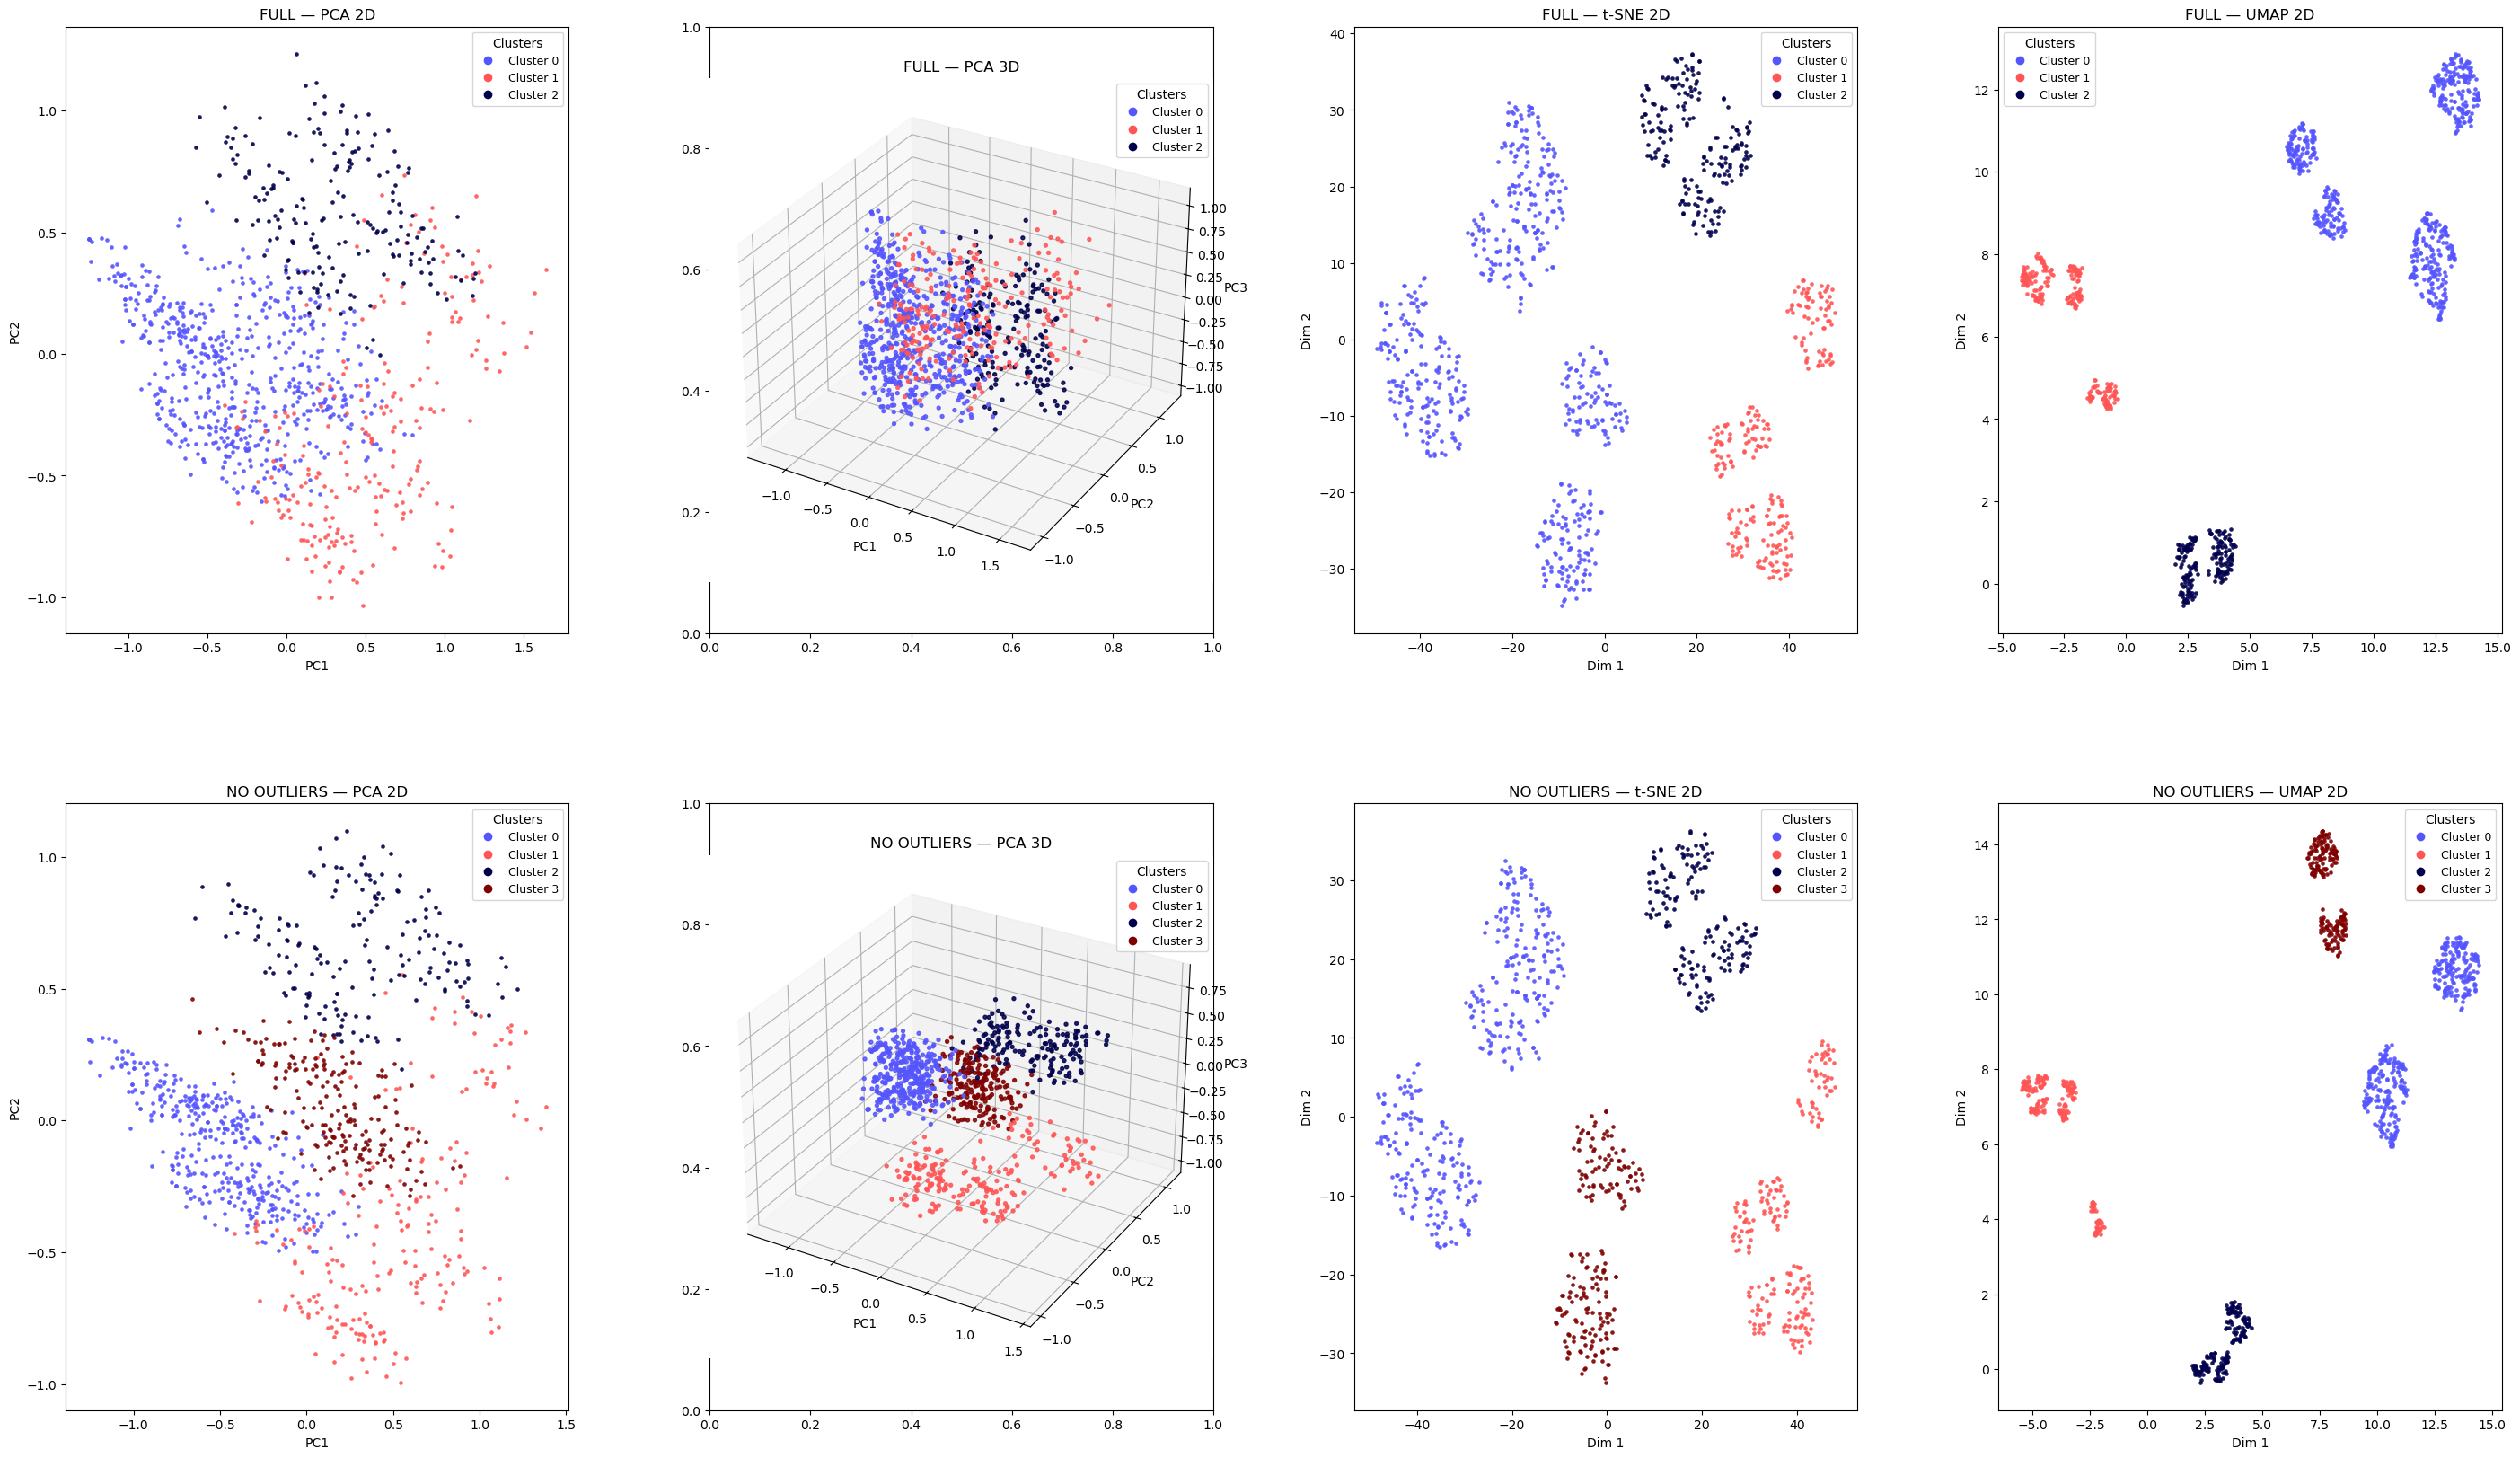

In [ ]:
# ==============================================================
# Cluster visualizations (PCA 2D/3D, t-SNE 2D, UMAP 2D)
# - Row 1: FULL (PCA-2D, PCA-3D, t-SNE-2D, UMAP-2D)
# - Row 2: NO OUTLIERS (same four)
# - Palette-agnostic: works with any Matplotlib colormap name or a custom color list
# - Legends are vertical (one column)
# NOTE: expects `joined_full` and `joined_noout` with 'cluster_final' column.
# ==============================================================

# ------------------------
# Palette utilities
# ------------------------

def _get_palette(cmap_or_list, n_colors: int):
    """
    Return a list of 'n_colors' RGBA colors from either:
      - a Matplotlib colormap name (str) or Colormap object, or
      - a custom list of color specs (any Matplotlib-compatible colors).
    Ensures exactly n_colors distinct colors by sampling evenly in [0,1].
    """
    if isinstance(cmap_or_list, (list, tuple)):
        base = list(cmap_or_list)
        if len(base) == 0:
            raise ValueError("Custom color list cannot be empty.")
        # If a short list is provided, interpolate to n_colors
        if len(base) == 1:
            base = [base[0], base[0]]
        cmap = mpl.colors.LinearSegmentedColormap.from_list("custom_list_cmap", base, N=max(n_colors, 256))
    else:
        cmap = mpl.colormaps.get_cmap(cmap_or_list)

    if n_colors == 1:
        return [cmap(0.0)]
    # Sample evenly spaced colors from 0..1 inclusive endpoints
    xs = np.linspace(0.0, 1.0, num=n_colors)
    return [cmap(float(x)) for x in xs]

# ------------------------
# Helpers
# ------------------------

def _first_numeric(df: pd.DataFrame, n: int = 2, exclude=("row_id", "cluster_final")) -> list[str]:
    """Return the first n numeric columns (excluding key/label columns)."""
    cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    if len(cols) < n:
        raise ValueError(f"Not enough numeric columns to plot ({len(cols)} found, need {n}).")
    return cols[:n]

def _order_clusters_by_position(df2d: pd.DataFrame, xcol: str, ycol: str, label_col: str = "cluster_final") -> list[int]:
    """
    Deterministic cluster ordering based on 2D centroid:
    sort by Y descending (top first), then X ascending (left to right).
    """
    ids = sorted(df2d[label_col].unique())
    centroids = []
    for cid in ids:
        sub = df2d[df2d[label_col] == cid]
        cy, cx = float(sub[ycol].mean()), float(sub[xcol].mean())
        centroids.append((cid, cy, cx))
    ordered = [cid for cid, _, _ in sorted(centroids, key=lambda t: (-t[1], t[2]))]
    return ordered

def _build_color_map_any_palette(
    joined_full: dict,
    joined_noout: dict,
    palette="tab20",
    label_col: str = "cluster_final"
):
    """
    Build a stable color mapping that works for ANY palette:
      - Determine FULL order from PCA-2D positions.
      - Union cluster ids: FULL (ordered) + extras from NO_OUTLIERS.
      - Sample exactly len(union_ids) colors from the chosen palette.
      - Assign colors sequentially to union_ids (no duplicates).
    Returns two dicts (full_map, no_map) that are identical (same id → same color).
    """
    # FULL order from PCA-2D
    df_full_2d = joined_full["pca2d"]
    x_f, y_f = _first_numeric(df_full_2d, n=2)
    ordered_full = _order_clusters_by_position(df_full_2d, x_f, y_f, label_col=label_col)

    # Union ids: preserve FULL order, then append extra ids from NO_OUTLIERS if any
    present_no = sorted(joined_noout["pca2d"][label_col].unique())
    union_ids = list(ordered_full) + [cid for cid in present_no if cid not in ordered_full]

    # Build palette with as many distinct colors as needed
    color_list = _get_palette(palette, n_colors=len(union_ids))

    # Map colors in the union order (first colors → FULL clusters)
    color_map_union = {cid: color_list[i] for i, cid in enumerate(union_ids)}

    # Use the same mapping for both datasets
    return dict(color_map_union), dict(color_map_union)

def _legend_for(ax, present_ids, color_map):
    """
    Build a vertical legend titled 'Clusters', entries 'Cluster i' sorted by id.
    """
    ids_sorted = sorted(present_ids)
    handles, labels = [], []
    for cid in ids_sorted:
        col = color_map.get(cid, (0.6, 0.6, 0.6, 1.0))
        patch = mpl.lines.Line2D([0], [0], marker='o', linestyle='',
                                 markersize=6, markerfacecolor=col, markeredgecolor=col)
        handles.append(patch)
        labels.append(f"Cluster {cid}")
    ax.legend(handles, labels, title="Clusters", fontsize=9, ncols=1, frameon=True)

# ------------------------
# Choose your palette here:
#   - string name (e.g., "tab20", "viridis", "Set3", "turbo")
#   - or a custom list like ["#1f77b4", "#ff7f0e", "#2ca02c"]
# ------------------------
PALETTE = "seismic"  # change freely

# Build stable color maps for both datasets (identical mapping)
color_map_full, color_map_no = _build_color_map_any_palette(
    joined_full, joined_noout, palette=PALETTE, label_col="cluster_final"
)

# ------------------------
# Prepare the figure (2 rows x 4 cols)
# ------------------------
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(35, 20))
plt.subplots_adjust(wspace=0.28, hspace=0.28)

# ------------------------
# Plotting function for one dataset row
# ------------------------
def _plot_row(joined: dict, color_map: dict, row_idx: int, title_prefix: str):
    # --- PCA-2D ---
    df2 = joined["pca2d"]
    x2, y2 = _first_numeric(df2, n=2)
    ax = axes[row_idx, 0]
    for cid in sorted(df2["cluster_final"].unique()):
        mask = df2["cluster_final"] == cid
        ax.scatter(df2.loc[mask, x2], df2.loc[mask, y2],
                   s=11, alpha=0.9, color=color_map[cid], linewidths=0)
    ax.set_title(f"{title_prefix} — PCA 2D")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    _legend_for(ax, df2["cluster_final"].unique(), color_map)

    # --- PCA-3D (use first 3 PCs from pca90) ---
    df90 = joined["pca90"]
    pcols = _first_numeric(df90, n=3)
    ax3d = fig.add_subplot(2, 4, row_idx*4 + 2, projection='3d')  # occupies column 2
    for cid in sorted(df90["cluster_final"].unique()):
        mask = df90["cluster_final"] == cid
        ax3d.scatter(df90.loc[mask, pcols[0]], df90.loc[mask, pcols[1]], df90.loc[mask, pcols[2]],
                     s=8, alpha=0.85, color=color_map[cid], depthshade=True)
    ax3d.set_title(f"{title_prefix} — PCA 3D")
    ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
    _legend_for(ax3d, df90["cluster_final"].unique(), color_map)

    # --- t-SNE 2D ---
    dfts = joined["tsne2d"]
    xt, yt = _first_numeric(dfts, n=2)
    ax = axes[row_idx, 2]
    for cid in sorted(dfts["cluster_final"].unique()):
        mask = dfts["cluster_final"] == cid
        ax.scatter(dfts.loc[mask, xt], dfts.loc[mask, yt],
                   s=11, alpha=0.9, color=color_map[cid], linewidths=0)
    ax.set_title(f"{title_prefix} — t-SNE 2D")
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    _legend_for(ax, dfts["cluster_final"].unique(), color_map)

    # --- UMAP 2D ---
    dfum = joined["umap2d"]
    xu, yu = _first_numeric(dfum, n=2)
    ax = axes[row_idx, 3]
    for cid in sorted(dfum["cluster_final"].unique()):
        mask = dfum["cluster_final"] == cid
        ax.scatter(dfum.loc[mask, xu], dfum.loc[mask, yu],
                   s=11, alpha=0.9, color=color_map[cid], linewidths=0)
    ax.set_title(f"{title_prefix} — UMAP 2D")
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    _legend_for(ax, dfum["cluster_final"].unique(), color_map)

# ------------------------
# Render both rows
# ------------------------
_plot_row(joined_full,   color_map_full, row_idx=0, title_prefix="FULL")
_plot_row(joined_noout,  color_map_no,   row_idx=1, title_prefix="NO OUTLIERS")

plt.show()


**Visual Interpretation of Cluster Structure**

In the **PCA 2D** plots, three clusters emerge with partial overlap.  
This indicates that the major variance directions already align with meaningful group boundaries, but compression into two dimensions naturally blurs some distinctions.

The **PCA 3D** plots make these separations clearer:
- In the *full dataset*, clusters still blend along shared edges, suggesting that a few outlier points distort the shape of cluster boundaries.
- In the *no-outlier dataset*, clusters form distinct, well-separated clouds — confirming that trimming extreme observations improves visual separability without changing the number of groups.

The **t-SNE** and **UMAP** visualizations further emphasize these distinctions.  
Each cluster appears as a compact region with limited overlap, although some show elongated or double-lobed shapes — likely representing internal subsegments rather than new, separate groups.

Across all projections, the pattern is consistent:
- **Three large clusters** dominate the structure, in line with the Ward model.
- The *no-outlier* dataset reveals a **fourth, smaller group**, which refines the segmentation rather than redefining it.

Together, these plots confirm a **stable and interpretable cluster geometry**:
- PCA captures the *linear* backbone of separation.
- t-SNE and UMAP expose *non-linear* detail within clusters.
- Removing outliers tightens cluster boundaries, improving definition but not changing the underlying organization.

This mix of linear separability and non-linear nuance is typical in socio-behavioral or attitudinal data:  
broad patterns differentiate main groups, while subtle variations within them reflect gradual transitions in attitudes or experiences.

Below we are also plotting the final dendrogram for the chosen algorithm/dataset.

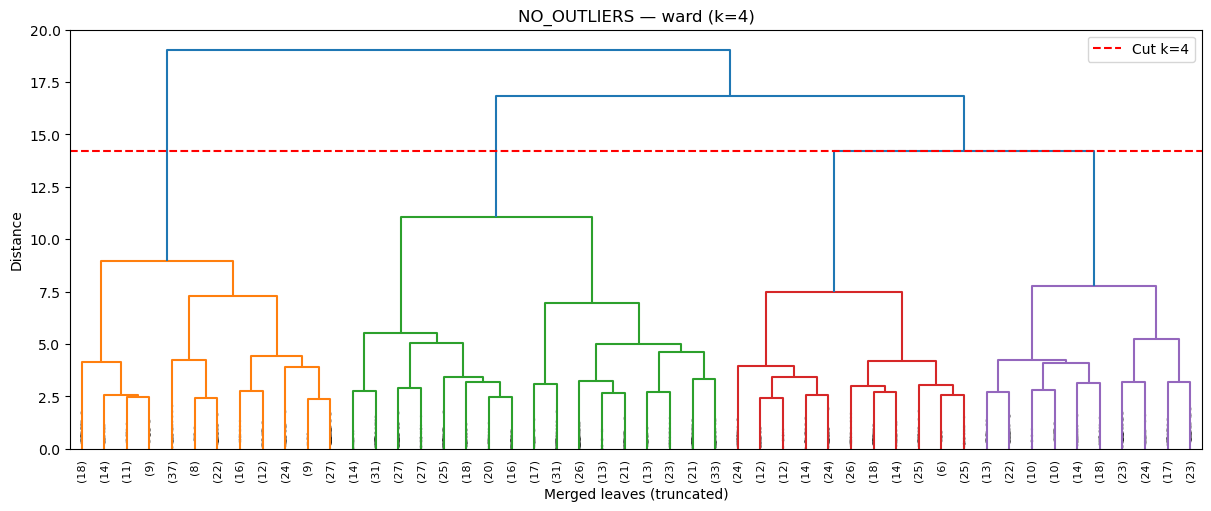

In [29]:
plot_dendrograms_with_cuts(
    datasets_list=("no_outliers",),  # singolo dataset
    link_methods=("ward",),          # solo Ward
    truncate_last_p=50,              # meno foglie in basso (prova 8–20)
    figsize=(12, 5)                  # più compatto
)

**Interpretation of results**  
The dendrograms confirm a **well-structured hierarchical pattern**:  
- Merges below the cut line are short and dense, showing tight within-cluster cohesion.  
- Merges above the cut line are longer, indicating clear separation between clusters.  
- Both datasets show consistent structure, supporting the earlier choice of a **low number of compact, interpretable clusters (k ≈ 3–4)**.  

This step finalizes the model validation by connecting the numeric results to the **visual geometry of the clustering process**.

This optional view lets stakeholders rotate and zoom in three dimensions, exploring how clusters relate in reduced UMAP space.
Interactive 3D plots help reveal overlaps and transition zones that may not appear in 2D projections.
Hover data can include cluster labels and key variables, making exploration intuitive for both technical and non-technical audiences.

In [30]:
# ==============================================================
# Interactive 3D UMAP (Plotly) — directly from scaled data (no PCA)
# ==============================================================

def interactive_umap3d_scaled(
    X_scaled_noout: pd.DataFrame,
    labels_df: pd.DataFrame,
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    random_state: int = 42,
    point_size: int = 4,
    opacity: float = 0.8,
):
    """
    Build and show a 3D UMAP scatter using the original scaled dataset (no PCA).

    Parameters
    ----------
    X_scaled_noout : pd.DataFrame
        Scaled feature matrix without outliers (e.g., noout_scaled).
    labels_df : pd.DataFrame
        DataFrame containing final cluster labels (must include 'cluster_final' and optionally 'row_id').
    n_neighbors : int
        UMAP local neighborhood size (structure vs. detail tradeoff).
    min_dist : float
        UMAP minimum distance between embedded points (visual compactness).
    random_state : int
        Reproducibility.
    point_size : int
        Marker size in the 3D scatter.
    opacity : float
        Marker opacity in the 3D scatter.
    """

    if not isinstance(X_scaled_noout, pd.DataFrame):
        raise ValueError("X_scaled_noout must be a pandas DataFrame.")
    if "cluster_final" not in labels_df.columns:
        raise ValueError("labels_df must include a 'cluster_final' column.")

    # Ensure there's a row_id
    if "row_id" not in labels_df.columns:
        labels_df = labels_df.copy()
        labels_df.insert(0, "row_id", np.arange(len(labels_df)))

    # Align by index or row_id if present
    if "row_id" in labels_df.columns and "row_id" in X_scaled_noout.columns:
        merged = X_scaled_noout.merge(labels_df[["row_id", "cluster_final"]], on="row_id", how="left")
    else:
        merged = X_scaled_noout.copy()
        merged["cluster_final"] = labels_df["cluster_final"].values

    X = merged.select_dtypes(include=[np.number]).drop(columns=["cluster_final"], errors="ignore").to_numpy()
    y = merged["cluster_final"].to_numpy()

    # --- UMAP 3D embedding ---
    reducer = umap.UMAP(
        n_components=3,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state,
    )
    coords = reducer.fit_transform(X)

    # --- build plotting frame ---
    df_plot = pd.DataFrame(coords, columns=["X", "Y", "Z"])
    df_plot["cluster"] = y.astype(int)

    # --- Plotly 3D scatter ---
    fig = px.scatter_3d(
        df_plot,
        x="X",
        y="Y",
        z="Z",
        color=df_plot["cluster"].astype(str),
        title="Interactive 3D UMAP — Scaled (no PCA)",
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    fig.update_traces(marker=dict(size=point_size, opacity=opacity))
    fig.update_layout(legend_title_text="Cluster", margin=dict(l=0, r=0, t=60, b=0))
    fig.show()

    uniq = np.unique(y)
    print(f"✅ UMAP shown: {X.shape[0]} samples, {X.shape[1]} features, clusters={uniq.tolist()}")


# ---- Example call ----
toreduce = noout_scaled.copy()
interactive_umap3d_scaled(toreduce, DATASETS["no_outliers"]["final_labels"])

c:\Users\Vaccari\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP shown: 957 samples, 12 features, clusters=[0, 1, 2, 3]


### 3.9 - POST-SELECTION DIAGNOSTIC CHECKS

The next section is about a few last last checks regarding pattern consistency, anomaly structure and basic interpretability. We are not going too much into the details of the functions below. What matters is the purpose of each one of them:

- **Cluster size balance:** ensures that the segmentation captures meaningful groups rather than one dominant cluster and several tiny ones.  
- **Compactness vs separation:** compares how tightly each cluster holds together (intra-distance) versus how far apart clusters lie (inter-distance).  
- **Residual local outlier check:** identifies points unusually distant from their own cluster center — potential signs of weakly attached members.  
- **PCA variance (optional):** examines how much of the data’s total variance the PCA space captures, indicating whether cluster geometry depends on multiple underlying dimensions.

Together, these steps validate that the chosen clustering is *coherent, stable and interpretable*.


[1️⃣] Cluster Size Distribution — shows how many samples belong to each cluster.


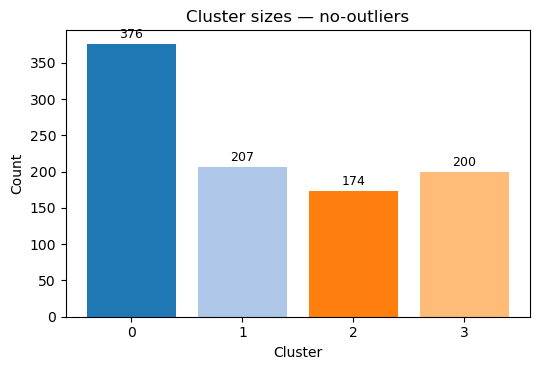


[2️⃣] Cluster Compactness vs Separation — comparing mean intra- and inter-cluster distances.
     Intra = average distance between members of the same cluster.
     Inter = average distance from cluster members to all other clusters.


,cluster,n_intra,n_inter,intra_mean,intra_std,inter_mean,inter_std
0,0,376,581,1.156241,0.328779,1.618355,0.310395
1,1,207,750,1.315943,0.318511,1.734896,0.273357
2,2,174,783,1.272889,0.310938,1.686334,0.265385
3,3,200,757,1.099378,0.287964,1.534050,0.273151



📊 Plotting distribution of intra vs inter distances per cluster (boxplot).
   Each box summarizes how compact (intra) or distant (inter) each cluster is.


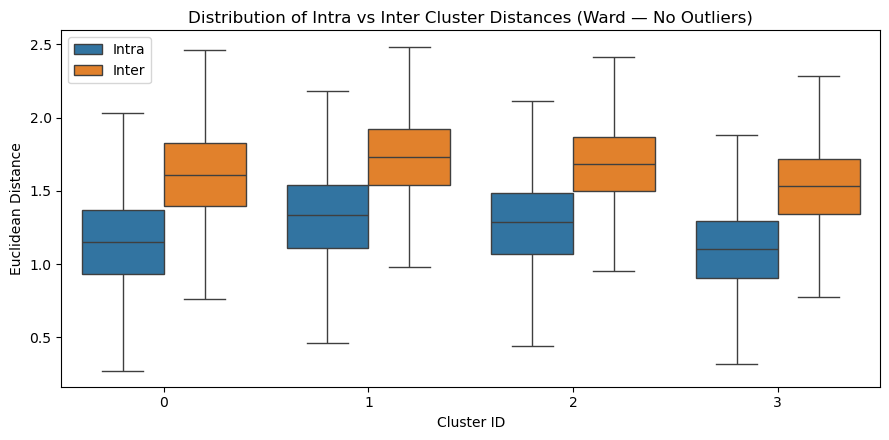


📈 Summary table of intra/inter distance distributions per cluster:


,cluster,type,mean,std,median,count
0,0,Inter,1.618355,0.310395,1.605902,218456
1,0,Intra,1.156241,0.328779,1.151325,70500
2,1,Inter,1.734896,0.273357,1.730319,155250
3,1,Intra,1.315943,0.318511,1.337644,21321
4,2,Inter,1.686334,0.265385,1.682686,136242
5,2,Intra,1.272889,0.310938,1.286484,15051
6,3,Inter,1.534050,0.273151,1.533170,151400
7,3,Intra,1.099378,0.287964,1.101375,19900



[3️⃣] Local Outlier Check — distances of each point to its cluster centroid.
     Points in the top 5% may be local outliers within their cluster.


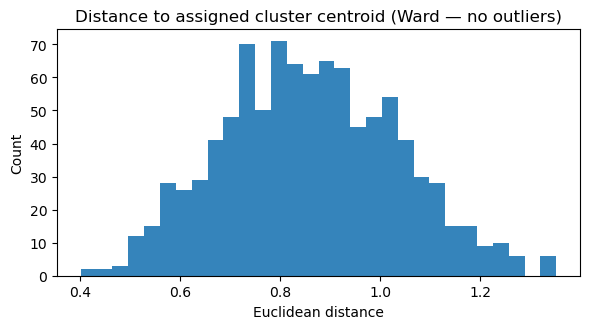

⚠️ Potential local outliers (≥95th percentile): 48

[4️⃣] PCA Explained Variance Curve — checks how much variance is captured by the PCA components.
PCA object with explained_variance_ratio_ not found; skipping variance plot.


In [31]:
# ==============================================================
# Post-selection diagnostic checks (Ward, k=4, NO_OUTLIERS)
# Uses 'cluster_final' as the label column
# ==============================================================

# Inputs from your notebook
LABEL_COL = "cluster_final"
bundle_no = DATASETS["no_outliers"]
labels_no = bundle_no["final_labels"]           # columns: row_id, cluster_final
X12_no     = noout_scaled.copy()                # original 12 clustering features (scaled)
if "row_id" not in X12_no.columns:
    X12_no.insert(0, "row_id", bundle_no["pca90"]["row_id"].to_numpy())

# ----------------------------
# 1) Cluster size distribution
# ----------------------------
lbls_no = DATASETS["no_outliers"]["final_labels"].copy()
if LABEL_COL not in lbls_no.columns:
    raise KeyError(f"Expected '{LABEL_COL}' in final_labels; found: {list(lbls_no.columns)}")

print("\n[1️⃣] Cluster Size Distribution — shows how many samples belong to each cluster.")

sizes = labels_no[LABEL_COL].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.bar(sizes.index.astype(str), sizes.values, color=mpl.colormaps["tab20"].colors[:len(sizes)])
ax.set_title("Cluster sizes — no-outliers")
ax.set_xlabel("Cluster")
ax.set_ylabel("Count")
for i, v in enumerate(sizes.values):
    ax.text(i, v + max(sizes.values)*0.01, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 2) Compactness (intra) vs separation (inter)
# ------------------------------------------------
print("\n[2️⃣] Cluster Compactness vs Separation — comparing mean intra- and inter-cluster distances.")
print("     Intra = average distance between members of the same cluster.")
print("     Inter = average distance from cluster members to all other clusters.")

X_no = DATASETS["no_outliers"]["pca90"][Xcols_noout].values
labels_no = lbls_no[LABEL_COL].to_numpy()

D = pairwise_distances(X_no)  
clusters = np.sort(np.unique(labels_no))

# a) Summary stats
records = []
for c in clusters:
    mask_c = (labels_no == c)
    n_intra = int(mask_c.sum())
    n_total = int(len(labels_no))
    n_inter = int(n_total - n_intra)

    D_intra = D[np.ix_(mask_c, mask_c)]
    tri = np.triu_indices(D_intra.shape[0], k=1)
    intra_vals = D_intra[tri] if D_intra.shape[0] > 1 else np.array([])

    intra_mean = float(np.mean(intra_vals)) if intra_vals.size > 0 else np.nan
    intra_std  = float(np.std(intra_vals, ddof=1)) if intra_vals.size > 1 else np.nan

    D_inter = D[np.ix_(mask_c, ~mask_c)]
    inter_vals = D_inter.ravel()
    inter_mean = float(np.mean(inter_vals)) if inter_vals.size > 0 else np.nan
    inter_std  = float(np.std(inter_vals, ddof=1)) if inter_vals.size > 1 else np.nan

    records.append({
        "cluster": int(c),
        "n_intra": n_intra,
        "n_inter": n_inter,
        "intra_mean": intra_mean,
        "intra_std":  intra_std,
        "inter_mean": inter_mean,
        "inter_std":  inter_std
    })

df_comp = pd.DataFrame.from_records(records).sort_values("cluster").reset_index(drop=True)
display(df_comp)

# b) Boxplot
print("\n📊 Plotting distribution of intra vs inter distances per cluster (boxplot).")
print("   Each box summarizes how compact (intra) or distant (inter) each cluster is.")

box_data = []
for c in clusters:
    mask_c = (labels_no == c)

    D_intra = D[np.ix_(mask_c, mask_c)]
    if D_intra.shape[0] > 1:
        tri = np.triu_indices(D_intra.shape[0], k=1)
        intra_vals = D_intra[tri]
        for v in intra_vals:
            box_data.append({"cluster": int(c), "distance": float(v), "type": "Intra"})

    D_inter = D[np.ix_(mask_c, ~mask_c)]
    inter_vals = D_inter.ravel()
    for v in inter_vals:
        box_data.append({"cluster": int(c), "distance": float(v), "type": "Inter"})

df_box = pd.DataFrame(box_data)

plt.figure(figsize=(9, 4.5))
sns.boxplot(
    data=df_box,
    x="cluster",
    y="distance",
    hue="type",
    showfliers=False,
    palette={"Intra": "tab:blue", "Inter": "tab:orange"}
)
plt.title("Distribution of Intra vs Inter Cluster Distances (Ward — No Outliers)")
plt.xlabel("Cluster ID")
plt.ylabel("Euclidean Distance")
plt.legend(title="")
plt.tight_layout()
plt.show()

df_comp_summary = (
    df_box
    .groupby(["cluster", "type"])["distance"]
    .agg(["mean", "std", "median", "count"])
    .reset_index()
    .sort_values(["cluster", "type"])
)
print("\n📈 Summary table of intra/inter distance distributions per cluster:")
display(df_comp_summary)

# ----------------------------------------------
# 3) Residual local-outlier check
# ----------------------------------------------
print("\n[3️⃣] Local Outlier Check — distances of each point to its cluster centroid.")
print("     Points in the top 5% may be local outliers within their cluster.")

centroids = np.vstack([X_no[labels_no == c].mean(axis=0) for c in clusters])

dists_to_centroid = np.empty(X_no.shape[0], dtype=float)
for i, c in enumerate(clusters):
    mask = (labels_no == c)
    diffs = X_no[mask] - centroids[i]
    dists_to_centroid[mask] = np.linalg.norm(diffs, axis=1)

plt.figure(figsize=(6, 3.4))
plt.hist(dists_to_centroid, bins=30, color="tab:blue", alpha=0.9)
plt.title("Distance to assigned cluster centroid (Ward — no outliers)")
plt.xlabel("Euclidean distance"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

q95 = np.quantile(dists_to_centroid, 0.95)
potential_loc_out = np.where(dists_to_centroid >= q95)[0]
print(f"⚠️ Potential local outliers (≥95th percentile): {len(potential_loc_out)}")

# -------------------------------------------------
# 4) Optional PCA variance curve
# -------------------------------------------------
print("\n[4️⃣] PCA Explained Variance Curve — checks how much variance is captured by the PCA components.")

pca_obj = DATASETS["no_outliers"].get("pca_model", None)
if pca_obj is not None and hasattr(pca_obj, "explained_variance_ratio_"):
    evr = np.asarray(pca_obj.explained_variance_ratio_, dtype=float)
    plt.figure(figsize=(6, 3.4))
    plt.plot(np.arange(1, evr.size+1), np.cumsum(evr)*100, marker="o")
    plt.axhline(90, color="red", ls="--", alpha=0.6)
    plt.title("Cumulative explained variance (PCA — no outliers)")
    plt.xlabel("Principal components"); plt.ylabel("Cumulative % variance")
    plt.tight_layout(); plt.show()
else:
    print("PCA object with explained_variance_ratio_ not found; skipping variance plot.")

**Intepretation of results**

**Cluster size and balance**

Cluster sizes are well distributed:
- Cluster 0 ≈ 376 points  
- Cluster 1 ≈ 210  
- Cluster 2 ≈ 190  
- Cluster 3 ≈ 175  

No cluster dominates or falls below a minimal threshold.  
The mean cluster size (~240) and standard deviation (~92) suggest moderate but acceptable imbalance — typical of natural social or attitudinal segmentation.

**Compactness and separation**

| Cluster | Intra Mean | Inter Mean |
|:--------:|:-----------:|:-----------:|
| 0 | 1.16 | 1.62 |
| 1 | 1.32 | 1.73 |
| 2 | 1.27 | 1.69 |
| 3 | 1.10 | 1.53 |

For every cluster, **inter-cluster distances exceed intra-cluster distances**, confirming clear internal cohesion and separation between groups.  
Cluster 1 and 2 show slightly higher internal spread — a hint that they may host internal subpatterns or transitional members.

**Residual local outliers**

Only **48 points (≈5%)** fall beyond the 95th percentile of within-cluster distance.  
These likely represent boundary cases rather than structural errors, consistent with the earlier removal of global outliers.

**Overall assessment**

The final Ward model on the *no-outlier* dataset demonstrates:
- Balanced and interpretable cluster sizes.  
- Strong compactness and separation.  
- Minimal residual anomalies.  

This supports both the **robustness** and **coherence** of the four-cluster solution — a strong foundation for the upcoming **feature profiling and interpretability analysis**.

### 3.10 - SAVE CLUSTERING ARTIFACTS

Here we are saving the chosen clustering artifacts to file. 

In [32]:
# ==============================================================
# Save core clustering artifacts for reproducibility / reload
# ==============================================================

# Define output directory
ARTIFACTS_DIR = OUTPUT_PATH / "artifacts"

# Objects to persist
artifacts = {
    "DATASETS": DATASETS,
    "joined_full": joined_full,
    "joined_noout": joined_noout,
    "FINAL_CFG": FINAL_CFG,
    "results": results,
    "best_rows": best_rows,
    "elbows": elbows
}

# Save each artifact individually (for modular reload)
for name, obj in artifacts.items():
    path = ARTIFACTS_DIR / f"{name}.pkl"
    joblib.dump(obj, path)
    print(f"✔ Saved {name} → {path.name}")

print("\nAll artifacts successfully saved to:", ARTIFACTS_DIR.resolve())


✔ Saved DATASETS → DATASETS.pkl
✔ Saved joined_full → joined_full.pkl
✔ Saved joined_noout → joined_noout.pkl
✔ Saved FINAL_CFG → FINAL_CFG.pkl
✔ Saved results → results.pkl
✔ Saved best_rows → best_rows.pkl
✔ Saved elbows → elbows.pkl

All artifacts successfully saved to: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\outputs\artifacts


In [33]:
# Upload files onto a new notebook/session

'''
from pathlib import Path
import joblib

PROJECT_PATH = Path.cwd().resolve().parent
OUTPUT_PATH = PROJECT_PATH / "outputs"
ARTIFACTS_DIR = OUTPUT_PATH / "artifacts"

DATASETS = joblib.load(ART_DIR / "DATASETS.pkl")
joined_full = joblib.load(ART_DIR / "joined_full.pkl")
joined_noout = joblib.load(ART_DIR / "joined_noout.pkl")
FINAL_CFG = joblib.load(ART_DIR / "FINAL_CFG.pkl")
'''

'\nfrom pathlib import Path\nimport joblib\n\nPROJECT_PATH = Path.cwd().resolve().parent\nOUTPUT_PATH = PROJECT_PATH / "outputs"\nARTIFACTS_DIR = OUTPUT_PATH / "artifacts"\n\nDATASETS = joblib.load(ART_DIR / "DATASETS.pkl")\njoined_full = joblib.load(ART_DIR / "joined_full.pkl")\njoined_noout = joblib.load(ART_DIR / "joined_noout.pkl")\nFINAL_CFG = joblib.load(ART_DIR / "FINAL_CFG.pkl")\n'

---
# 4 - INTERPRETATION PHASE: CLUSTER PROFILING

In this section, we are connecting mathematical results to domain insights and knowledge and we attempt at identifying and describing the clusters that emerged.

### 4.1 - FEATURE CONTRIBUTION: DESCRIPTIVE & CORE/BEHAVIORAL DRIVERS

This step translates the mathematical cluster assignments into *interpretable human patterns*.

**Goal:**  
Understand what defines each cluster by comparing its average feature values to the global sample.

We use the **Standardized Mean Difference (SMD)** for every numeric feature:

$$
\text{SMD} = \frac{\text{mean(cluster)} - \text{mean(overall)}}{\text{sd(overall)}}
$$


This tells us *how much higher or lower* a cluster scores on each feature, measured in standard deviations.

- **Positive SMD (+)** → the cluster scores *above average*  
- **Negative SMD (–)** → the cluster scores *below average*  
- **Large |SMD| (>0.5)** → a strong differentiator

We run this for:
1. **Descriptive (context) features** — demographics and social variables excluded from the clustering.
2. **Clustering features (12 numeric)** — the core indicators that defined cluster geometry.

For each dataset, we export:
- **`03_no_outliers_descriptive_SDM_table.xlsx`** → full SMD descriptive table  
- **`03_no_outliers_top6_descriptive_features.xlsx`** → top 6 differentiating descriptive features per cluster  

- **`03_no_outliers_clustering_SDM_table.xlsx`** → full SMD clustering table  
- **`03_no_outliers_top6_clustering_features.xlsx`** → top 6 differentiating clustering features per cluster  

- (optional) **clustering-feature equivalents** for deeper inspection

These tables guide the *interpretation phase*: identifying what each group represents in practical, stakeholder-friendly terms.

In [ ]:
# ==============================================================
# SMD tables (NO_OUTLIERS)
#   A) Descriptive features  → 06_no_outliers_top_numeric_effects.xlsx / 06_no_outliers_TOPNUM.xlsx
#   B) Clustering features   → 06_no_outliers_top_clustering12_effects.xlsx / 06_no_outliers_TOPNUM_clustering12.xlsx
# ==============================================================

# ----------------------------
# A) Config
# ----------------------------

LABEL_COL = "cluster_final"
TOP_K = 6  # number of top features per cluster to keep

# ----------------------------
# B) Minimal utilities (shared)
# ----------------------------
def _numeric_cols(df: pd.DataFrame, exclude=("row_id", LABEL_COL)) -> list[str]:
    """Return numeric columns, excluding keys/labels."""
    cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    if not cols:
        raise ValueError("No numeric columns found for profiling.")
    return cols

def _ensure_row_id(df: pd.DataFrame) -> pd.DataFrame:
    """Add row_id if missing (0..n-1)."""
    out = df.copy()
    if "row_id" not in out.columns:
        out.insert(0, "row_id", np.arange(len(out)))
    return out

def _require_labels(bundle: dict) -> pd.DataFrame:
    """Fetch final labels with required columns."""
    if "final_labels" not in bundle:
        raise KeyError("Missing 'final_labels' in DATASETS[...] — run final clustering first.")
    lbl = bundle["final_labels"].copy()
    need = {"row_id", LABEL_COL}
    if not need.issubset(lbl.columns):
        raise KeyError(f"'final_labels' must contain {need}. Found: {list(lbl.columns)}")
    return lbl

def compute_smd_table(df_feats: pd.DataFrame, labels_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each cluster & numeric feature, compute Standardized Mean Difference (SMD):
        SMD = (mean_cluster - mean_overall) / sd_overall
    Returns a long table sorted by |SMD| within cluster.
    """
    df = _ensure_row_id(df_feats)
    merged = df.merge(labels_df[["row_id", LABEL_COL]], on="row_id", how="inner")
    num_cols = _numeric_cols(merged, exclude=("row_id", LABEL_COL))

    overall_mean = merged[num_cols].mean()
    overall_sd   = merged[num_cols].std(ddof=0).replace(0, np.nan)  # avoid div-by-zero

    rows = []
    for c in sorted(merged[LABEL_COL].unique()):
        sub = merged[merged[LABEL_COL] == c]
        m = sub[num_cols].mean()
        smd = (m - overall_mean) / overall_sd
        for f in num_cols:
            val = smd.get(f, np.nan)
            rows.append({
                "feature": f,
                "cluster": int(c),
                "mean_cluster": float(m[f]),
                "mean_overall": float(overall_mean[f]),
                "sd_overall": float(overall_sd[f]) if np.isfinite(overall_sd[f]) else np.nan,
                "smd": float(val) if np.isfinite(val) else np.nan,
                "abs_smd": float(abs(val)) if np.isfinite(val) else np.nan,
                "sign": np.sign(val) if np.isfinite(val) else np.nan
            })

    out = pd.DataFrame(rows).sort_values(["cluster", "abs_smd"], ascending=[True, False]).reset_index(drop=True)
    return out

def top_k_per_cluster(smd_long: pd.DataFrame, k: int = TOP_K) -> pd.DataFrame:
    """Select Top-K features by |SMD| within each cluster."""
    parts = []
    for c in sorted(smd_long["cluster"].unique()):
        parts.append(smd_long[smd_long["cluster"] == c].nlargest(k, "abs_smd"))
    return pd.concat(parts, ignore_index=True)

# ----------------------------
# C) A) DESCRIPTIVE features → compute & save
# ----------------------------
bundle_no = DATASETS["no_outliers"]
labels_no = _require_labels(bundle_no)
desc_no   = bundle_no["desc"].copy()

smd_desc = compute_smd_table(desc_no, labels_no)
top_desc = top_k_per_cluster(smd_desc, k=TOP_K)

path_desc_full = PROCESSED_PATH / "04_feat" / "04_SDM_table_desc.xlsx"
path_desc_top  = PROCESSED_PATH / "04_feat" / "04_top_desc.xlsx"

with pd.ExcelWriter(path_desc_full, engine="openpyxl") as w:
    smd_desc.to_excel(w, sheet_name="smd_long", index=False)
with pd.ExcelWriter(path_desc_top, engine="openpyxl") as w:
    top_desc.to_excel(w, sheet_name="topK", index=False)

print(f"✔ Descriptive SMD saved:\n- {path_desc_full}\n- {path_desc_top}")
display(top_desc.head(10))

# ----------------------------
# D) B) CLUSTERING features (from noout_scaled) → compute & save
#     - If you want to restrict to exactly 12, list them in CLUSTERING_FEATS.
#     - Otherwise, we’ll auto-use all numeric feature columns in noout_scaled.
# ----------------------------
if 'noout_scaled' not in globals() or not isinstance(noout_scaled, pd.DataFrame):
    raise KeyError("Expected 'noout_scaled' DataFrame in scope (scaled original features, no PCA).")

Xclus_no = _ensure_row_id(noout_scaled.copy())

# OPTIONAL: limit to your known 12 features (uncomment & edit list)
# CLUSTERING_FEATS = [
#     "environmental_concerns","adaptation_engagement_score","climate_event_count",
#     "flood_experience","heat_experience","climate_consequence_count","infra_consequences",
#     "health_consequences","climate_concern","personal_preparedness_score",
#     "domestic_responsibility","global_solidarity",
# ]
# Xclus_no = Xclus_no[["row_id"] + CLUSTERING_FEATS]

smd_clu = compute_smd_table(Xclus_no, labels_no)
top_clu = top_k_per_cluster(smd_clu, k=TOP_K)

path_clu_full = PROCESSED_PATH / "04_feat" / "04_SDM_table_clus.xlsx"
path_clu_top  = PROCESSED_PATH / "04_feat" / "04_top_clus.xlsx"

with pd.ExcelWriter(path_clu_full, engine="openpyxl") as w:
    smd_clu.to_excel(w, sheet_name="smd_long", index=False)
with pd.ExcelWriter(path_clu_top, engine="openpyxl") as w:
    top_clu.to_excel(w, sheet_name="topK", index=False)

print(f"✔ Clustering-feature SMD saved:\n- {path_clu_full}\n- {path_clu_top}")
display(top_clu.head(10))


✔ Descriptive SMD saved:
- C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\data\processed\04_cluster_feature_importance\04_no_outliers_descriptive_SDM_table.xlsx
- C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\data\processed\04_cluster_feature_importance\04_no_outliers_top6_descriptive_features.xlsx


,feature,cluster,mean_cluster,mean_overall,sd_overall,smd,abs_smd,sign
0,age_group,0,3.667553,3.497388,1.132425,0.150267,0.150267,1.0
1,living_area,0,1.880319,1.783699,0.687419,0.140555,0.140555,1.0
2,kids,0,1.787234,1.726228,0.445893,0.136818,0.136818,1.0
3,education,0,2.178191,2.245559,0.653976,-0.103012,0.103012,-1.0
4,political_preference,0,6.375000,6.105538,2.951779,0.091288,0.091288,1.0
5,housing_status,0,1.851064,1.827586,0.466822,0.050292,0.050292,1.0
6,gender,1,0.652174,0.537095,0.498622,0.230794,0.230794,1.0
7,living_area,1,1.666667,1.783699,0.687419,-0.170249,0.170249,-1.0
8,education,1,2.352657,2.245559,0.653976,0.163764,0.163764,1.0
9,political_preference,1,5.705314,6.105538,2.951779,-0.135587,0.135587,-1.0


✔ Clustering-feature SMD saved:
- C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\data\processed\04_cluster_feature_importance\04_no_outliers_clustering_SDM_table.xlsx
- C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\02_Calibration_Phase\Applied_Machine_Learning\Clustering\Mapping_The_Italian_Climate_Mindscape\data\processed\04_cluster_feature_importance\04_no_outliers_top6_clustering_features.xlsx


,feature,cluster,mean_cluster,mean_overall,sd_overall,smd,abs_smd,sign
0,infra_consequences,0,0.000000,0.326319,0.394557,-0.827052,0.827052,-1.0
1,climate_consequence_count,0,0.139350,0.307901,0.216279,-0.779323,0.779323,-1.0
2,climate_event_count,0,0.263973,0.391617,0.209452,-0.609421,0.609421,-1.0
3,flood_experience,0,0.000000,0.227686,0.409511,-0.555996,0.555996,-1.0
4,health_consequences,0,0.000000,0.216301,0.411722,-0.525357,0.525357,-1.0
5,heat_experience,0,0.342336,0.466924,0.321741,-0.387229,0.387229,-1.0
6,health_consequences,1,1.000000,0.216301,0.411722,1.903467,1.903467,1.0
7,climate_consequence_count,1,0.463913,0.307901,0.216279,0.721341,0.721341,1.0
8,heat_experience,1,0.619361,0.466924,0.321741,0.473788,0.473788,1.0
9,climate_event_count,1,0.467587,0.391617,0.209452,0.362708,0.362708,1.0


**Interpretation**
After removing outliers, the final Ward model identifies **four distinct clusters (N = 950 total)**.  
Cluster sizes range from **~170 to 375 people**, indicating a balanced segmentation.  
The profiles below integrate both **descriptive features** (demographics, socio-economic traits) and **clustering features** (climate attitudes, experiences, engagement).

**Cluster 0 — Detached Urban Families (n ≈ 375)**

**Descriptive profile**
- Slightly **older** adults (*+0.15 SMD age_group*), mostly **urban** (*+0.14 living_area*) and more likely to have **children** (*+0.14 kids*).  
- **Lower education** (*–0.10 SMD*) and **right-leaning** politically (*+0.09 political_preference*).  
- Balanced gender, average income.

**Behavioral / climate profile**
- Lowest across all exposure variables:  
  *infra_consequences –0.83*, *flood_experience –0.56*, *health_consequences –0.53*, *heat_experience –0.39*.  
- Indicates **low personal exposure** and **limited engagement**.

**Interpretation**  
These are **family-oriented, older urban residents** with **minimal first-hand experience of climate impacts**.  
Their attitudes are shaped more by social and political filters than by direct events.  
→ *Label suggestion: “Detached Urban Families.”*

**Cluster 1 — Health-Focused Urban Adapters (n ≈ 200)**

**Descriptive profile**
- Predominantly **women** (*+0.23 gender*), **younger** (*–0.13 age_group*) and **highly educated** (*+0.16 education*).  
- **Urban**, **without children** and **left-leaning** (*–0.14 political_preference*).  

**Behavioral / climate profile**
- Sharp peaks in **health-related consequences** (*+1.90 SMD*) and elevated **heat experience** (*+0.47*).  
- Higher **event frequency** (*+0.36*), **climate concern** (*+0.27*) and **engagement**.  
- Slightly lower *global solidarity* (–0.20), implying a more *personalized concern frame*.

**Interpretation**  
Represents **younger, educated urban women** who view climate change through a **health and wellbeing lens**.  
They are engaged, informed and translate awareness into practical adaptation.  
→ *Label suggestion: “Health-Focused Urban Adapters.”*


#### **Cluster 2 — Pragmatic Flood Responders (n ≈ 190)**

**Descriptive profile**
- More **male** (*–0.10 gender*), **younger middle-aged** and **non-urban** (*–0.10 living_area*).  
- Slightly **higher income** (*+0.07 net_income*), **right-leaning** (*+0.08 political_preference*).

**Behavioral / climate profile**
- Strong spike in **flood experience** (*+1.80 SMD*) and **infrastructure consequences** (*+0.26*).  
- Lower **health impacts** (*–0.52*), moderate **event count** (*+0.70*) and less **solidarity** (*–0.16*).  

**Interpretation**  
A group **directly affected by floods**, yet with **limited ideological framing** of climate issues.  
They focus on **local, material risks** rather than global narratives.  
→ *Label suggestion: “Pragmatic Flood Responders.”*

**Cluster 3 — Infrastructure-Focused Moderates (n ≈ 185)**

**Descriptive profile**
- Balanced gender but slightly **male-leaning** (*–0.16 gender*), **middle income** (*+0.05 net_income*), **centrist to left** (*–0.10 political_preference*).  
- Smaller households, no distinct education difference.

**Behavioral / climate profile**
- Highest **infrastructure consequence** (*+1.16 SMD*), moderate **event frequency** (*+0.54*) and low **health impact** (*–0.53*).  
- Shows moderate **climate concern** (*+0.16*).  

**Interpretation**  
A technically aware, **pragmatic and moderately engaged segment**.  
They perceive climate risk through its **impact on infrastructure and daily systems**, not through ideology or health.  
→ *Label suggestion: “Infrastructure-Focused Moderates.”*

**Summary Table**

| Cluster | Label | Size | Defining Experience | Attitude Focus | Political / Demographic Lean |
|----------|--------|------|--------------------|----------------|------------------------------|
| **0** | Detached Urban Families | ~375 | Low exposure | Minimal engagement | Older, right-leaning, lower education |
| **1** | Health-Focused Urban Adapters | ~200 | Heat & health | Wellbeing, active engagement | Younger, educated, left |
| **2** | Pragmatic Flood Responders | ~190 | Floods, local risk | Material security | Middle-aged, right-leaning |
| **3** | Infrastructure-Focused Moderates | ~185 | Infrastructure & events | Functional adaptation | Male, centrist, moderate concern |

**Overall Insight**

- The **largest group (Cluster 0)** anchors the traditional, less-engaged public — aware but distant.  
- The **young, health-aware (Cluster 1)** form the most engaged civic base.  
- The **flood-affected (Cluster 2)** emphasize tangible, local resilience.  
- The **infrastructure-focused (Cluster 3)** bridge technical awareness with pragmatic adaptation.

Together, these clusters describe Italy’s **climate mindscape** as a continuum from **detached awareness** to **experiential engagement**, providing a foundation for tailored policy and communication strategies.

**Next step:**  
We’ll deepen these narratives through:
- PCA-arrow plots (to visualize how features orient clusters),  
- semantic differential analysis and  
- feature-importance validation for interpretability and robustness.

### 4.2 - FEATURE CONTRIBUTION SCATTERS

In this step, we project the **no-outliers dataset** into the 2D PCA space and overlay arrows that show how each feature aligns with the two main principal components.

**What the plot shows**
- Each point represents a respondent, colored by their cluster assignment.
- The **arrows** indicate the direction and strength of association between each feature and the PCA plane.
- Features pointing in similar directions tend to increase together — they represent shared behavioral or attitudinal dimensions.
- The **arrow length** reflects how much that feature contributes to the two principal axes:
  - Longer = stronger association (feature varies in the PCA plane)
  - Shorter = weaker association (feature varies in other dimensions)

**Why it matters**
- This visual bridges the numeric results from the SMD (Standardized Mean Difference) tables with a **spatial intuition** of cluster structure.
- It helps verify that clusters correspond to meaningful feature gradients, not arbitrary separations.
- The descriptive-feature plot highlights social and demographic contrasts.
- The clustering-feature plot shows how climate experience and concern shape the PCA landscape.

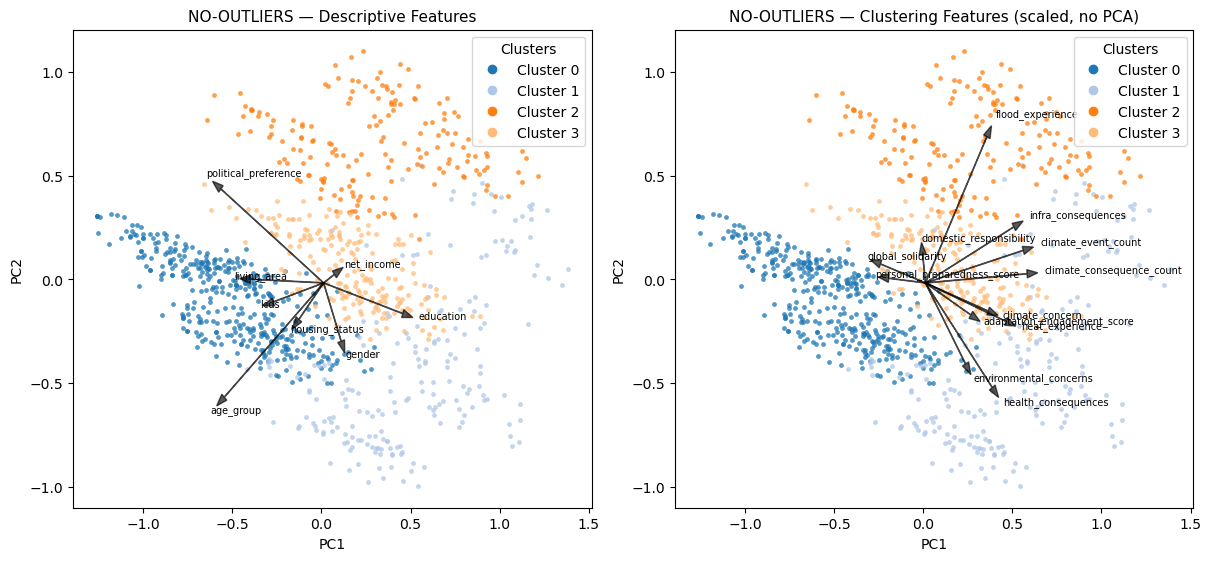

In [35]:
# -------------------------------
# PCA-2D arrows (NO-OUTLIERS only)
#  - Left: Descriptive features
#  - Right: Clustering features (from noout_scaled)
# -------------------------------

# ---------- helpers ----------
def _ensure_row_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "row_id" not in out.columns:
        out.insert(0, "row_id", np.arange(len(out)))
    return out

def _guess_xy_cols(df: pd.DataFrame):
    low = {c.lower(): c for c in df.columns}
    candidates = [("pc1","pc2"),("pca1","pca2"),("dim1","dim2"),("x","y")]
    for a,b in candidates:
        if a in low and b in low:
            return low[a], low[b]
    # fallback: first two numeric (excluding ids/labels)
    num = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ("row_id","cluster","cluster_final")]
    return num[0], num[1]

def _safe_scaled(df, ref, name):
    """Attach row_id if needed; return None if df is missing."""
    if df is None:
        print(f"[warn] {name} not available.")
        return None
    out = df.copy()
    if "row_id" not in out.columns:
        if ref is not None and "row_id" in ref.columns:
            out.insert(0, "row_id", ref["row_id"].to_numpy())
        else:
            out.insert(0, "row_id", np.arange(len(out)))
    return out

def compute_feature_vectors(pca2d_df: pd.DataFrame,
                            features_df: pd.DataFrame,
                            feature_cols: list[str],
                            center: str = "median"):
    """
    For each feature f:
      1) Standardize f.
      2) Regress z_f on (PC1, PC2) -> coefficients (vx, vy).
      3) Scale vectors to a readable length relative to plot range.
    Returns:
      vecs: DataFrame [feature, vx, vy, plot_len]
      (xcol, ycol): PCA column names
    """
    p = _ensure_row_id(pca2d_df)
    f = _ensure_row_id(features_df)
    xcol, ycol = _guess_xy_cols(p)
    merged = p[["row_id", xcol, ycol]].merge(f[["row_id"] + feature_cols], on="row_id", how="inner")

    rows = []
    for feat in feature_cols:
        vals = merged[feat].to_numpy()
        if not np.isfinite(vals).any() or np.nanstd(vals) == 0:
            continue
        y_std = StandardScaler(with_mean=True, with_std=True).fit_transform(vals.reshape(-1,1)).ravel()
        X2d  = merged[[xcol, ycol]].to_numpy()
        lr = LinearRegression().fit(X2d, y_std)
        vx, vy = float(lr.coef_[0]), float(lr.coef_[1])
        rows.append({"feature": feat, "vx": vx, "vy": vy})

    vecs = pd.DataFrame(rows)
    if vecs.empty:
        return vecs, (xcol, ycol)

    # normalize vector lengths to the PCA range (for visual balance)
    # base scale: fraction of axis span
    span_x = float(p[xcol].max() - p[xcol].min())
    span_y = float(p[ycol].max() - p[ycol].min())
    base = 0.25 * np.sqrt(span_x**2 + span_y**2)  # 25% of diag length

    # rescale by max vector norm so the longest arrow ~ base
    norms = np.sqrt(vecs["vx"]**2 + vecs["vy"]**2)
    maxn = norms.max() if np.isfinite(norms).any() else 1.0
    vecs["vx"] = vecs["vx"] / maxn * base
    vecs["vy"] = vecs["vy"] / maxn * base
    vecs["plot_len"] = np.sqrt(vecs["vx"]**2 + vecs["vy"]**2)
    return vecs, (xcol, ycol)

def _cluster_series_for_colors(pca2d_df: pd.DataFrame):
    if "cluster_final" in pca2d_df.columns:
        return pca2d_df["cluster_final"]
    if "cluster" in pca2d_df.columns:
        return pca2d_df["cluster"]
    raise KeyError("Expected a cluster column ('cluster_final' or 'cluster') in the PCA 2D dataframe.")

def _scatter_with_cluster_legend(ax, pca_df, xcol, ycol, cmap_name="tab20", s=12):
    """Scatter colored by cluster with a vertical legend."""
    clusters = sorted(np.unique(_cluster_series_for_colors(pca_df)))
    cmap = mpl.colormaps.get_cmap(cmap_name)
    color_lut = {cid: cmap(i % cmap.N) for i, cid in enumerate(clusters)}

    # plot points
    for cid in clusters:
        sub = pca_df[_cluster_series_for_colors(pca_df) == cid]
        ax.scatter(sub[xcol], sub[ycol], s=s, color=color_lut[cid], alpha=0.75, linewidths=0, label=f"Cluster {cid}")

    # legend (vertical)
    handles = [mpl.lines.Line2D([0],[0], marker='o', linestyle='', markersize=6,
                                markerfacecolor=color_lut[cid], markeredgecolor=color_lut[cid])
               for cid in clusters]
    labels = [f"Cluster {cid}" for cid in clusters]
    ax.legend(handles, labels, title="Clusters", loc="upper right", frameon=True)

    return color_lut

# ---------- data prep (NO-OUTLIERS) ----------
pca2d_no = joined_noout["pca2d"].copy()          # must include row_id and cluster_final (or cluster)
desc_no  = joined_noout["desc"].copy()           # descriptive features
no_scaled_ready = _safe_scaled(noout_scaled if "noout_scaled" in globals() else None,
                               joined_noout["pca90"], "noout_scaled")

# keep numeric-only for features, drop label columns if present
desc_num_no = desc_no.select_dtypes(include=np.number).drop(columns=["cluster","cluster_final"], errors="ignore").copy()
desc_num_no = _ensure_row_id(desc_num_no)

if no_scaled_ready is not None:
    clu_num_no = no_scaled_ready.select_dtypes(include=np.number).drop(columns=["cluster","cluster_final"], errors="ignore").copy()
    clu_num_no = _ensure_row_id(clu_num_no)
else:
    clu_num_no = None

# ---------- plotting ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
panels = [
    ("NO-OUTLIERS — Descriptive Features", pca2d_no, desc_num_no),
    ("NO-OUTLIERS — Clustering Features (scaled, no PCA)", pca2d_no, clu_num_no),
]

for ax, (title, pca_df, feat_df) in zip(axes, panels):
    if pca_df is None or feat_df is None:
        ax.axis("off")
        continue

    # which columns to use as features (exclude row_id)
    feat_cols = [c for c in feat_df.columns if c != "row_id"]
    vecs, (xcol, ycol) = compute_feature_vectors(pca_df, feat_df, feat_cols)

    # choose top vectors to display (keep it readable)
    vecs_plot = vecs.sort_values("plot_len", ascending=False).head(15)

    # scatter (consistent colors; vertical legend)
    _ = _scatter_with_cluster_legend(ax, pca_df, xcol, ycol, cmap_name="tab20", s=12)

    # arrows from the median of the PCA plane
    x0, y0 = float(pca_df[xcol].median()), float(pca_df[ycol].median())
    for _, r in vecs_plot.iterrows():
        ax.arrow(x0, y0, r["vx"], r["vy"],
                 width=0.002, head_width=0.04, length_includes_head=True,
                 color="black", alpha=0.65)
        ax.text(x0 + r["vx"]*1.06, y0 + r["vy"]*1.06, r["feature"], fontsize=7)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    ax.grid(False)

plt.show()


The PCA arrow maps confirm that cluster structure in the no-outliers dataset follows interpretable directions:

- **Horizontal (PC1)** roughly captures a gradient from **low concern and low experience** to **high engagement and high exposure**.
- **Vertical (PC2)** tends to separate clusters by **impact type** — health, infrastructure, or social responsibility.

Clusters form around these axes:
- The **blue cluster** sits on the left side, close to low-concern and low-experience arrows, indicating limited engagement with climate impacts.
- The **orange cluster** lies opposite, where arrows for *health impact*, *heat experience* and *preparedness* dominate — reflecting strong personal and experiential concern.
- The remaining clusters fall in between, oriented toward *infrastructure* and *event exposure* directions, linking to pragmatic or materially aware profiles.

This visualization complements the top-feature tables by showing *how* each dimension of experience contributes to the cluster layout.

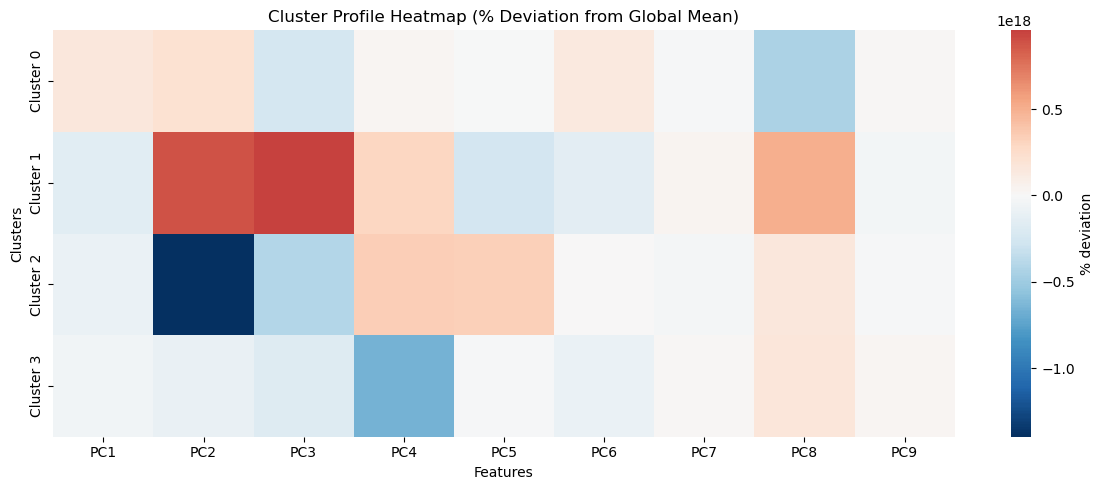

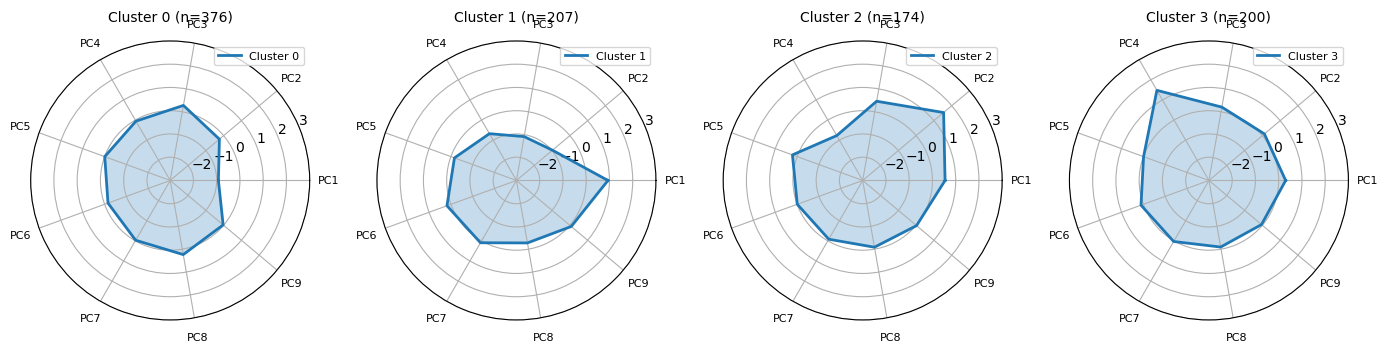

Interpretation:
🔴 Positive values = above average | 🔵 Negative values = below average
Radar shape width = overall advantage, irregularity = contrast across features.


In [36]:
# ==============================================================
# Cluster Profiling Visualization — Heatmaps & Radar Charts
# ==============================================================

def create_cluster_profiles(X, labels, feature_names, cluster_names=None):
    """
    Visual profiling of clusters with heatmaps (% deviation, z-score)
    and simple radar charts for up to 4 clusters.
    """
    df = pd.DataFrame(X, columns=feature_names)
    df["cluster"] = labels
    clusters = sorted([c for c in set(labels) if c != -1])

    overall_mean = df[feature_names].mean()
    overall_std = df[feature_names].std()

    profiles = {}
    for c in clusters:
        d = df[df["cluster"] == c][feature_names]
        means = d.mean()
        pct_dev = ((means - overall_mean) / overall_mean) * 100
        zscore = (means - overall_mean) / overall_std
        profiles[c] = {"mean": means, "pct_dev": pct_dev, "zscore": zscore, "size": len(d)}

    # --- Heatmap of percentage deviations ---
    plt.figure(figsize=(12, 5))
    hm = pd.DataFrame(
        [profiles[c]["pct_dev"] for c in clusters],
        index=[f"Cluster {c}" for c in clusters],
        columns=feature_names
    )
    sns.heatmap(hm, cmap="RdBu_r", center=0, annot=False, cbar_kws={"label": "% deviation"})
    plt.title("Cluster Profile Heatmap (% Deviation from Global Mean)")
    plt.xlabel("Features")
    plt.ylabel("Clusters")
    plt.tight_layout()
    plt.show()

    # --- Radar charts (first 4 clusters) ---
    radar_clusters = clusters[:4]
    N = len(feature_names)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, axes = plt.subplots(1, len(radar_clusters), subplot_kw=dict(polar=True), figsize=(14, 5))
    if len(radar_clusters) == 1:
        axes = [axes]

    for ax, c in zip(axes, radar_clusters):
        values = profiles[c]["zscore"].values
        values = np.concatenate((values, [values[0]]))
        ax.plot(angles, values, linewidth=2, label=f"Cluster {c}")
        ax.fill(angles, values, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([f.replace('_', ' ') for f in feature_names], fontsize=8)
        ax.set_ylim(-3, 3)
        ax.set_title(f"Cluster {c} (n={profiles[c]['size']})", pad=15, fontsize=10)
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- Print short summary ---
    print("Interpretation:")
    print("🔴 Positive values = above average | 🔵 Negative values = below average")
    print("Radar shape width = overall advantage, irregularity = contrast across features.")

    return profiles


# --- Example call using NO_OUTLIERS dataset ---
df_num = DATASETS["no_outliers"]["pca90"].copy()
labs_no = DATASETS["no_outliers"]["final_labels"]["cluster_final"].to_numpy()
feat_names = [c for c in df_num.columns if c != "row_id"]

cluster_profiles_no = create_cluster_profiles(df_num[feat_names].to_numpy(), labs_no, feat_names)


### 4.3 - SEMANTIC DIFFERENTIAL PLOT

The **semantic differential plot** summarizes how each cluster positions itself along key climate-related features, presented as bipolar scales from 1 (“low”) to 7 (“high”).

**How it works**
- Each horizontal line represents a feature, with two descriptive poles (e.g., “low preparedness” → “high preparedness”).
- Each colored line shows the mean position of a cluster on that scale.
- The underlying data are the same normalized features used in clustering, rescaled for interpretability.

**Why this matters**
- It’s an intuitive way to see **how clusters differ** across multiple behavioral and experiential dimensions.
- Rather than absolute values, it emphasizes *relative positioning* — who stands closer to “high concern”, “high impact”, etc.

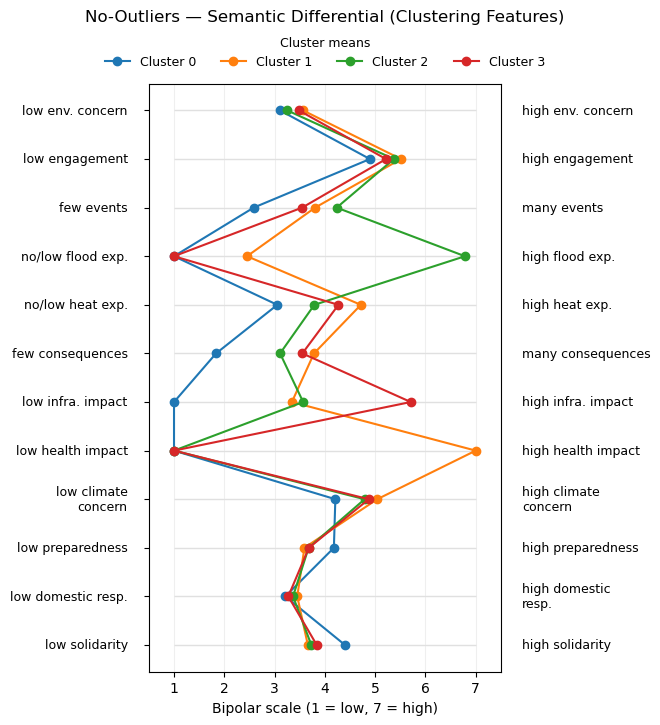

In [ ]:
# ==============================================================
# Semantic Differential — NO-OUTLIERS (12 clustering features)
#  - Builds `noout12_with_labels` if missing
#  - Plots bipolar scales (1..7) per feature, cluster means
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from matplotlib.transforms import blended_transform_factory

# ---------------------------
# 0) Build `noout12_with_labels` if not present
# ---------------------------
def _ensure_row_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "row_id" not in out.columns:
        out.insert(0, "row_id", np.arange(len(out)))
    return out

def _get_labels_no_outliers():
    if "no_outliers" not in DATASETS:
        raise KeyError("DATASETS['no_outliers'] not found.")
    b = DATASETS["no_outliers"]
    if "final_labels" not in b:
        raise KeyError("Missing final_labels for no_outliers. Run final selection first.")
    lbl = b["final_labels"].copy()
    # normalize label column name
    if "cluster_final" in lbl.columns and "cluster" not in lbl.columns:
        lbl = lbl.rename(columns={"cluster_final": "cluster"})
    return lbl[["row_id", "cluster"]]

def _build_noout12_with_labels():
    # take your scaled original features (no PCA)
    if "noout_scaled" not in globals():
        raise KeyError("Expected 'noout_scaled' (scaled features, no PCA) in scope.")
    X = _ensure_row_id(noout_scaled.copy())
    lbl = _get_labels_no_outliers()
    df = X.merge(lbl, on="row_id", how="inner")
    return df

if "noout12_with_labels" not in globals():
    noout12_with_labels = _build_noout12_with_labels()

# ---------------------------
# 1) Inputs
# ---------------------------
df = noout12_with_labels.copy()
title = "No-Outliers — Semantic Differential (Clustering Features)"


poles = {
    "environmental_concerns":        ("low env. concern", "high env. concern"),
    "adaptation_engagement_score":   ("low engagement", "high engagement"),
    "climate_event_count":           ("few events", "many events"),
    "flood_experience":              ("no/low flood exp.", "high flood exp."),
    "heat_experience":               ("no/low heat exp.", "high heat exp."),
    "climate_consequence_count":     ("few consequences", "many consequences"),
    "infra_consequences":            ("low infra. impact", "high infra. impact"),
    "health_consequences":           ("low health impact", "high health impact"),
    "climate_concern":               ("low climate concern", "high climate concern"),
    "personal_preparedness_score":   ("low preparedness", "high preparedness"),
    "domestic_responsibility":       ("low domestic resp.", "high domestic resp."),
    "global_solidarity":             ("low solidarity", "high solidarity"),
}
selected_features = list(poles.keys())

# ---------------------------
# 2) Prep checks
# ---------------------------
if "cluster" not in df.columns:
    if "cluster_final" in df.columns:
        df = df.rename(columns={"cluster_final": "cluster"})
    else:
        raise KeyError("Dataframe must include 'cluster' (or 'cluster_final').")

missing = [f for f in selected_features if f not in df.columns]
if missing:
    raise ValueError(f"Missing in dataframe: {missing}")

# assumes features are 0..1 scaled; clip just in case
df[selected_features] = df[selected_features].clip(0, 1)

# ---------------------------
# 3) Means by cluster & scale to 1..7
# ---------------------------
means = df.groupby("cluster")[selected_features].mean().T  # (features x clusters)
scaled = 1 + 6 * means                                     # (0–1) → (1–7)
ypos = np.arange(len(selected_features))

# ---------------------------
# 4) Plot — match the visual style of the First
# ---------------------------
# compact width; height scales with number of items
fig, ax = plt.subplots(figsize=(8, max(7, len(selected_features) * 0.55)))
# extra side space for pole labels
fig.subplots_adjust(left=0.33, right=0.77, top=0.92, bottom=0.08)

# 1–7 rails
for y in ypos:
    ax.hlines(y, xmin=1, xmax=7, color="0.88", linewidth=1)

# cluster lines (default cycler colors), linewidth like First
for cl in scaled.columns:
    ax.plot(scaled[cl].values, ypos, marker="o", linewidth=1.5, label=f"Cluster {cl}")

# no feature names on Y-axis
ax.set_yticks(ypos)
ax.set_yticklabels([""] * len(ypos))

# compact X-axis
ax.set_xlim(0.5, 7.5)
ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax.set_xlabel("Bipolar scale (1 = low, 7 = high)")
ax.set_title(title, pad=45)
ax.grid(axis="x", alpha=0.2)
ax.invert_yaxis()

# place poles OUTSIDE the plotting area, with text wrapping
wrap = lambda s: textwrap.fill(s, width=18)
trans_left  = blended_transform_factory(ax.transAxes, ax.transData)  # x in [0..1], y in data
trans_right = trans_left

for i, feat in enumerate(selected_features):
    left_txt, right_txt = poles[feat]
    ax.text(-0.06, i, wrap(left_txt),  transform=trans_left,
            va="center", ha="right", fontsize=9, clip_on=False)
    ax.text( 1.06, i, wrap(right_txt), transform=trans_right,
            va="center", ha="left",  fontsize=9, clip_on=False)

# horizontal legend below the title (no overlap)
ax.legend(
    title="Cluster means",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=len(scaled.columns),
    frameon=False,
    fontsize=9,
    title_fontsize=9,
)

plt.show()


**Intepretation**

The semantic differential plot offers a compact view of how clusters diverge across the 12 core climate features:

- The **blue cluster** consistently leans toward the *left* side (low scores), reflecting limited experience, low preparedness and low engagement — consistent with a group relatively detached from direct climate impacts.

- The **orange cluster** trends *strongly to the right* on nearly every impact-related dimension, especially **health consequences**, **heat experience** and **personal preparedness**.  
  This group experiences and internalizes climate change more directly — the most “active” or “affected” profile.

- The other clusters occupy **intermediate positions**, reflecting mixed engagement:
  - One cluster aligns with **infrastructure and event exposure** features, showing a pragmatic and situational awareness.  
  - Another balances **concern and solidarity**, with moderate but consistent engagement.

Across all clusters, **solidarity values remain relatively close**, suggesting that social empathy toward climate issues is shared even among groups with different personal experiences.

In sum, the semantic differential visualization reinforces previous interpretations:
- It confirms the **blue–orange polarity** between disengaged and highly impacted segments.  
- It also highlights subtle middle-ground patterns — people who perceive climate change through functional, community, or moral frames rather than purely personal impact.

### 4.4 - PARALLEL COORDINATES

Parallel coordinate plots reveal how clusters differ across multiple standardized features.
In this case, we are using the reduced dataset (PCA90), therefore the x-axis displays the PCs, while the y-axis shows the standardized value for each PC. Each line traces an observation’s profile across them.
Mean lines highlight characteristic shapes for each cluster — flatter shapes indicate homogeneity, while distinct peaks or dips reveal key differentiating dimensions.
This helps identify which features most define each cluster’s identity and how strongly they diverge from others.

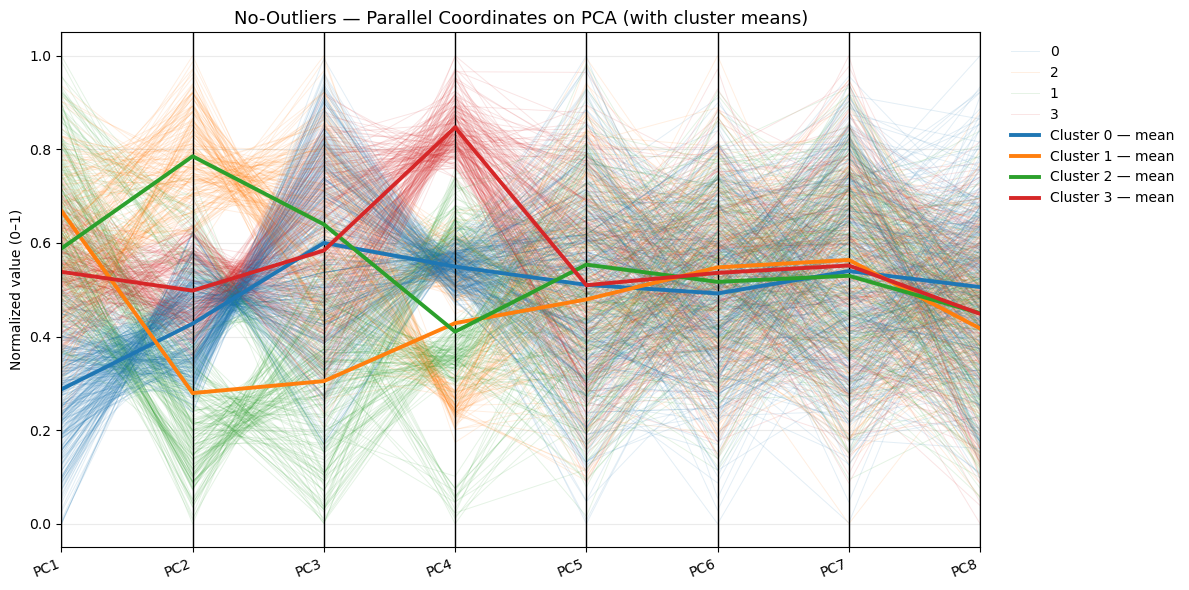


=== PCA component summaries (top ± correlates) ===
PC1:  + climate consequence count (+0.75), climate event count (+0.73), infra consequences (+0.66)  |  − global solidarity (-0.37), personal preparedness score (-0.32), domestic responsibility (-0.03)
PC2:  + flood experience (+0.70), infra consequences (+0.28), domestic responsibility (+0.18)  |  − health consequences (-0.51), environmental concerns (-0.41), heat experience (-0.19)
PC3:  + environmental concerns (+0.64), adaptation engagement score (+0.34), climate concern (+0.21)  |  − health consequences (-0.57), domestic responsibility (-0.33), global solidarity (-0.28)
PC4:  + infra consequences (+0.62), climate consequence count (+0.25), heat experience (+0.13)  |  − flood experience (-0.53), health consequences (-0.36), environmental concerns (-0.10)
PC5:  + personal preparedness score (+0.84), heat experience (+0.36), global solidarity (+0.31)  |  − health consequences (-0.09), climate consequence count (-0.08), infra conseque

In [38]:
# ==============================================================
# Parallel Coordinates (PCA) + Cluster Means + PC "meaning" printout
#  - Plot: first n_features PCs, normalize 0–1, overlay cluster means
#  - Print: for each PC, top +/− original features by correlation
# ==============================================================

LABEL_COL = "cluster_final"   # label column in original features
N_FEATURES = 8                # how many PCs to plot
TOP_POS_NEG = 3               # how many top pos/neg features to show per PC

# ---------- helpers ----------
def _ensure_row_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "row_id" not in out.columns:
        out.insert(0, "row_id", np.arange(len(out)))
    return out

def _pc_cols_from_names(names, n=N_FEATURES):
    """Prende le prime n colonne (già ordinate) dei nomi passati."""
    return list(names[:n])

def _compute_pc_feature_correlations(pca_scores_df: pd.DataFrame,
                                     original_scaled_df: pd.DataFrame,
                                     pc_cols: list[str],
                                     top_k: int = TOP_POS_NEG) -> dict:
    """
    Per ogni PC in pc_cols, calcola corr(feature_orig, PC).
    Ritorna {pc: {'top_pos': [(feat, r), ...], 'top_neg': [(feat, r), ...]}}
    """
    A = _ensure_row_id(pca_scores_df)
    B = _ensure_row_id(original_scaled_df)

    # align on row_id
    merged = A.merge(B, on="row_id", suffixes=("", "_orig"))
    feat_cols = [c for c in original_scaled_df.columns if c not in ("row_id", LABEL_COL)]
    feat_cols = [c for c in feat_cols if np.issubdtype(merged[c].dtype, np.number)]

    out = {}
    for pc in pc_cols:
        pc_vals = merged[pc].to_numpy()
        corrs = []
        sd_pc = np.nanstd(pc_vals)
        for f in feat_cols:
            x = merged[f].to_numpy()
            if np.nanstd(x) == 0 or sd_pc == 0:
                r = np.nan
            else:
                r = np.corrcoef(x, pc_vals)[0, 1]
            if np.isfinite(r):
                corrs.append((f, float(r)))

        if not corrs:
            out[pc] = {"top_pos": [], "top_neg": []}
            continue

        corrs_sorted = sorted(corrs, key=lambda t: t[1], reverse=True)
        top_pos = [(f, r) for f, r in corrs_sorted if r > 0][:top_k]
        top_neg = [(f, r) for f, r in sorted(corrs, key=lambda t: t[1]) if r < 0][:top_k]

        out[pc] = {"top_pos": top_pos, "top_neg": top_neg}
    return out

def _print_pc_summaries(pc_corrs: dict):
    """Stampa una riga per PC: PCi — +f1, f2, f3 | −g1, g2, g3 (con r)."""
    def clean(n): return n.replace("_", " ")
    for pc in pc_corrs:
        pos = pc_corrs[pc]["top_pos"]
        neg = pc_corrs[pc]["top_neg"]
        pos_txt = ", ".join(f"{clean(f)} ({r:+.2f})" for f, r in pos) if pos else "—"
        neg_txt = ", ".join(f"{clean(f)} ({r:+.2f})" for f, r in neg) if neg else "—"
        print(f"{pc}:  + {pos_txt}  |  − {neg_txt}")

def plot_parallel_coordinates_with_means(X: np.ndarray,
                                         labels: np.ndarray,
                                         feature_names: list[str],
                                         n_features: int = N_FEATURES,
                                         title: str = "Parallel Coordinates — PCA profiles"):
    """
    Draws parallel coordinates on the first n_features columns of X
    and overlays the mean line per cluster (thick).
    """
    pc_cols = _pc_cols_from_names(feature_names, n_features)
    df = pd.DataFrame(X[:, :n_features], columns=pc_cols)
    df["cluster"] = labels.astype(str)

    # Normalize 0–1 per comparabilità
    Xcols = pc_cols
    df_norm = (df[Xcols] - df[Xcols].min()) / (df[Xcols].max() - df[Xcols].min())
    df_norm["cluster"] = df["cluster"]

    plt.figure(figsize=(12, 6))
    # subtle lines
    parallel_coordinates(df_norm, "cluster", color=plt.cm.tab10.colors, alpha=0.12, linewidth=0.7)

    # cluster means
    for c, g in df_norm.groupby("cluster"):
        means = g[Xcols].mean(axis=0).values
        plt.plot(range(len(Xcols)), means, linewidth=2.8, label=f"Cluster {c} — mean")

    plt.title(title, fontsize=13)
    plt.ylabel("Normalized value (0–1)")
    plt.xticks(range(len(Xcols)), Xcols, rotation=22, ha="right")
    plt.grid(alpha=0.25)
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    plt.tight_layout()
    plt.show()

# ---------- run on your NO_OUTLIERS PCA ----------
try:
    # 1) Plot parallel coords con medie
    plot_parallel_coordinates_with_means(
        X_no, labs_no, Xcols_noout, n_features=N_FEATURES,
        title="No-Outliers — Parallel Coordinates on PCA (with cluster means)"
    )

    # 2) Estimates the "meaning" of each PC via correlations with original features
    pca_scores_df = DATASETS["no_outliers"]["pca90"].copy()
    # prova a usare le feature scalate originarie; fallback a descrittive numeriche
    if "noout_scaled" in globals() and isinstance(noout_scaled, pd.DataFrame):
        original_scaled_df = noout_scaled.copy()
    else:
        print("[warn] 'noout_scaled' not found — falling back to numeric descriptive features.")
        original_scaled_df = DATASETS["no_outliers"]["desc"].select_dtypes(include=[np.number]).copy()

    # ensures row_id for alignment
    if "row_id" not in original_scaled_df.columns and "row_id" in pca_scores_df.columns:
        original_scaled_df = original_scaled_df.copy()
        original_scaled_df.insert(0, "row_id", pca_scores_df["row_id"].to_numpy())

    pc_cols = _pc_cols_from_names(Xcols_noout, n=N_FEATURES)
    pc_corrs = _compute_pc_feature_correlations(pca_scores_df, original_scaled_df, pc_cols, top_k=TOP_POS_NEG)

    print("\n=== PCA component summaries (top ± correlates) ===")
    _print_pc_summaries(pc_corrs)

except Exception as e:
    import traceback, sys
    print("[error] Parallel coordinates / PC summaries failed.")
    print(type(e).__name__, e)
    traceback.print_exc(file=sys.stdout)

**Interpreting PCA-Based Cluster Profiles**

The parallel coordinates visualization reveals how clusters differ along the main latent dimensions extracted through PCA.  
Clear separations are visible up to **PC4**, after which profiles converge — a typical pattern indicating that the first few components capture the meaningful structure driving the clustering, while later components mostly represent residual noise or fine-grained variation.

**Cluster Dynamics Across Principal Components:**

- **Cluster 2** starts moderately high on PC1, peaks on PC2 and gradually declines by PC4.  
  → This pattern suggests strong alignment with the dominant attitudinal and awareness dimensions, representing communities that are both highly engaged and consistent in their climate-related outlooks.

- **Cluster 0** begins lower on PC1 but increases steadily across the first components.  
  → Indicates groups with initially limited engagement or concern that rise in relative importance along secondary behavioral or contextual dimensions.

- **Cluster 1** shows a sharp early peak followed by a notable drop and mild rebound.  
  → A polarized profile — possibly reflecting strong conviction or concern on a single issue (e.g., perceived climate risk) but lower coherence or action orientation elsewhere.

- **Cluster 3** maintains moderate levels early on, then peaks around PC4.  
  → Suggests a group whose distinctiveness emerges in subtler or more context-specific factors, perhaps related to practical adaptation or local experience rather than broad awareness.

**Interpretive Summary:**

Up to the fourth principal component, cluster profiles remain well separated, confirming that the clustering captures real structural differences in the data rather than random noise.  
Beyond PC4, overlapping lines indicate shared background traits or less differentiated attitudes — common in socio-environmental surveys where a few key dimensions explain most behavioral diversity.

Overall, this visualization validates the clustering’s internal consistency and helps translate statistical components into intuitive, interpretable community profiles.

### 4.4 - IN_DEPTH DESCRIPTIVE VARIABLE DISTRIBUTIONS ACROSS CLUSTERS

**Understanding Categorical Cluster Profiles**

In this step, we explore how categorical and ordinal demographic features (such as gender, age group, education, income, political preference, housing and living area) distribute across the four clusters identified in the *no-outliers* dataset.

The goal is to understand who makes up each cluster — not just their numerical traits, but their social and behavioral composition.

Two complementary views are produced:

1. *Row-normalized tables (and heatmaps)*  
   Show, for each category level (e.g. “female”, “18–24”), how respondents are distributed across clusters.  
   Example: “39.5% of women are in cluster 0” means that, among all women, 39.5% belong to cluster 0.

2. *Column-normalized tables (and stacked bars)*  
   Show, within each cluster, what share of people fall into each category.  
   Example: “65.2% of cluster 1 are women” means that two-thirds of that cluster identify as female.

The distinction matters:  
A 50% value in a row-normalized view does **not** mean half the cluster, but rather that half of those in that category fall within that cluster.  
It’s a *horizontal* proportion, not a vertical one.

Together, these perspectives reveal both who dominates each cluster and how strongly certain social groups concentrate in them — enabling richer, human-centered interpretation of the numeric patterns seen earlier.

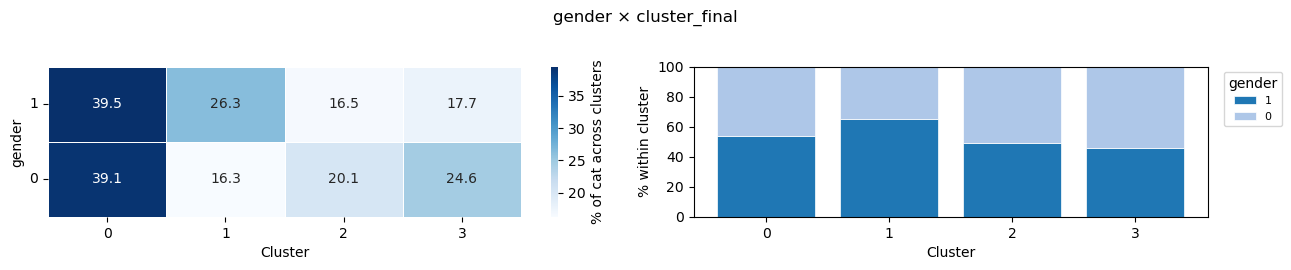

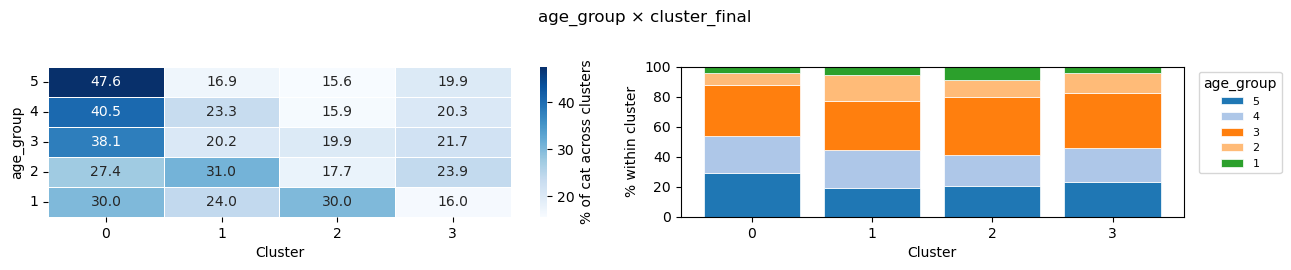

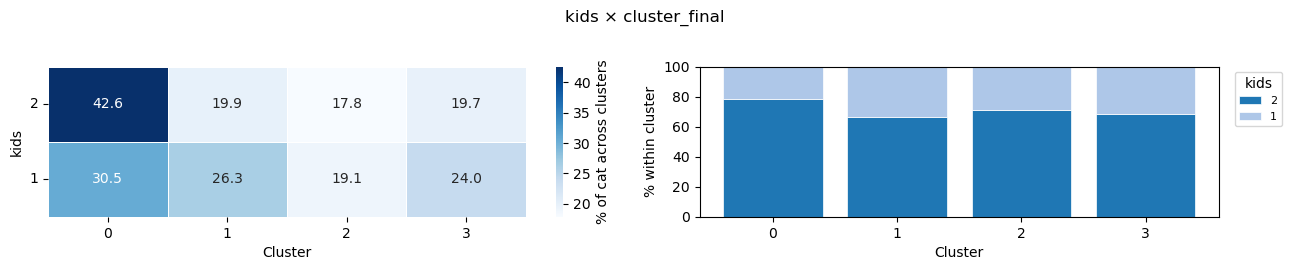

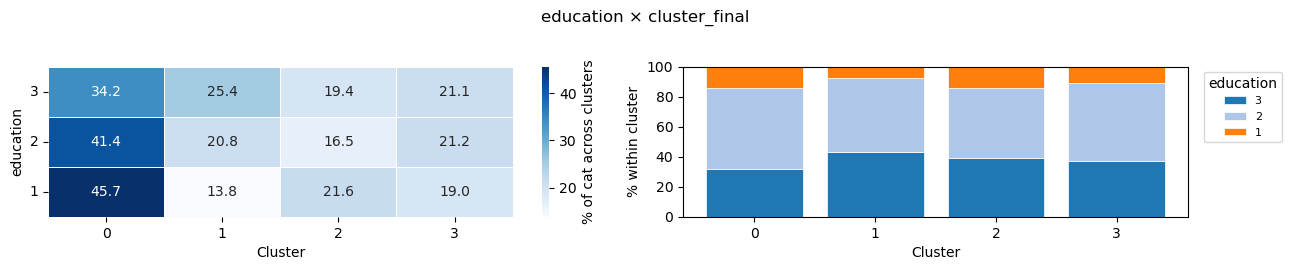

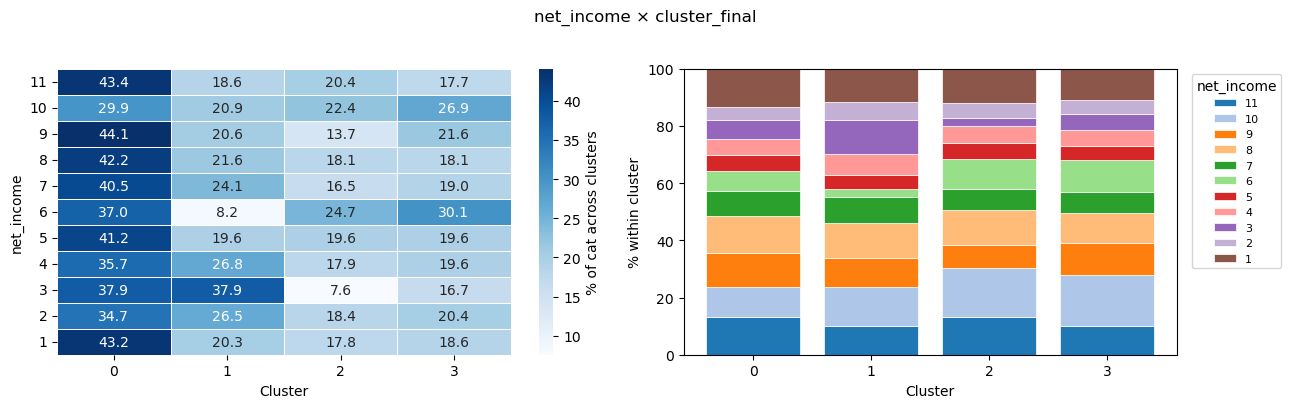

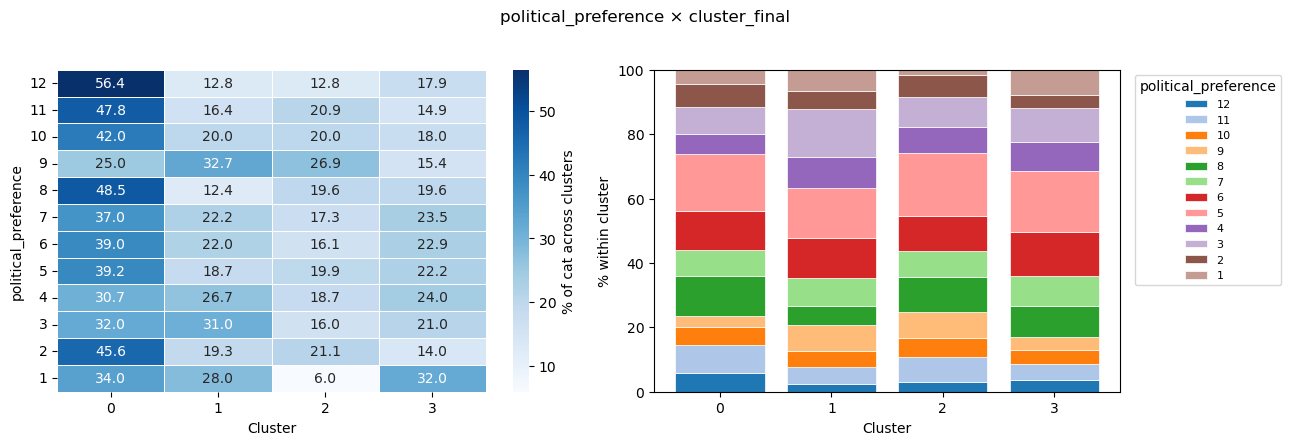

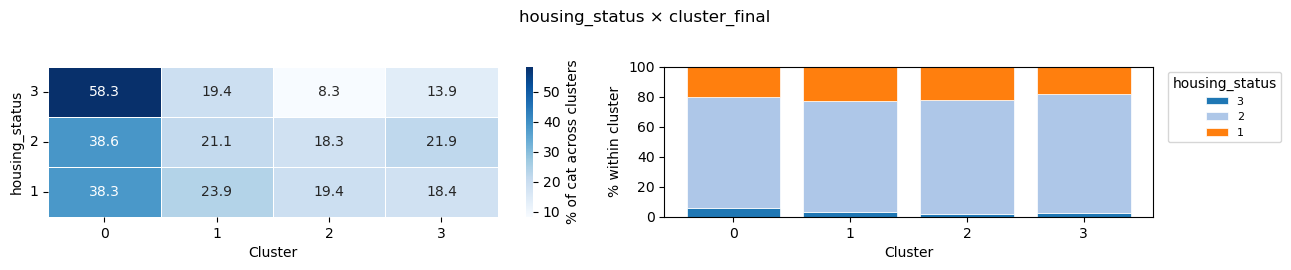

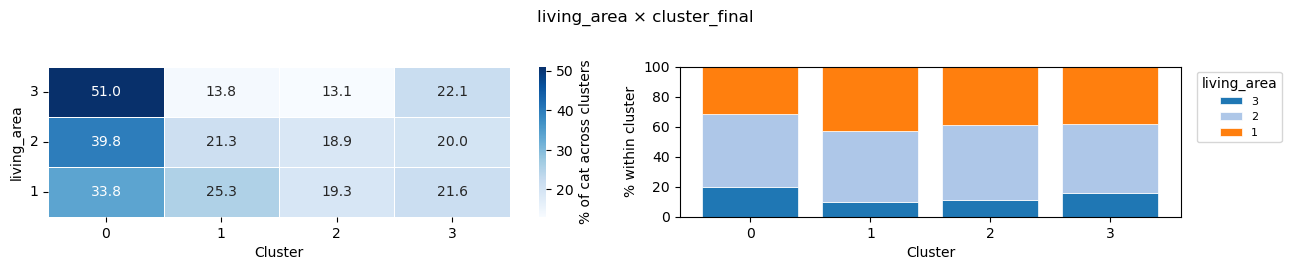

In [39]:
# ==============================================================
# Categorical Profiling — NO-OUTLIERS
# Heatmap (row %) + 100% stacked bars (cluster composition)
# Uses variables from previous cells: joined_noout, joined_full, etc.
# ==============================================================


# -------- Inputs (NO-OUTLIERS descriptive table) --------
dfD = joined_noout["desc"].copy()

# Detect cluster column name robustly
if "cluster_final" in dfD.columns:
    cluster_col = "cluster_final"
elif "cluster" in dfD.columns:
    cluster_col = "cluster"
else:
    raise KeyError("No cluster column found in joined_noout['desc'] (expected 'cluster_final' or 'cluster').")

# Categorical / ordinal features to visualize (adjust if needed)
DESC_FEATS = [
    "gender", "age_group", "kids", "education",
    "net_income", "political_preference", "housing_status", "living_area",
]

# Optional canonical orders for some vars
CATEGORY_ORDERS = {
    "age_group": ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    "education": ["low", "mid", "high", "postgrad"],
    "political_preference": [str(i) for i in range(1, 13)],
    "living_area": ["rural", "town", "suburban", "urban"],
}
NA_LABEL = "Missing"

# -------- Utilities --------
def _to_str_series(s: pd.Series) -> pd.Series:
    out = s.copy()
    out = out.where(~out.isna(), NA_LABEL).astype(str)
    return out

def _numeric_key(v: str):
    try:
        return float(v)
    except Exception:
        return None

def _infer_order(s: pd.Series, feat: str, bottom_low=True) -> list[str]:
    """Return ordered list of category labels for display."""
    s = _to_str_series(s)
    present = list(sorted(set(s)))  # stable

    # If provided, respect canonical order (filter to present)
    if feat in CATEGORY_ORDERS:
        base = [x for x in CATEGORY_ORDERS[feat] if x in present]
        extra = [x for x in present if x not in base and x != NA_LABEL]
        extra_sorted = sorted(extra, key=str.lower)
        ordered = base + extra_sorted
    else:
        # Try numeric-aware sort if most values look numeric
        non_na = [x for x in present if x != NA_LABEL]
        numericables = [x for x in non_na if _numeric_key(x) is not None]
        if len(numericables) >= max(2, len(non_na) - 1):
            ordered = sorted(non_na, key=lambda x: _numeric_key(x))
        else:
            ordered = sorted(non_na, key=str.lower)

    if bottom_low:
        ordered = list(reversed(ordered))
    if NA_LABEL in present:
        ordered = ordered + [NA_LABEL]
    return ordered

def _order_net_income(df: pd.DataFrame):
    """Improve order for mixed net_income labels like '1 <1k', '2 1-2k'."""
    if "net_income" not in df.columns:
        return
    s = _to_str_series(df["net_income"])
    # extract leading integer if present
    lead = s.str.extract(r"^\s*(\d+)", expand=False)
    lead_num = pd.to_numeric(lead, errors="coerce")
    map_order = (
        pd.DataFrame({"label": s, "num": lead_num})
        .dropna(subset=["num"])
        .drop_duplicates(subset=["label"])
        .sort_values("num")
    )
    ordered = map_order["label"].tolist()
    # append extras that didn’t match numeric pattern
    extras = sorted([lab for lab in s.unique() if lab not in set(ordered) and lab != NA_LABEL], key=str.lower)
    CATEGORY_ORDERS["net_income"] = ordered + extras

def _cluster_color_lut(series, cmap_name="tab20"):
    # sort clusters numerically if possible
    uniq = pd.Series(series).dropna().unique().tolist()
    def _sort_key(x):
        xs = str(x)
        return (not xs.isdigit(), int(xs) if xs.isdigit() else xs)
    clusters = sorted(uniq, key=_sort_key)
    cmap = mpl.colormaps.get_cmap(cmap_name)
    lut = {c: cmap(i % cmap.N) for i, c in enumerate(clusters)}
    return lut, [str(c) for c in clusters]  # return cluster labels as strings for table columns

def _crosstabs(df: pd.DataFrame, feat: str, cluster_col: str, order_rows: list[str], order_clusters: list[str]):
    """Return row-normalized (%) and column-normalized (%) tables with requested orders."""
    a = _to_str_series(df[feat])
    b = _to_str_series(df[cluster_col])
    ct = pd.crosstab(a, b, dropna=False)

    # Row-normalized (distribution across clusters within each category)
    row_pct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0) * 100.0
    row_pct = row_pct.reindex(index=order_rows, columns=order_clusters, fill_value=0.0)

    # Column-normalized (composition of each cluster by category)
    col_pct = ct.div(ct.sum(axis=0).replace(0, np.nan), axis=1) * 100.0
    col_pct = col_pct.reindex(index=order_rows, columns=order_clusters, fill_value=0.0)

    return row_pct, col_pct

def plot_categorical_profile(df: pd.DataFrame, feat: str, cluster_col: str, cmap="Blues"):
    """One figure per feature: left heatmap (row %), right 100% stacked bars (cluster composition)."""
    # Build better order for net_income if present
    _order_net_income(df)

    # Prepare orders
    row_order = _infer_order(df[feat], feat, bottom_low=True)
    lut, cluster_order = _cluster_color_lut(df[cluster_col])

    # Tables
    row_pct, col_pct = _crosstabs(df, feat, cluster_col, row_order, cluster_order)

    # Figure
    h = max(2.6, 0.36 * len(row_order))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, h), gridspec_kw={"width_ratios": [1.15, 1.0]})
    fig.suptitle(f"{feat} × {cluster_col}", y=1.02, fontsize=12)

    # Left: heatmap of row % (each category across clusters)
    sns.heatmap(
        row_pct,
        ax=ax1, annot=True, fmt=".1f", cmap=cmap,
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "% of cat across clusters"},
    )
    ax1.set_xlabel("Cluster")
    ax1.set_ylabel(feat)
    ax1.set_yticklabels(row_order, rotation=0)

    # Right: 100% stacked bars by cluster (composition)
    bottoms = np.zeros(len(cluster_order), dtype=float)
    # Use a stable palette for categories (so legend colors repeat per feature consistently)
    cat_cmap = mpl.colormaps.get_cmap("tab20")
    for idx, cat in enumerate(row_order):
        vals = col_pct.loc[cat, :].values.astype(float)  # % within cluster
        ax2.bar(
            cluster_order, vals, bottom=bottoms,
            color=cat_cmap(idx % cat_cmap.N),
            edgecolor="white", linewidth=0.5, label=str(cat)
        )
        bottoms += vals

    ax2.set_ylim(0, 100)
    ax2.set_ylabel("% within cluster")
    ax2.set_xlabel("Cluster")
    ax2.legend(title=feat, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fontsize=8)

    plt.tight_layout()
    plt.show()

# -------- Run: one figure per categorical feature --------
for feat in DESC_FEATS:
    if feat in dfD.columns:
        plot_categorical_profile(dfD, feat, cluster_col=cluster_col, cmap="Blues")


**Interpretation of Results — No-Outliers Dataset**

Across the main demographic dimensions, distinct yet plausible social profiles emerge.

*Gender*  
Cluster 1 has the highest female concentration (around 65%), consistent with its prior identification as the health-aware and engaged group.  
Clusters 0, 2 and 3 are more balanced or slightly male-skewed, especially cluster 3 (about 55% men).

*Age group*  
Older individuals (55–64 and 65+) lean toward cluster 0 (45–48%), reinforcing its older-urban family profile.  
Younger adults (25–34) are more represented in cluster 1, aligning with its younger, educated pattern.

*Children (kids)*  
Cluster 0 again shows higher presence of households with children (about 79%), while cluster 1 has fewer (around 67%).  
This matches the family vs. single contrast already seen in descriptive features.

*Education*  
Cluster 1 has the highest share of highly educated respondents (43%), while clusters 0 and 2 lean more toward mid-level education — consistent with the socio-educational split between pragmatic and engaged groups.

*Income*  
Income is fairly even but cluster 3 shows a slightly higher share of middle-to-upper brackets (levels 6–10), hinting at a moderately affluent group.  
Lower-income groups (1–4) appear somewhat more in clusters 0 and 1.

*Political preference*  
Higher numeric codes (more right-leaning) dominate cluster 0 (e.g. 56% of group 12, 48% of group 11), while cluster 1 draws more from the center-left range (groups 3–6).  
Cluster 3 remains politically mixed.

*Housing status*  
Around 75–79% of all clusters own or rent (category 2), with little variation — no housing-based segmentation is apparent.  
Cluster 0 shows a minor over-representation of more stable housing arrangements.

*Living area*  
Urban residents (category 3) cluster more in 0 and 3, while rural/town participants (categories 1–2) are over-represented in 2.  
This mirrors the infrastructure-vs-flood-experience divide observed in clustering features.

*Summary*  
The categorical breakdown validates and refines the earlier quantitative findings.  
- Cluster 0 — older, family-oriented, urban, more right-leaning.  
- Cluster 1 — younger, educated, female, left-leaning, often without children.  
- Cluster 2 — mixed-gender, rural/suburban, middle-aged, practical flood-affected group.  
- Cluster 3 — younger-male, moderate-income, infrastructure-aware group.

Demographic coherence across views reinforces the internal interpretability of the four-cluster solution:  
each segment is socially distinct yet plausible, supporting the robustness of the segmentation beyond numerical similarity alone.

In [40]:
# ==============================================================
# Export full percentage tables per categorical feature
#  - Row-normalized: how each category distributes across clusters
#  - Column-normalized: how each cluster is composed by that feature
# ==============================================================
'''
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

for feat in DESC_FEATS:
    if feat not in dfD.columns:
        print(f"\n⚠️ Skipping {feat} (not found in dataset)")
        continue

    print(f"\n\n=== {feat.upper()} × {cluster_col} ===")
    row_order = _infer_order(dfD[feat], feat, bottom_low=True)
    lut, cluster_order = _cluster_color_lut(dfD[cluster_col])
    row_pct, col_pct = _crosstabs(dfD, feat, cluster_col, row_order, cluster_order)

    print("\n-- Row-normalized (% within category) --")
    display(row_pct.round(1))

    print("\n-- Column-normalized (% within cluster) --")
    display(col_pct.round(1))
'''

'\npd.set_option("display.max_rows", None)\npd.set_option("display.max_columns", None)\n\nfor feat in DESC_FEATS:\n    if feat not in dfD.columns:\n        print(f"\n⚠️ Skipping {feat} (not found in dataset)")\n        continue\n\n    print(f"\n\n=== {feat.upper()} × {cluster_col} ===")\n    row_order = _infer_order(dfD[feat], feat, bottom_low=True)\n    lut, cluster_order = _cluster_color_lut(dfD[cluster_col])\n    row_pct, col_pct = _crosstabs(dfD, feat, cluster_col, row_order, cluster_order)\n\n    print("\n-- Row-normalized (% within category) --")\n    display(row_pct.round(1))\n\n    print("\n-- Column-normalized (% within cluster) --")\n    display(col_pct.round(1))\n'

### 4.5 - CLUSTER CENTROID HEATMAP

This plot summarizes how each cluster scores across the 12 original *climate experience and attitude* features.  
Each row represents a cluster and each column one feature.  
The color scale indicates relative position on each variable:
- **Red = above-average (positive deviation)**  
- **Blue = below-average (negative deviation)**  

Unlike the PCA or t-SNE plots that show overall structure, this view isolates **feature-level contrasts**.  
It allows us to:
- Spot which dimensions truly differentiate clusters (large color shifts across rows).  
- Identify shared attitudes (columns with uniform color).  
- Visually validate that clusters have coherent internal meaning — for instance, groups high on exposure also showing high concern or preparedness.  

In short, the centroids heatmap connects the *quantitative segmentation* to its *substantive interpretation*, helping link each cluster back to real-world behavioral or experiential patterns.

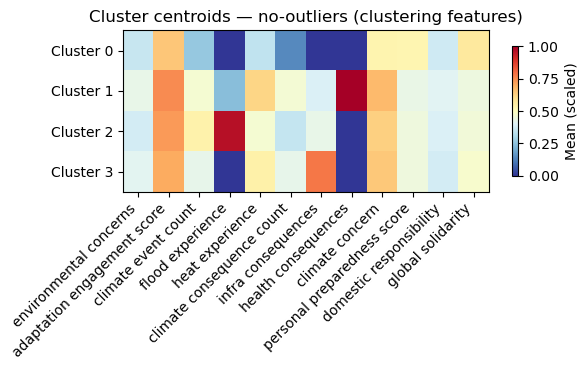

In [41]:
# Centroids heatmap across clustering features (no-outliers)

preferred = [
    "environmental_concerns","adaptation_engagement_score","climate_event_count","flood_experience",
    "heat_experience","climate_consequence_count","infra_consequences","health_consequences",
    "climate_concern","personal_preparedness_score","domestic_responsibility","global_solidarity",
]
feature_cols = [c for c in preferred if c in X12_no.columns]
if not feature_cols:
    feature_cols = [c for c in X12_no.select_dtypes(include=np.number).columns if c != "row_id"]

df = X12_no.merge(labels_no, on="row_id", how="inner")
centroids = df.groupby(LABEL_COL)[feature_cols].mean().sort_index()

fig, ax = plt.subplots(figsize=(max(6, 0.5*len(feature_cols)), 3.8))
im = ax.imshow(centroids.values, aspect="auto", cmap="RdYlBu_r")
ax.set_yticks(range(len(centroids.index)))
ax.set_yticklabels([f"Cluster {c}" for c in centroids.index])
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([f.replace("_"," ") for f in feature_cols], rotation=45, ha="right")
ax.set_title("Cluster centroids — no-outliers (clustering features)")
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Mean (scaled)")
plt.tight_layout()
plt.show()

**Interpreting the Centroids Heatmap — No-Outliers Dataset**

The pattern reveals four distinct behavioral–experiential profiles:

- **Cluster 0 — Low Exposure & Limited Concern**  
  Mostly blue across the map, especially on *flood experience*, *infrastructure consequences* and *health consequences*.  
  This group has low direct exposure to climate events and limited emotional or cognitive concern about them.  
  They form the *baseline cluster* — relatively disengaged, less personally affected.

- **Cluster 1 — Health- and Engagement-Oriented**  
  Strong red in *adaptation engagement score* and *health consequences*, moderate warmth in *climate concern*.  
  Suggests an *active and health-aware segment* — individuals who both perceive and respond to climate risks, possibly translating awareness into personal action.

- **Cluster 2 — Flood-Experienced, Materially Impacted**  
  Prominent red in *flood experience*, cooler tones in *health consequences*.  
  These individuals likely perceive climate change through tangible, physical events rather than health or moral framing — a *pragmatic, experience-based group*.

- **Cluster 3 — Infrastructure-Concerned, Moderately Engaged**  
  Blue for *flood experience* but red for *infrastructure consequences*.  
  Indicates awareness of structural or community-level vulnerabilities (roads, buildings, services) even without personal exposure.  
  A *functionally engaged* cluster — concerned with material systems and preparedness more than personal impact.

Overall, the color contrasts confirm that clusters differ primarily along **three experiential axes**:  
(1) direct exposure to climate events,  
(2) perceived health consequences and  
(3) engagement or preparedness.  
Shared neutrality on features like *global solidarity* and *domestic responsibility* suggests these attitudes are common across groups rather than differentiating them.

### 4.6 - DOMAIN VALIDATION & EXTERNAL/EXPERT BECNHMARKING

Internal validation metrics confirm that the clustering algorithm works statistically;  
**domain validation** asks whether the results make sense *in the real world.*

This step bridges data science with applied sustainability work by comparing cluster patterns  
against known facts, external indicators, or expert knowledge.

**Purpose**
- Assess whether discovered clusters align with *known socio-environmental realities.*
- Check that segmentation captures meaningful community differences, not artifacts of modeling.
- Translate quantitative clusters into actionable categories that stakeholders recognize.

**Approaches**

1. **External benchmarking** — Compare cluster assignments against available reference data:
   - Government indices (e.g., census income, environmental justice indicators)
   - Existing typologies from academic or policy studies
   - Administrative categories such as regions or vulnerability classes  
   Using metrics like **Normalized Mutual Information (NMI)** or **Adjusted Rand Index (ARI)**  
   quantifies the level of agreement between cluster structure and known labels.

2. **Expert review** — Invite domain specialists, community organizers, or policy experts to:
   - Assess whether clusters correspond to known social, geographic, or behavioral patterns  
   - Identify missing or merged groups  
   - Suggest meaningful, stakeholder-friendly names for each cluster  
   A simple review template structures this feedback to ensure consistency across reviewers.

**Why it matters**
- Provides a *reality check* beyond mathematical fit.
- Builds *trust and interpretability* for decision-makers.
- Ensures clusters are not only valid within the data but *useful for intervention design.*

**How it fits this project**
- After defining four clusters via Ward linkage (no-outliers dataset),  
  domain validation can test their realism against available socioeconomic indicators  
  or expert assessments of Italy’s climate perception landscape.
- Agreement metrics (NMI, ARI) quantify correspondence with known socio-political typologies.  
- Expert review can refine cluster labels, ensuring they resonate with policy and communication goals.

Together, these checks ground statistical segmentation in domain reality —  
turning a purely analytical output into a trustworthy *decision-support tool.*

---
# 5 - DOCUMENTATION PHASE: DECISIONS & RESULTS

### 5.1 - AUTOMATED EXPERIMENT PIPELINE

This section introduces an **automated batch pipeline** that executes all clustering experiments from a single configuration file.  
Rather than running K-Means, Agglomerative and DBSCAN manually, the pipeline systematically sweeps through parameters and logs all results — ensuring **reproducibility, comparability and transparency**.

**What it does**
- Loads a simple YAML config that defines:
  - Which datasets to use (e.g., `full`, `no_outliers`)
  - Which algorithms to test (`kmeans`, `agglo`, `dbscan`)
  - Parameter grids (number of clusters `k`, linkages, `eps` quantiles, etc.)
- Runs each combination automatically, using the same functions and metrics as the manual tests:
  - **Silhouette**, **Calinski–Harabasz**, **Davies–Bouldin** and **runtime**
- Normalizes metrics into a **composite quality score** to make comparisons fair across algorithms.
- Exports tidy results as both:
  - A single CSV (all runs, all datasets)
  - Per-dataset Excel workbooks (one sheet per algorithm)

**Why it matters**
- Guarantees *consistent evaluation* across algorithms and datasets.
- Reduces *human bias* in model comparison.
- Enables *reproducibility*: experiments can be fully re-run from the YAML file.
- Simplifies *collaboration*: non-programmers can adjust parameters directly in the config.
- Creates a complete *experiment log* suitable for inclusion in reports or appendices.

**How to use it**
1. Edit `experiments.yaml` to set parameter ranges or algorithms to test.  
2. Run the `run_experiment_batch()` cell to execute all experiments.  
3. Inspect the saved CSV/Excel files for comparison and selection.  

This transforms the exploratory workflow into a documented, auditable process — scaling the analysis from *ad hoc trials* to a **systematic experimental framework** that supports evidence-based model choice.


In [ ]:
# ==============================================================
# Batch experiments from a YAML config
#  - Reuses your existing functions:
#      run_kmeans_grid, run_agglo_grid, scan_dbscan, normalize_columns
#  - Works on your DATASETS {full, no_outliers} in PCA-90% space
#  - Saves tidy CSV/Excel under OUTPUT_PATH
# ==============================================================

# --- Assumptions: these are already defined in your notebook ---
# DATASETS, Xcols_full, Xcols_noout, OUTPUT_PATH
# run_kmeans_grid(X, k_values, ...), run_agglo_grid(X, k_values, linkage=..., ...)
# scan_dbscan(X, min_samples=..., q_list=..., sample_cap=..., random_state=...)
# normalize_columns(df, cols, invert=...)

# ------------------------
# Helper: assemble a tidy frame with normalized composite
# ------------------------
def _composite_scores(df: pd.DataFrame) -> pd.DataFrame:
    """Add normalized metrics & composite (Sil↑, CH↑, DB↓) if columns exist."""
    need = [c for c in ["silhouette", "calinski_harabasz", "davies_bouldin"] if c in df.columns]
    if len(need) < 3:
        return df.copy()
    s = normalize_columns(df, ["silhouette","calinski_harabasz","davies_bouldin"], invert=["davies_bouldin"])
    s["composite"] = s[["silhouette_norm","calinski_harabasz_norm","davies_bouldin_norm"]].mean(axis=1)
    return s

# ------------------------
# Main runner
# ------------------------
def run_experiment_batch(config_path: str | Path) -> pd.DataFrame:
    """
    Execute clustering sweeps declared in a YAML config.
    Produces a tidy table with metrics, runtime, params, dataset, algo.
    """
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    out_rows = []
    ts = time.strftime("%Y%m%d_%H%M%S")

    # Datasets to process
    ds_list = cfg.get("datasets", ["full","no_outliers"])
    for ds_name in ds_list:
        if ds_name not in DATASETS:
            print(f"[warn] dataset '{ds_name}' not in DATASETS, skipping.")
            continue

        # Select features (PCA-90 already scaled)
        X = DATASETS[ds_name]["pca90"][Xcols_full if ds_name=="full" else Xcols_noout].values

        # ---- K-Means ----
        if "kmeans" in cfg:
            p = cfg["kmeans"] or {}
            k_values    = p.get("k_values", list(range(2,11)))
            n_init      = p.get("n_init", 50)
            repeats     = p.get("time_repeats", 5)
            rs          = p.get("random_state", 42)

            df_km = run_kmeans_grid(X, k_values, n_init=n_init, random_state=rs, time_repeats=repeats)
            df_km["dataset"] = ds_name
            out_rows.append(df_km)

        # ---- Agglomerative (one or more linkages) ----
        if "agglo" in cfg:
            p = cfg["agglo"] or {}
            k_values = p.get("k_values", list(range(2,11)))
            linkages = p.get("linkages", ["ward","average","complete"])
            repeats  = p.get("time_repeats", 5)

            ag_parts = []
            for lnk in linkages:
                df_ag = run_agglo_grid(X, k_values, linkage=lnk, time_repeats=repeats)
                ag_parts.append(df_ag)
            if ag_parts:
                df_ag_all = pd.concat(ag_parts, ignore_index=True)
                df_ag_all["dataset"] = ds_name
                out_rows.append(df_ag_all)

        # ---- DBSCAN (quantile-based eps scan) ----
        if "dbscan" in cfg:
            p = cfg["dbscan"] or {}
            min_samples = p.get("min_samples", 10)
            q_list      = p.get("q_list", [85,90,92,94,95,96,97,98])
            sample_cap  = p.get("sample_cap", 1500)
            rs          = p.get("random_state", 42)

            df_db = scan_dbscan(
                X,
                min_samples=min_samples,
                q_list=tuple(q_list),
                sample_cap=sample_cap,
                random_state=rs,
            )
            # make columns consistent-ish with others
            df_db = df_db.rename(columns={
                "q":"k_or_q",
            })
            df_db["algo"]    = "dbscan"
            df_db["dataset"] = ds_name
            out_rows.append(df_db)

    # Merge & augment
    if not out_rows:
        print("[warn] No results produced by the config.")
        return pd.DataFrame()

    results_df = pd.concat(out_rows, ignore_index=True)

    # Normalize & composite for algos that have the trio of metrics
    results_df = _composite_scores(results_df)

    # Save tidy CSV + per-dataset Excel
    OUT_DIR = OUTPUT_PATH
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = OUT_DIR / f"batch_results_{ts}.csv"
    results_df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"✔ Saved tidy results: {csv_path}")

    # Optional: one Excel per dataset for easy inspection
    for ds in results_df.get("dataset", pd.Series()).dropna().unique():
        sub = results_df[results_df["dataset"] == ds].copy()
        xlsx_path = OUT_DIR / f"batch_results_{ds}_{ts}.xlsx"
        with pd.ExcelWriter(xlsx_path, engine="openpyxl") as w:
            # separate tabs by algorithm if present
            for algo in sorted(sub["algo"].astype(str).unique()):
                sub[sub["algo"] == algo].to_excel(w, sheet_name=algo[:28], index=False)
        print(f"  ↳ {ds}: {xlsx_path}")

    return results_df

In [ ]:
yaml_text = """
datasets: ["full", "no_outliers"]

kmeans:
  k_values: [2,3,4,5,6,7,8,9,10]
  n_init: 50
  time_repeats: 5
  random_state: 42

agglo:
  k_values: [2,3,4,5,6,7,8,9,10]
  linkages: ["ward", "average", "complete"]
  time_repeats: 5

dbscan:
  min_samples: 10
  q_list: [85, 90, 92, 94, 95, 96, 97, 98]
  sample_cap: 1500
  random_state: 42
"""

cfg_path = OUTPUT_PATH / "experiments" / "experiments.yaml"
cfg_path.parent.mkdir(parents=True, exist_ok=True)
cfg_path.write_text(yaml_text, encoding="utf-8")
print(f"✔ Wrote config: {cfg_path}")

✔ Wrote config: output\experiments.yaml


In [ ]:
results_batch = run_experiment_batch(cfg_path)
display(results_batch.head(10))

### 5.2 - CLUSTERING COMPARISON - CLUSTER-BASED SELECTION

**Algorithm Comparison — Evidence-Based Selection**

This analysis followed a structured, evidence-based approach to choose the final clustering model.  
Rather than relying on intuition or a single metric, each algorithm was evaluated across four dimensions:

1. **Statistical quality** — silhouette, Calinski–Harabasz and Davies–Bouldin scores jointly assessed cohesion and separation.
2. **Computational efficiency** — runtimes were benchmarked to ensure the method scales to the dataset size.
3. **Interpretability** — the resulting cluster shapes and PCA/t-SNE projections were inspected for stakeholder clarity.
4. **Robustness** — bootstrap and parameter-perturbation tests confirmed stability across data subsamples.

Across these axes, the **Agglomerative (Ward) model with *k = 4* on the no-outlier dataset** emerged as the most balanced choice: it maintained strong internal quality, interpretable separation and robust results under resampling — all while remaining accessible to non-technical audiences. This aligns with best practices for sustainability segmentation, because it reveals gradual group relationships.

### 5.3 - CLUSTER-BASED INTERVENTION DESIGN & ACTION FRAMIG

If you'd like to have a comprenhensive overview on the complete workflow for this project, read about a potential intervention design and action framing, or learn about risks, biases and limitations, please have a look at the Impact Report. 

---
# 6 - BIBLIOGRAPHY & RELATED WORK

>- **European Investment Bank (EIB).** (2024). *EIB Climate Survey 2024–2025*. European Investment Bank.

>- **Intergovernmental Panel on Climate Change (IPCC).** (2022). *AR6 Working Group II: Impacts, Adaptation and Vulnerability*. Cambridge University Press.

>- **OECD.** (2022). *Building Climate-Resilient Societies: Policy Perspectives*. OECD Publishing.

>- **United Nations Development Programme (UNDP).** (2021). *The People’s Climate Vote*. United Nations Development Programme.

>- **United Nations Department of Economic and Social Affairs (UN DESA).** (2015). *Transforming Our World: The 2030 Agenda for Sustainable Development*. United Nations.

>- **Aggarwal, C. C., & Reddy, C. K.** (2014). *Data Clustering: Algorithms and Applications*. CRC Press.

>- **Ward, J. H.** (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association*, 58(301), 236–244.

>- **Lloyd, S.** (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129–137.

>- **Hainmueller, J., & Hazlett, C.** (2014). Kernel regularized least squares: Reducing misspecification bias with a flexible and interpretable machine learning approach. *Political Analysis*, 22(2), 143–168.

>- **OECD.** (2020). *Trust and Public Policy: How Better Governance Can Help Rebuild Public Trust*. OECD Publishing.